In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# First I read in the data
indeed_w1 = pd.read_csv("./new_data/Indeed_w1.csv", sep=",", skiprows=1)
indeed_w2 = pd.read_csv("./new_data/Indeed_w2.csv", sep=",", skiprows=1)
indeed_w3 = pd.read_csv("./new_data/Indeed_w3.csv", sep=",", skiprows=1)

stepstone_w1 = pd.read_csv("./new_data/Stepstone_w1.csv", sep=",", skiprows=1)
stepstone_w2 = pd.read_csv("./new_data/Stepstone_w2.csv", sep=",", skiprows=1)
stepstone_w3 = pd.read_csv("./new_data/Stepstone_w3.csv", sep=",", skiprows=1)

Bewerbung_w1 = pd.read_csv("./new_data/Bewerbung_w1.csv", sep=",", skiprows=1)
Bewerbung_w2 = pd.read_csv("./new_data/Bewerbung_w2.csv", sep=",", skiprows=1)
Bewerbung_w3 = pd.read_csv("./new_data/Bewerbung_w3.csv", sep=",", skiprows=1)

arbeitsamt_w1 = pd.read_csv("./new_data/Arbeitsamt_w1.csv", sep=",", skiprows=1)
arbeitsamt_w2 = pd.read_csv("./new_data/Arbeitsamt_w2.csv", sep=",", skiprows=1)
arbeitsamt_w3 = pd.read_csv("./new_data/Arbeitsamt_w3.csv", sep=",", skiprows=1)

jobbörse_w1 = pd.read_csv("./new_data/Jobbörse_w1.csv", sep=",", skiprows=1)
jobbörse_w2 = pd.read_csv("./new_data/Jobbörse_w2.csv", sep=",", skiprows=1)
jobbörse_w3 = pd.read_csv("./new_data/Jobbörse_w3.csv", sep=",", skiprows=1)

# Define the columns
indeed_w1.columns = ["Date", "indeed"]
indeed_w2.columns = ["Date", "indeed"]
indeed_w3.columns = ["Date", "indeed"]

stepstone_w1.columns = ["Date", "stepstone"]
stepstone_w2.columns = ["Date", "stepstone"]
stepstone_w3.columns = ["Date", "stepstone"]

Bewerbung_w1.columns = ["Date","bewerbung"]
Bewerbung_w2.columns = ["Date","bewerbung"]
Bewerbung_w3.columns = ["Date","bewerbung"]

arbeitsamt_w1.columns = ["Date", "arbeitsamt"]
arbeitsamt_w2.columns = ["Date", "arbeitsamt"]
arbeitsamt_w3.columns = ["Date", "arbeitsamt"]

jobbörse_w1.columns = ["Date", "jobbörse"]
jobbörse_w2.columns = ["Date", "jobbörse"]
jobbörse_w3.columns = ["Date", "jobbörse"]






In [4]:
# make them date
for df in [indeed_w1,indeed_w2,indeed_w3, stepstone_w1, stepstone_w2, stepstone_w3, Bewerbung_w1,Bewerbung_w2,Bewerbung_w3, arbeitsamt_w1,arbeitsamt_w2,arbeitsamt_w3, jobbörse_w1, jobbörse_w2, jobbörse_w3]:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    # convert value column to numercic (some lines may have non-numeric stuff)
    df[df.columns[1]] = pd.to_numeric(df[df.columns[1]], errors="coerce")

In [47]:
import pandas as pd
import numpy as np

# --- Endpoints: weekly vs monthly
START = pd.Timestamp("2011-05-01")      # Sunday
END_WEEK = pd.Timestamp("2023-01-29")   # Sunday
END_MONTH = pd.Timestamp("2023-01-31")  # Month-end label for monthly data

def _prep(df, value_col):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=["Date", value_col]).set_index("Date").sort_index()
    return df

def _median_ratio(a, b):
    idx = a.index.intersection(b.index)
    x, y = a.loc[idx], b.loc[idx]
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() == 0:
        return 1.0
    return np.median((x[mask] / y[mask]).values)

def stitch_three(w1, w2, w3, value_col, final_name=None):
    W1 = _prep(w1, value_col)
    W2 = _prep(w2, value_col)
    W3 = _prep(w3, value_col)

    s21 = _median_ratio(W1[value_col], W2[value_col])
    W2r = W2 * s21

    s32 = _median_ratio(W2r[value_col], W3[value_col])
    W3r = W3 * s32

    out = pd.concat([
        W1,
        W2r.loc[~W2r.index.isin(W1.index)],
        W3r.loc[~W3r.index.isin(W1.index.union(W2r.index))]
    ]).sort_index()

    # Trim to weekly analysis window (Sundays)
    out = out.loc[(out.index >= START) & (out.index <= END_WEEK)].copy()

    if final_name is None:
        final_name = value_col
    out.columns = [final_name]
    out = out.reset_index().rename(columns={"index": "Date"})
    return out

# --- Build stitched weekly series
indeed     = stitch_three(indeed_w1,     indeed_w2,     indeed_w3,     "indeed",     "indeed")
stepstone  = stitch_three(stepstone_w1,  stepstone_w2,  stepstone_w3,  "stepstone",  "stepstone")
Bewerbung  = stitch_three(Bewerbung_w1,  Bewerbung_w2,  Bewerbung_w3,  "bewerbung",  "bewerbung")
arbeitsamt = stitch_three(arbeitsamt_w1, arbeitsamt_w2, arbeitsamt_w3, "arbeitsamt", "arbeitsamt")
jobbörse   = stitch_three(jobbörse_w1,   jobbörse_w2,   jobbörse_w3,   "jobbörse",   "jobbörse")

# --- Sanity (weekly Sunday grid)
for name, d in [("indeed", indeed), ("stepstone", stepstone), ("jobbörse", jobbörse), ("arbeitsamt", arbeitsamt), ("Bewerbung", Bewerbung)]:
    assert d["Date"].min() == START and d["Date"].max() == END_WEEK, f"{name} weekly range mismatch"
    assert (d["Date"].diff().dropna().dt.days == 7).all(), f"{name} not weekly by 7-day steps"

# --- Merge (weekly aligned)
df_week = (stepstone.merge(indeed,     on="Date", how="inner")
                   .merge(jobbörse,   on="Date", how="inner")
                   .merge(arbeitsamt, on="Date", how="inner")
                   .merge(Bewerbung,  on="Date", how="inner"))

# Optional: save weekly
# df_week.to_csv("./new_data/google_weekly_stitched_merged.csv", index=False)

# --- If you want MONTHLY (to align with unemployment at month-end labels)
df_month = (df_week.set_index("Date")
                    .resample("M").mean()
                    .reset_index())
# Ensure last label is 2023-01-31
assert df_month["Date"].max() == END_MONTH, "Monthly last date not 2023-01-31"

# Optional: save monthly
# df_month.to_csv("./new_data/google_monthly_stitched_merged.csv", index=False)

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/754286074.py:73: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M").mean()


In [6]:
# ==========================================================
#  BIWEEKLY AGGREGATION  (Zimmer-style W12 / W34prev design)
# ==========================================================
import pandas as pd

# df_week: weekly merged Google Trends (columns like ['stepstone','indeed','jobbörse','arbeitsamt','bewerbung'])
# Date column: weekly Sundays
wk = df_week.copy()
wk["Date"] = pd.to_datetime(wk["Date"])
wk = wk.set_index("Date").sort_index()

# --- Helper calendar columns
wk["year"]  = wk.index.year
wk["month"] = wk.index.month
wk["day"]   = wk.index.day

# --- W12(M): weeks from days 1–15 within month M (early-month activity)
w12 = (
    wk[wk["day"] <= 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w12.columns = [c + "_W12" for c in w12.columns]

# --- W34(M−1): weeks from days >15 of month M−1 (late-month activity)
# Shift forward by one month to align them with month M
w34_prev = (
    wk[wk["day"] > 15]
    .groupby(pd.Grouper(freq="M"))[
        ["stepstone","indeed","jobbörse","arbeitsamt","bewerbung"]
    ].mean()
)
w34_prev = w34_prev.shift(1, freq="M")
w34_prev.columns = [c + "_W34prev" for c in w34_prev.columns]

# --- Combine W12 and W34prev into a biweekly feature panel aligned to month M
biweekly = pd.concat([w12, w34_prev], axis=1).sort_index()

# --- Trim to your analytical window (month-end timestamps)
biweekly = biweekly.loc["2011-05-31":"2023-01-31"]

print("✅ Biweekly feature panel created:")
print(biweekly.head())
print(biweekly.tail())
print("Shape:", biweekly.shape)

✅ Biweekly feature panel created:
            stepstone_W12  indeed_W12  jobbörse_W12  arbeitsamt_W12  \
Date                                                                  
2011-05-31      50.333333        14.0     78.333333       85.666667   
2011-06-30      49.500000        14.5     79.500000       76.500000   
2011-07-31      52.000000        16.5     88.500000       85.500000   
2011-08-31      54.000000        15.5     93.500000       79.500000   
2011-09-30      52.500000        16.5     95.000000       79.000000   

            bewerbung_W12  stepstone_W34prev  indeed_W34prev  \
Date                                                           
2011-05-31           68.0                NaN             NaN   
2011-06-30           69.5          47.000000       14.000000   
2011-07-31           86.5          51.500000       15.000000   
2011-08-31           73.0          52.333333       15.666667   
2011-09-30           73.5          54.000000       15.500000   

            jobbörs

/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/2344181062.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/2344181062.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))[
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/2344181062.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  w34_prev = w34_prev.shift(1, freq="M")


In [7]:
# unemployment 
data = pd.read_csv("unemployment_rate_germany_DE_only.csv", sep=',')
data_copy = data.copy()
data = data[(data["Date"]>= "2011-05-01") & (data["Date"] <= "2023-01-01")]
unemp = data 

unemp.columns = ["Date", "Unemp"]
unemp["Date"] = pd.to_datetime(unemp["Date"])
unemp = unemp.set_index("Date")
# align to month-end index
unemp.index = unemp.index.to_period("M").to_timestamp("M")
panel = biweekly.join(unemp, how="inner")
panel = panel.dropna()


In [8]:
panel

,stepstone_W12,indeed_W12,jobbörse_W12,arbeitsamt_W12,bewerbung_W12,stepstone_W34prev,indeed_W34prev,jobbörse_W34prev,arbeitsamt_W34prev,bewerbung_W34prev,Unemp
Date,,,,,,,,,,,
2011-06-30,49.500000,14.500000,79.500000,76.500000,69.500000,47.000000,14.000000,74.500000,78.000000,66.500000,6.9
2011-07-31,52.000000,16.500000,88.500000,85.500000,86.500000,51.500000,15.000000,83.000000,82.500000,77.000000,7.0
2011-08-31,54.000000,15.500000,93.500000,79.500000,73.000000,52.333333,15.666667,87.000000,82.666667,70.333333,7.0
2011-09-30,52.500000,16.500000,95.000000,79.000000,73.500000,54.000000,15.500000,91.500000,81.500000,71.500000,6.6
2011-10-31,51.500000,18.500000,86.500000,78.500000,71.000000,55.500000,17.000000,91.000000,79.000000,76.000000,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,53.641265,128.215336,15.113878,25.519451,39.527799,55.490964,130.073529,16.313392,28.146453,38.187873,5.4
2022-10-31,54.011205,126.357143,14.394169,24.018307,37.182929,55.490964,127.286239,14.873975,27.020595,39.862780,5.3
2022-11-30,55.121024,131.931723,14.634072,24.018307,38.857836,55.490964,127.595938,13.914364,24.518688,36.624627,5.3


# Descriptives

The structure for the plotting section 
- (i) we plot the GT variables of W12 against W34 prev
- (ii) we plot each of the GT variables against unemplyoment rate
- (iii) we will take as well a look at possible cross correlations
- (iv) we plot seasonality boxplots 
- (v) we use an normalized index plot to compare google trends in the respective time frame

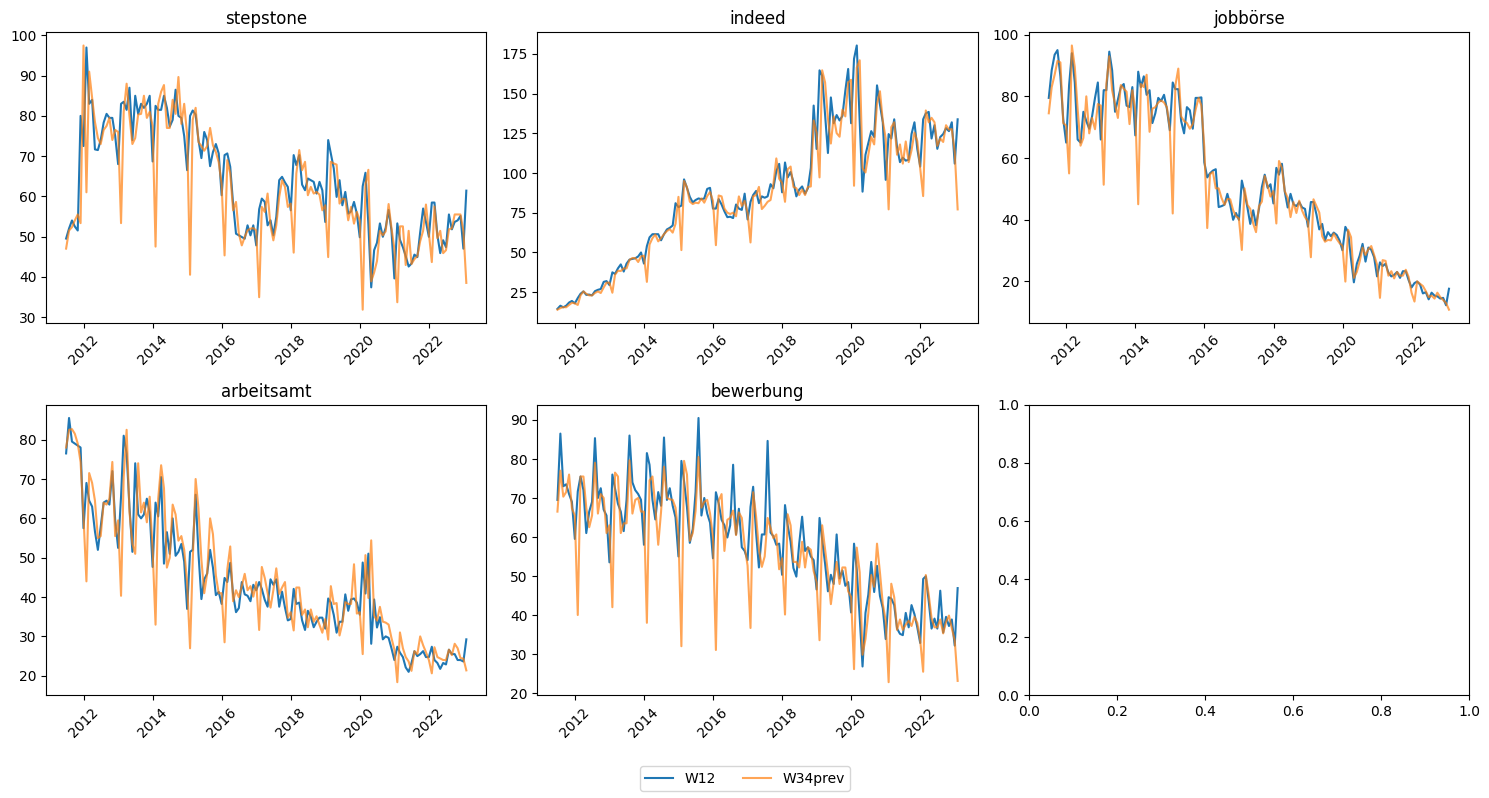

In [ ]:
import matplotlib.pyplot as plt

keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    ax.plot(panel.index, panel[f"{kw}_W12"], label="W12")
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label="W34prev", alpha=0.7)
    ax.set_title(kw)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


Both W12 and W34prev display highly regular and pronounced seasonal fluctuations, especially for the public–sector related terms arbeitsamt, jobbörse and bewerbung. These indicators follow a clear intra-year cycle with strong peaks at the turn of the year and troughs during summer months.
Especially W34prev tends to exhibit sharper seasonal spikes than the corresponding W12. This pattern is particularly visible for bewerbung and arbeitsamt, or also the first years of jobbörse.
We could maybe say the W34prev component captures search behaviour that takes place before the measurement of month M's unemployment and is unaffected by the publication of the unemployment M-1, whereas the W12 component partly reflects reactions to official unemployment announcements at the end of the previous month. As a result, W34prev appears to retain a “cleaner” seasonal signal.
For indeed, jobbörse, arbeitsamt and bewerbubg the long-run trend component is clear.
Searches for jobbörse and arbeitsamt exhibit a persistent downward trend over 2011–2023, consistent with declining usage of the public employment service's online channels.
On the other hand indeed shows a strong upward trajectories during the 2010s, reflecting the structural an increase when it comes toGerman job search over the years .
The series for bewerbung shows a gradual, monotonic decline, consistent with the reduced use of generic application-related searches due to templates, automated systems, and platform-driven application processes.
Interesting is that arbeitsamt indeed and stepstone feature episodic bursts, most notably around 2020–2021 during the COVID-19 shock. These spikes suggest heightened job-search uncertainty during periods of macroeconomic stress and motivate the use of models capable of capturing such nonlinearities.
Bewerbung and jobbörse on the other hand are not that affected and the trend remains to clear to see maybe also a consequence of the decline in suage or not the interest.
Overall the biweekly aggregation looks internally coherent and that both series track similar underlying behavioural patterns, with W34prev often showing a clearer seasonal structure.


## GT vs Unemployment (dual axis)

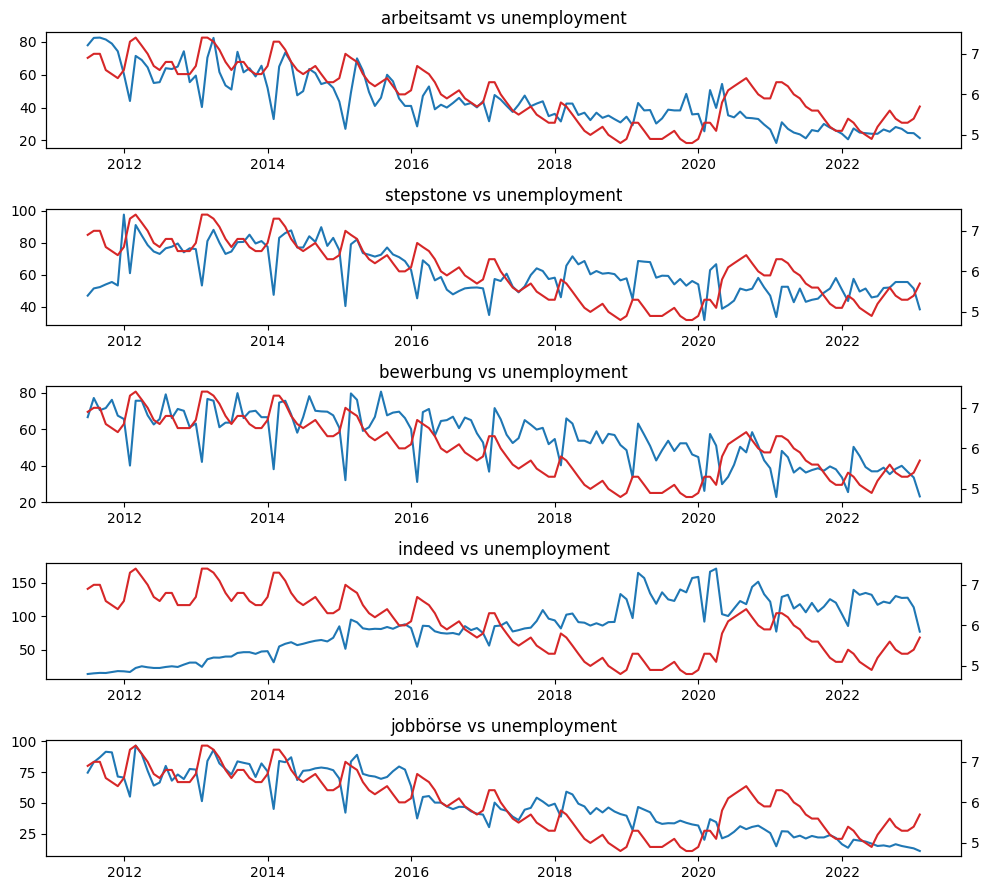

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W34prev"], label=f"{kw} (W34prev)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


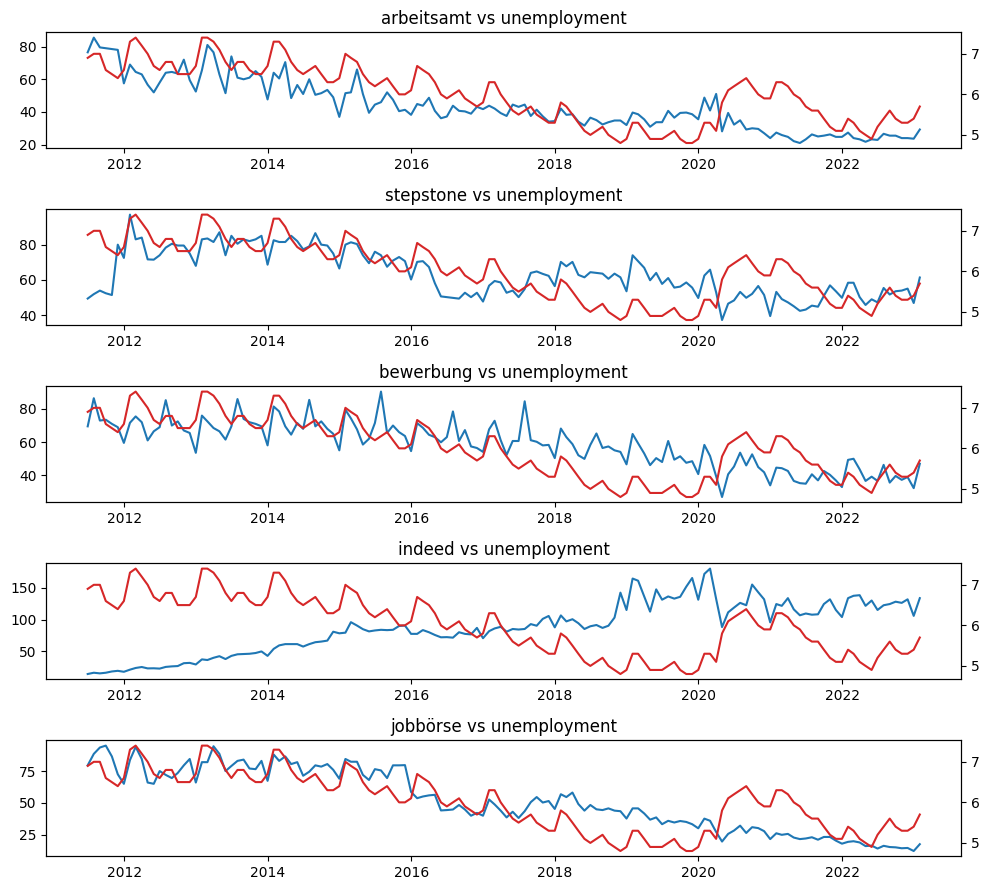

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9))

for ax, kw in zip(axes, ["arbeitsamt", "stepstone", "bewerbung","indeed","jobbörse"]):
    ax2 = ax.twinx()
    ax.plot(panel.index, panel[f"{kw}_W12"], label=f"{kw} (W12)", color="tab:blue")
    ax2.plot(panel.index, panel["Unemp"], label="Unemployment", color="tab:red")
    ax.set_title(f"{kw} vs unemployment")

plt.tight_layout()
plt.show()


## Cross correlation functions

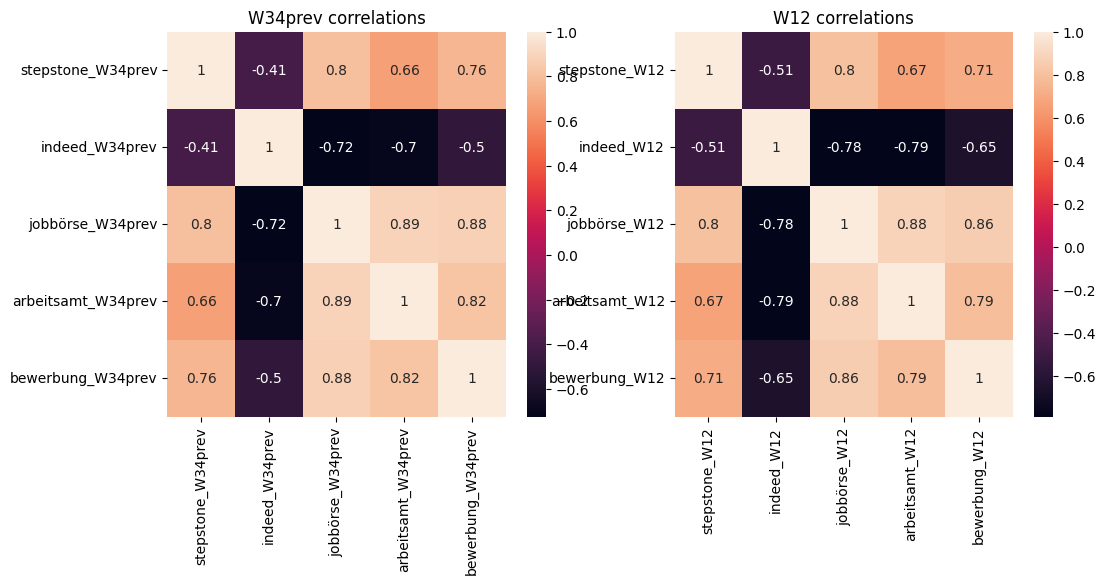

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(panel[[c for c in panel.columns if "W34prev" in c]].corr(), ax=axes[0], annot=True)
sns.heatmap(panel[[c for c in panel.columns if "W12" in c]].corr(), ax=axes[1], annot=True)
axes[0].set_title("W34prev correlations")
axes[1].set_title("W12 correlations")
plt.show()


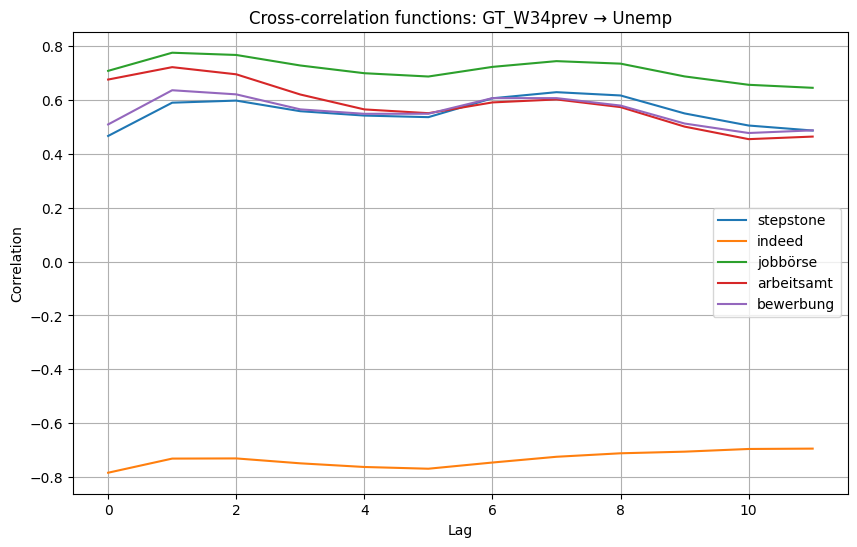

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
import numpy as np

keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]
lags = 12

plt.figure(figsize=(10, 6))

for kw in keywords:
    x = panel[f"{kw}_W34prev"]
    y = panel["Unemp"]
    corr = ccf(x, y)[:lags]
    plt.plot(range(lags), corr, label=f"{kw}")

plt.title("Cross-correlation functions: GT_W34prev → Unemp")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()



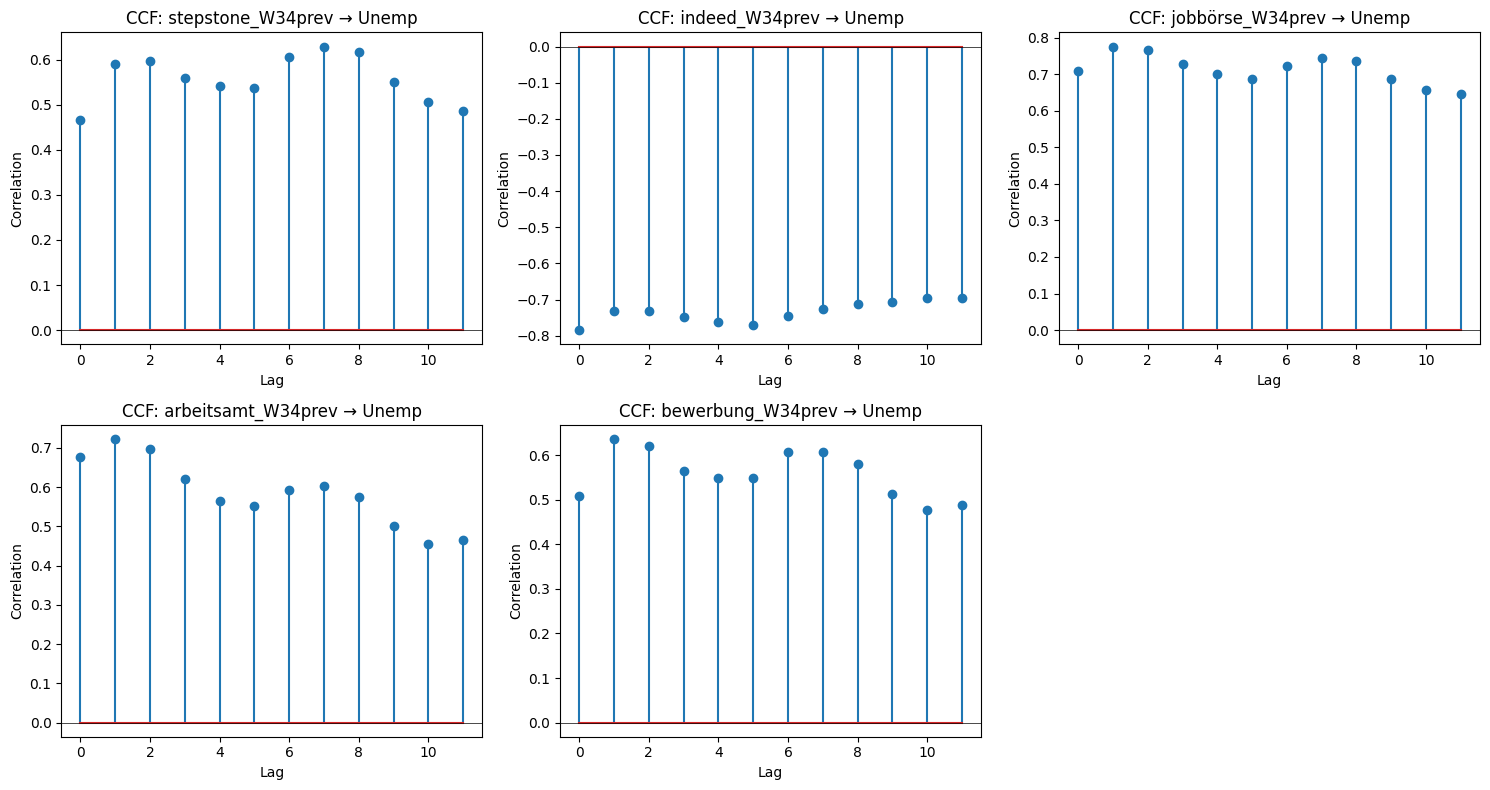

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
import numpy as np

keywords = ["stepstone", "indeed", "jobbörse", "arbeitsamt", "bewerbung"]

lags = 12
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, kw in zip(axes, keywords):
    x = panel[f"{kw}_W34prev"].astype(float).values
    y = panel["Unemp"].astype(float).values

    corr = ccf(x, y)[:lags]

    ax.stem(range(lags), corr)    # <-- FIXED
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_title(f"CCF: {kw}_W34prev → Unemp")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")

# Hide unused subplot
for ax in axes[len(keywords):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Seasonality boxplot

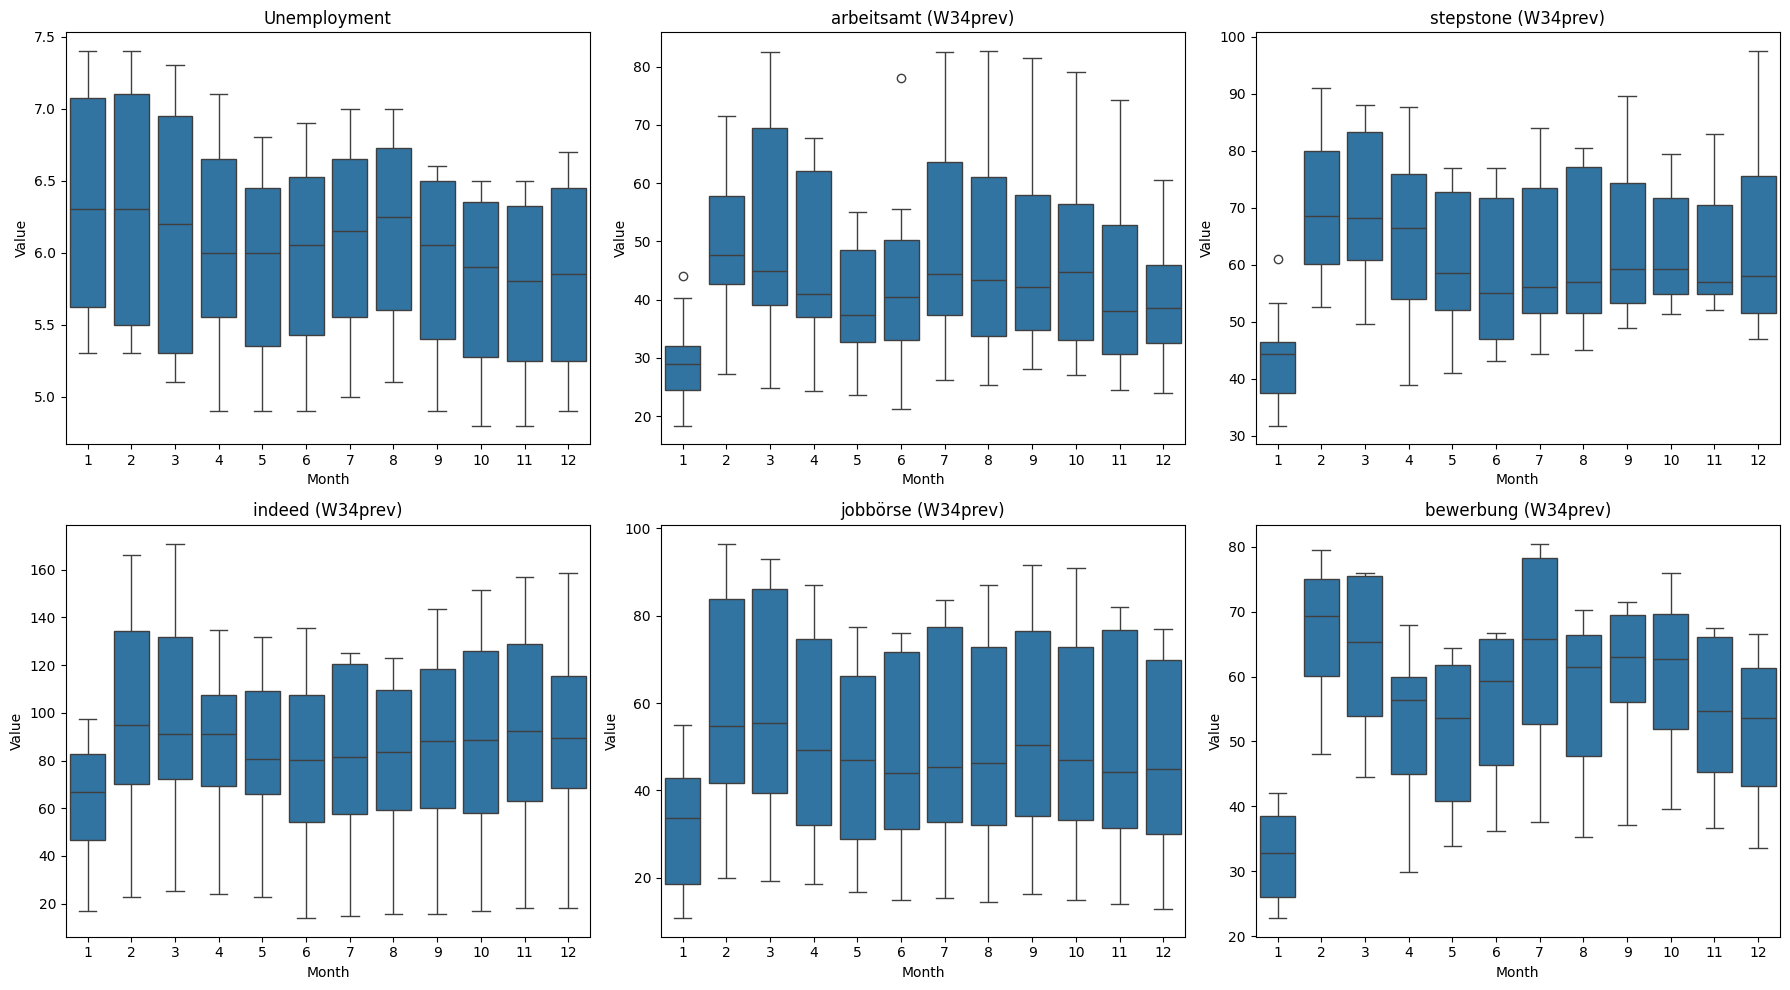

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure month column exists
panel["month"] = panel.index.month

# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W34prev",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "bewerbung_W34prev"
]

titles = [
    "Unemployment",
    "arbeitsamt (W34prev)",
    "stepstone (W34prev)",
    "indeed (W34prev)",
    "jobbörse (W34prev)",
    "bewerbung (W34prev)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


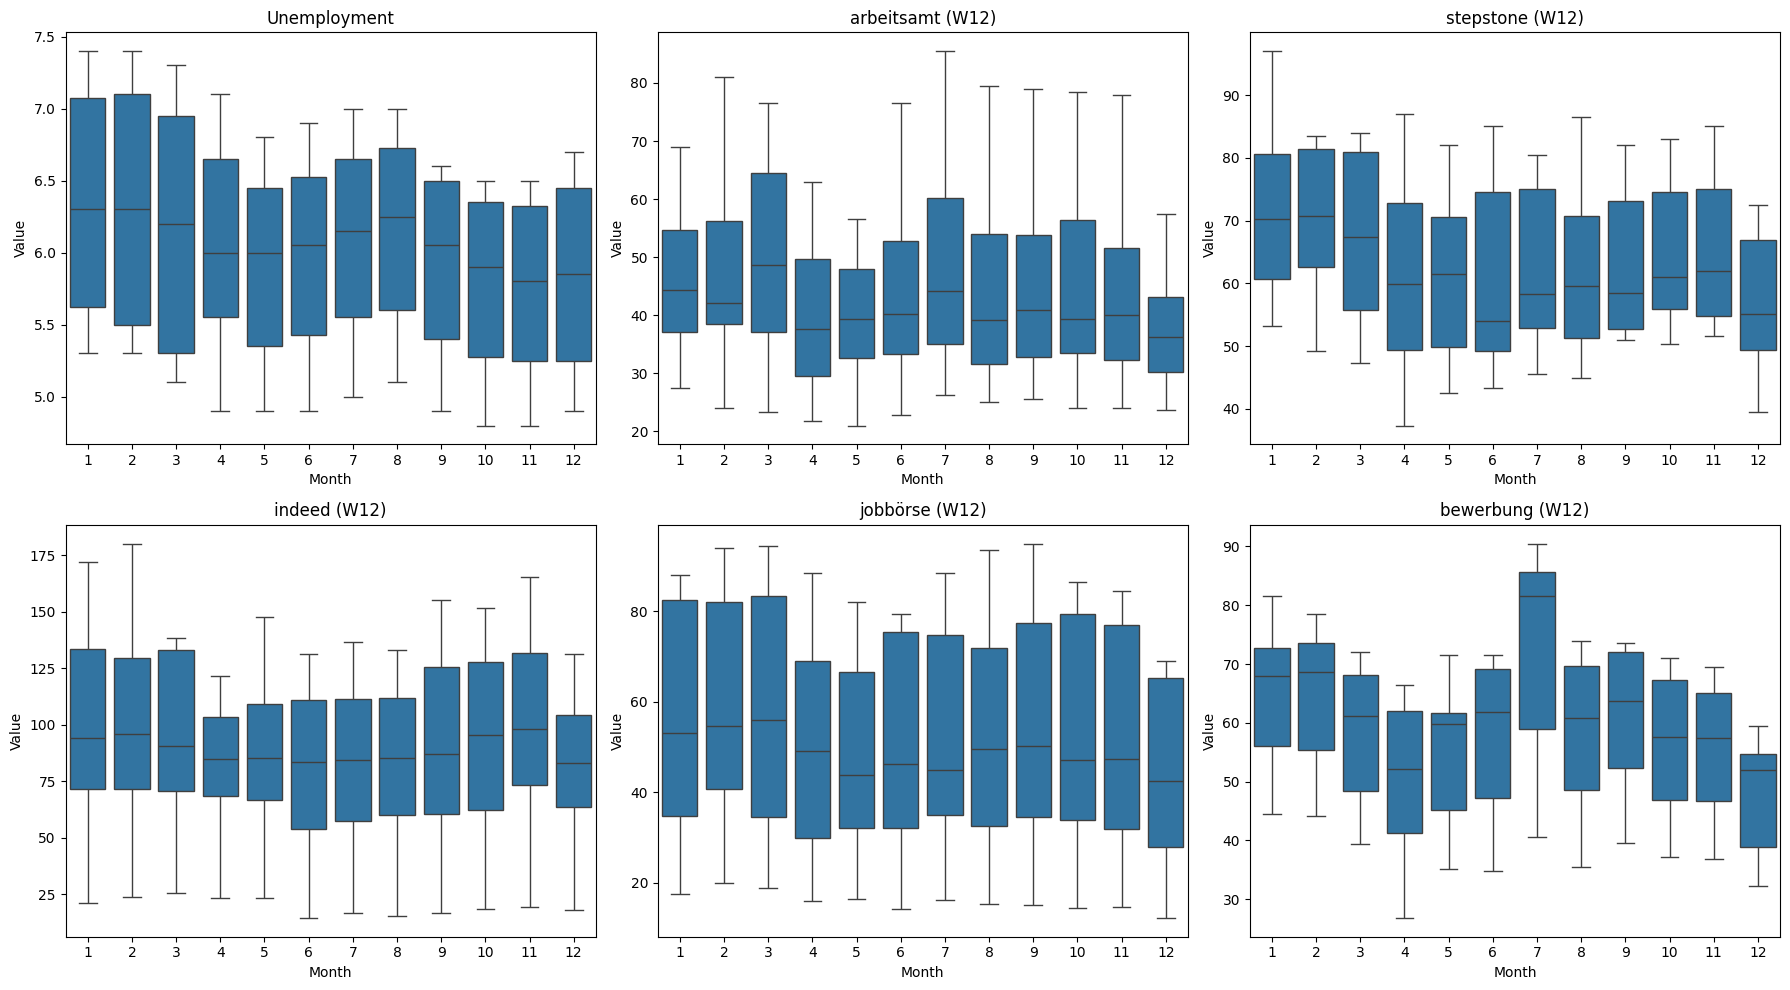

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure month column exists
panel["month"] = panel.index.month

# Order of variables shown in the grid
vars_to_plot = [
    "Unemp",
    "arbeitsamt_W12",
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "bewerbung_W12"
]

titles = [
    "Unemployment",
    "arbeitsamt (W12)",
    "stepstone (W12)",
    "indeed (W12)",
    "jobbörse (W12)",
    "bewerbung (W12)"
]

# Create 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, var, title in zip(axes, vars_to_plot, titles):
    sns.boxplot(x="month", y=var, data=panel, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Month")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## Normalized GT indicators

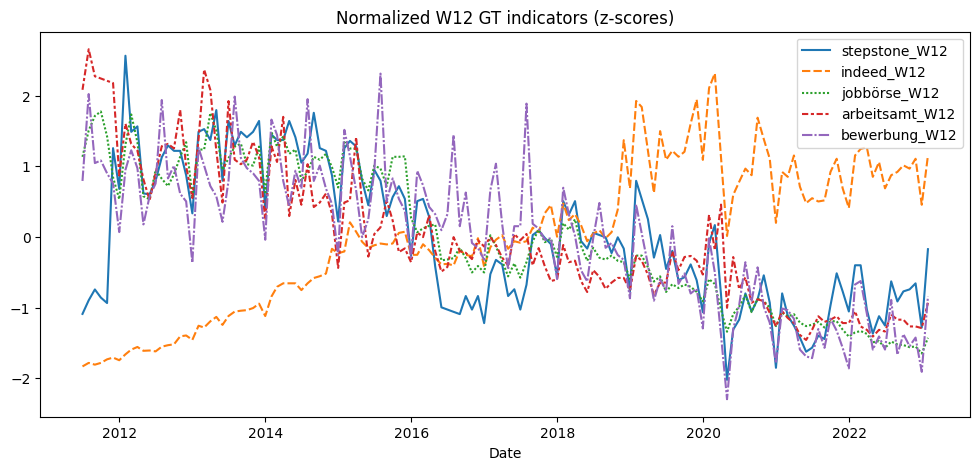

In [ ]:
import seaborn as sns

gt_cols = [col for col in panel.columns if "W12" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W12 GT indicators (z-scores)")
plt.show()


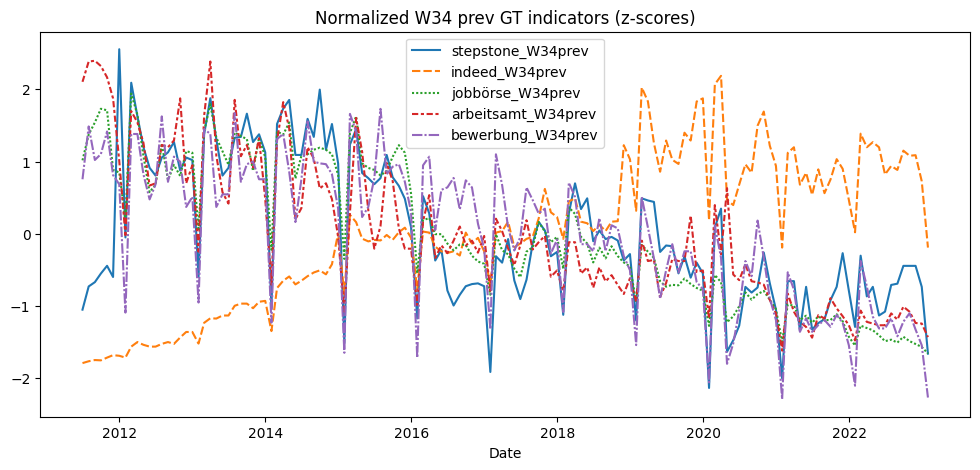

In [ ]:
import seaborn as sns

gt_cols = [col for col in panel.columns if "W34prev" in col]
gt_norm = (panel[gt_cols] - panel[gt_cols].mean()) / panel[gt_cols].std()

plt.figure(figsize=(12,5))
sns.lineplot(data=gt_norm)
plt.title("Normalized W34 prev GT indicators (z-scores)")
plt.show()


## Stationarity test 

In the following the Augmented Dickey Fuller test will be peformed on the series in order to assess stationarity of the variables

 The first plot will show stationarity including visual representation of the data and the second plot will give a summary of the results implied by the test
 


stepstone_W12 — lengths
level  raw n = 140
Δ1     raw n = 139


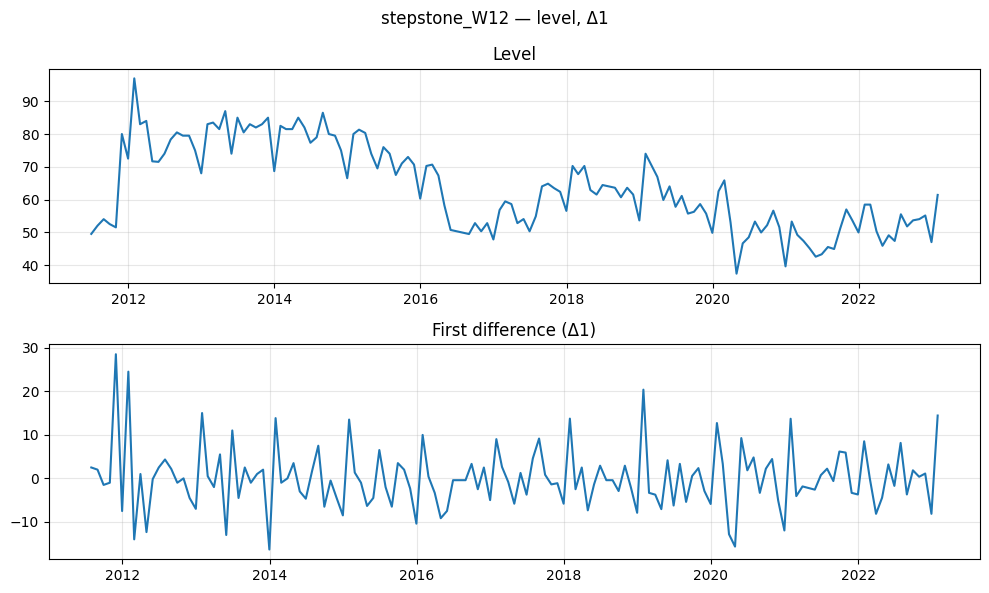

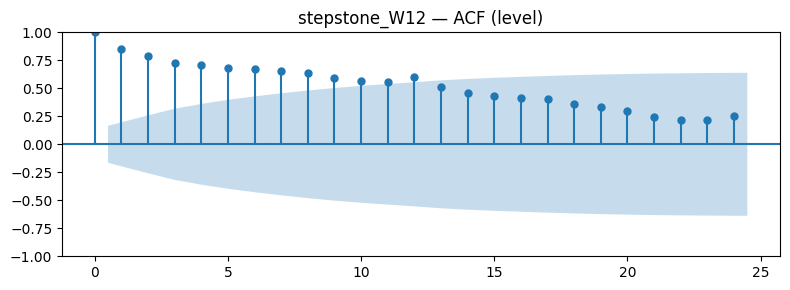

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W12     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W12     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W12     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W12     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W12     diff1  ct       NaN     NaN       NaN       NaN       139        NaN        NaN   

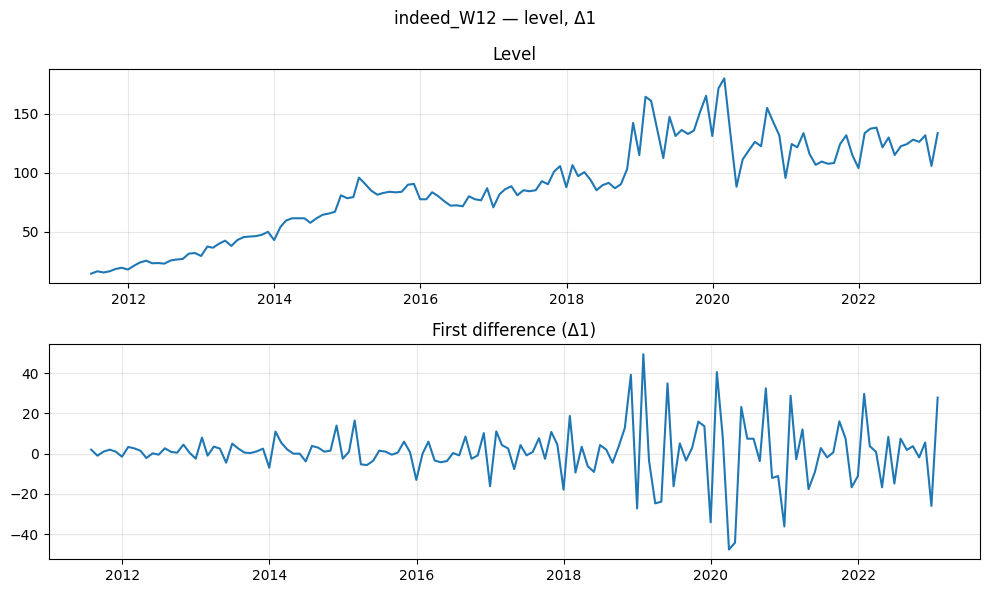

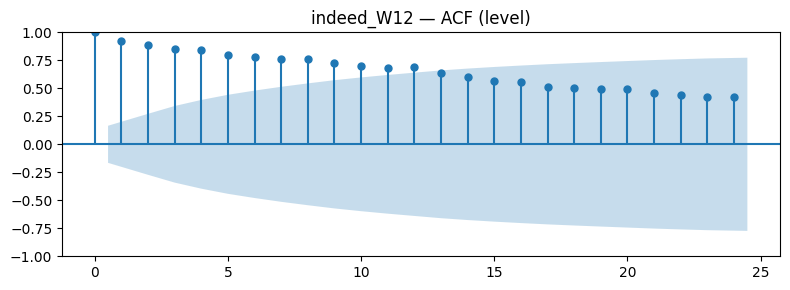

    series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W12     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W12     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W12     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W12     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W12     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W12     diff1  ct       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        Fals

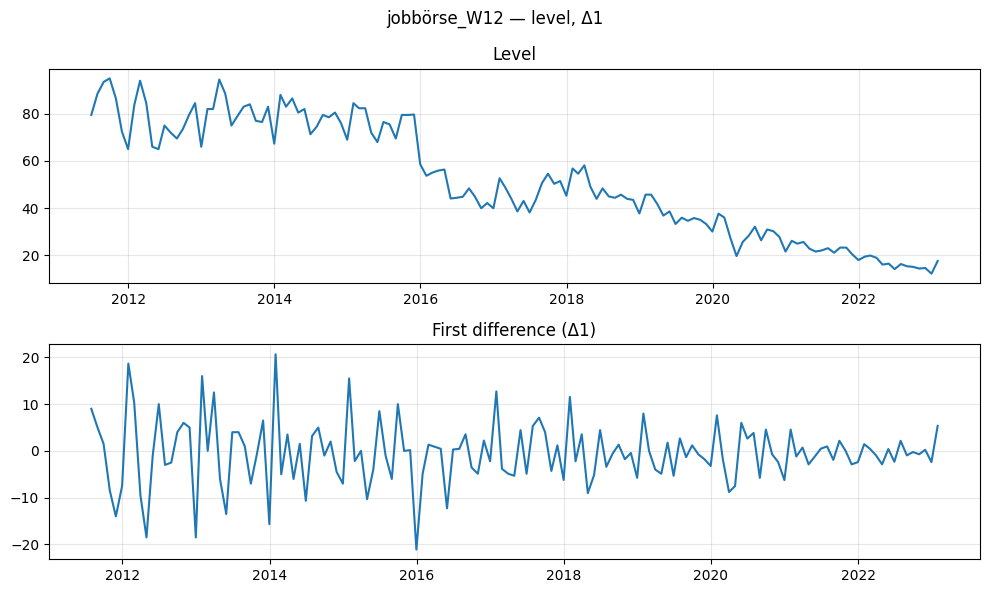

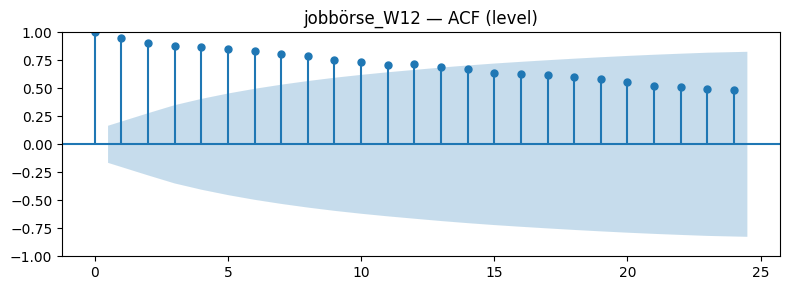

      series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W12     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W12     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W12     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W12     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W12     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W12     diff1  ct       NaN     NaN       NaN       NaN       139        NaN        NaN         N

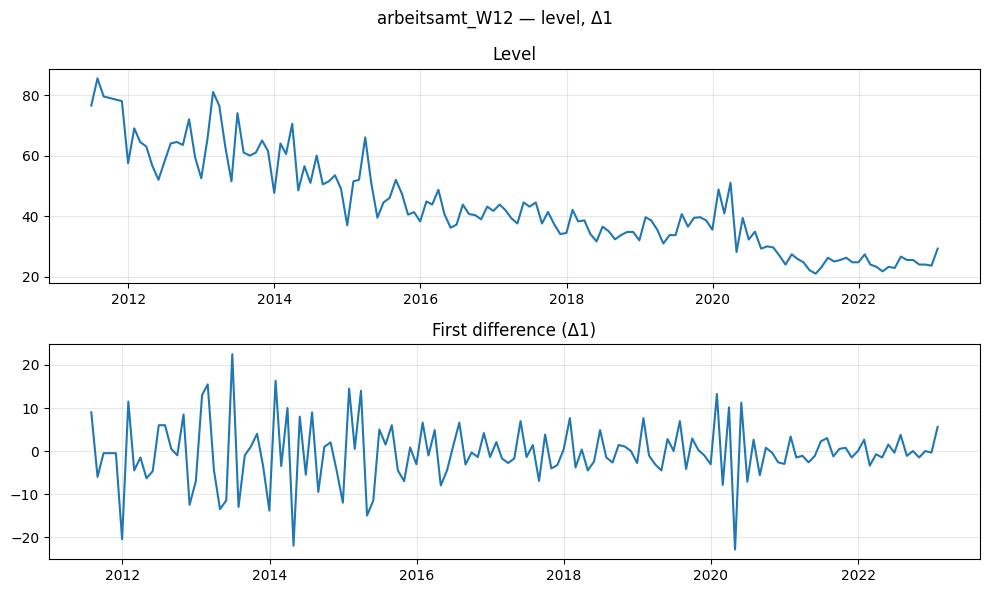

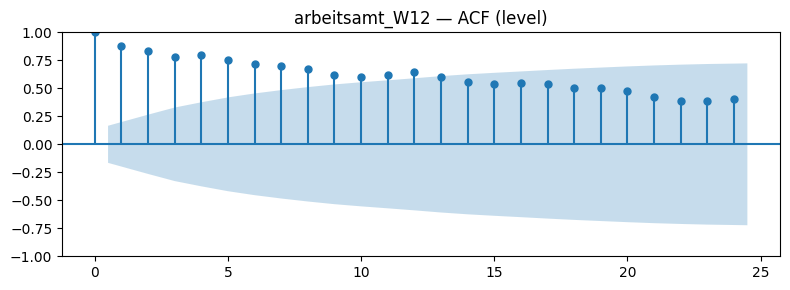

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W12     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W12     diff1  ct       NaN     NaN       NaN       NaN       139        NaN       

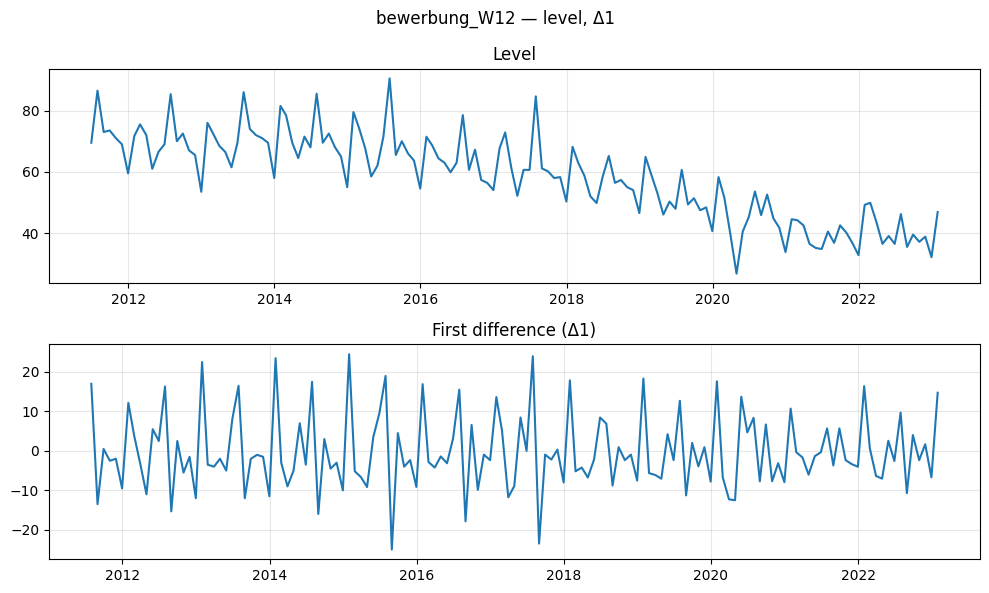

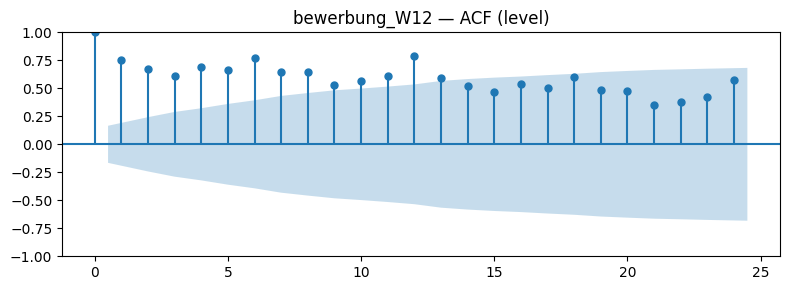

       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W12     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W12     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W12     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W12     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W12     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W12     diff1  ct       NaN     NaN       NaN       NaN       139        NaN        NaN   

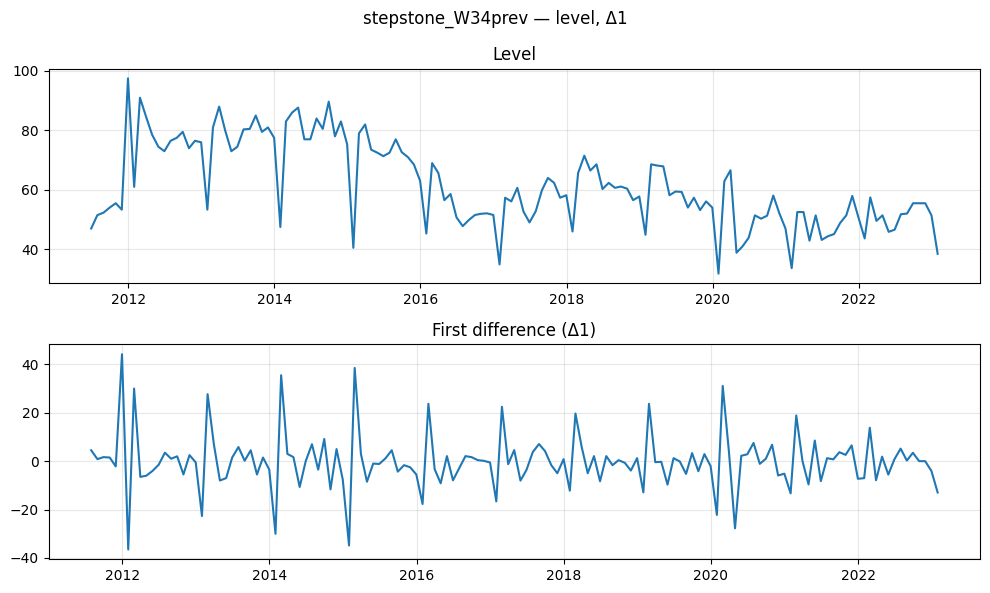

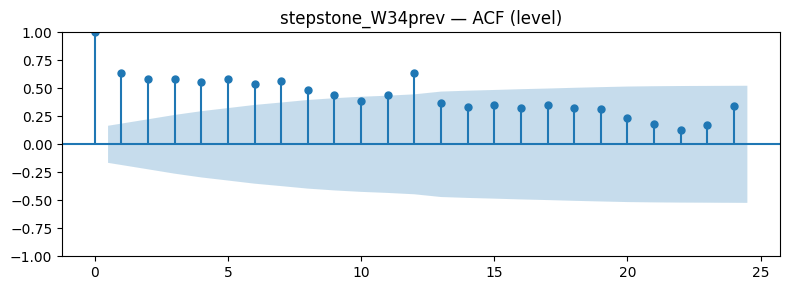

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W34prev     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W34prev     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W34prev     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
stepstone_W34prev     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W34prev     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
stepstone_W34prev     diff1  ct       NaN     NaN       NaN       NaN       

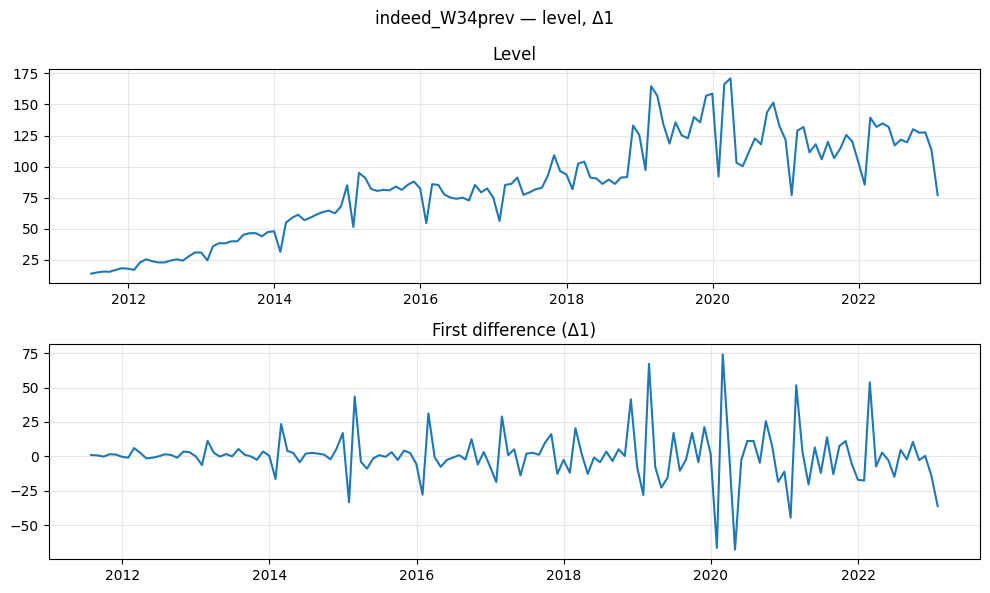

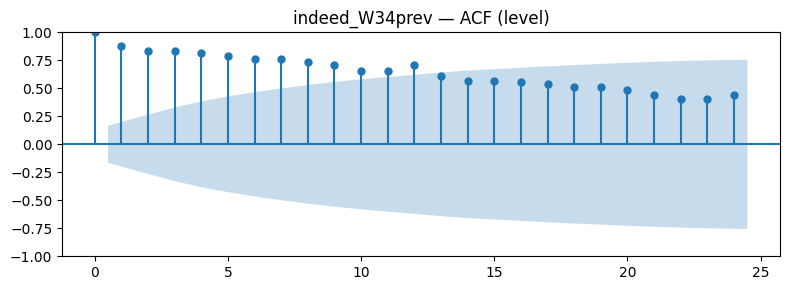

        series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed_W34prev     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W34prev     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W34prev     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
indeed_W34prev     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W34prev     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
indeed_W34prev     diff1  ct       NaN     NaN       NaN       NaN       139        NaN       

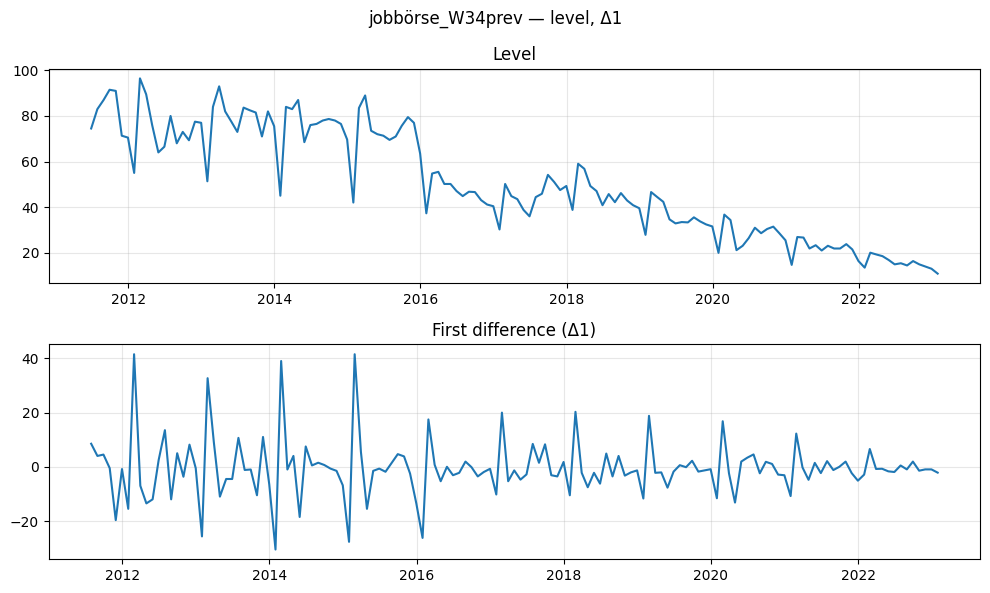

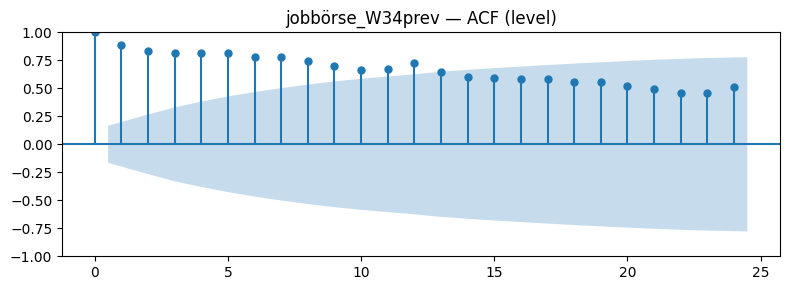

          series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse_W34prev     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
jobbörse_W34prev     diff1  ct       NaN     NaN       NaN       NaN       139    

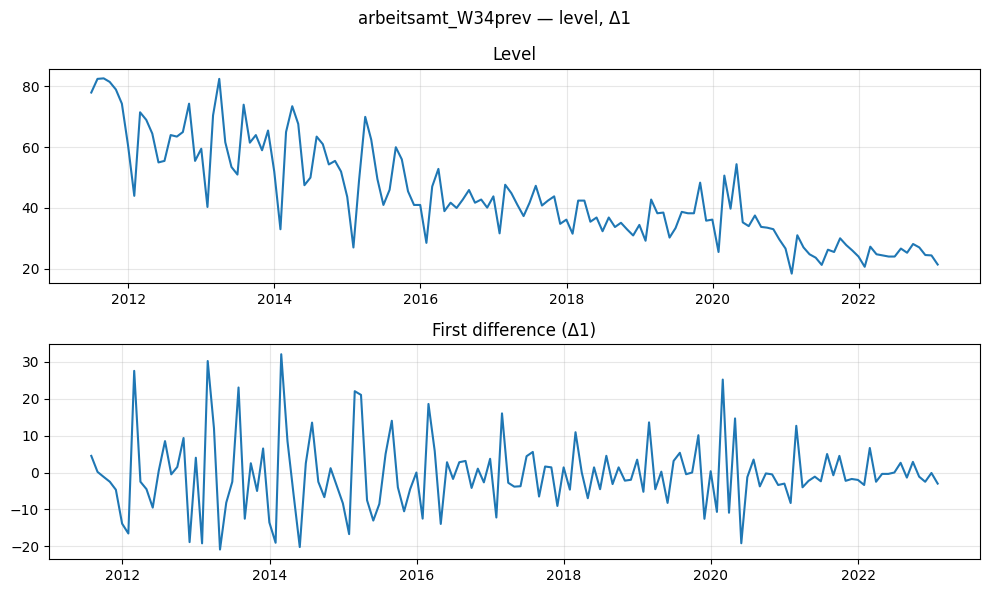

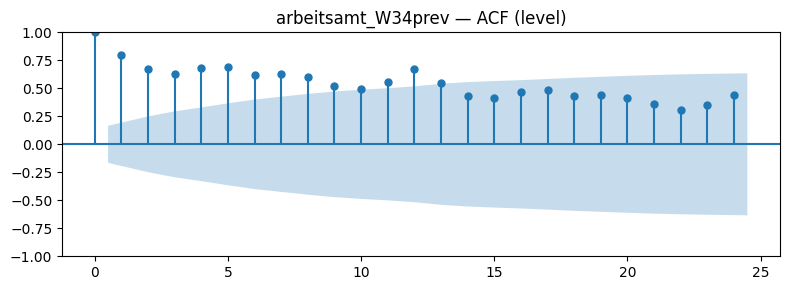

            series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt_W34prev     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
arbeitsamt_W34prev     diff1  ct       NaN     NaN       NaN       NaN

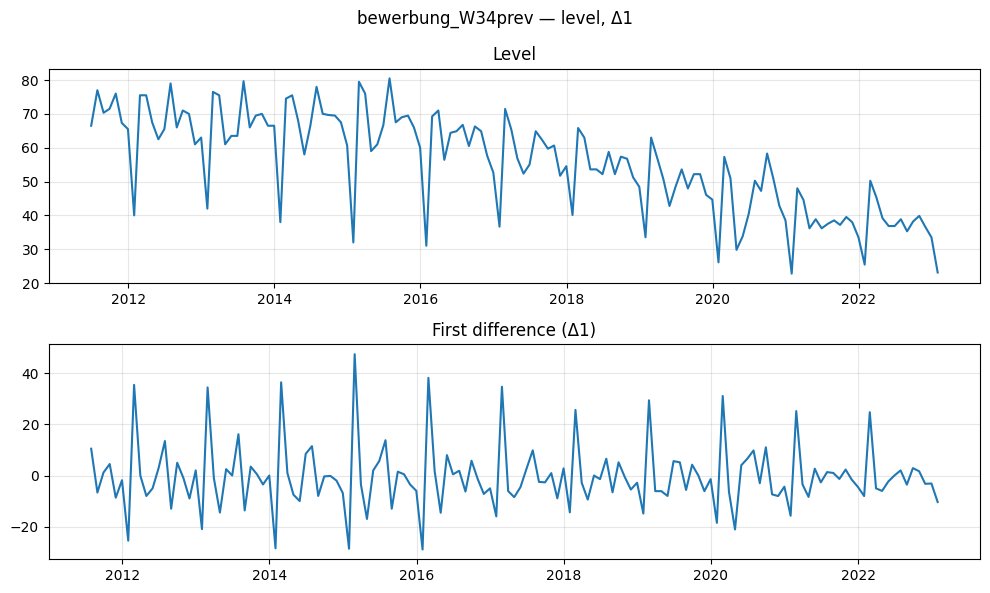

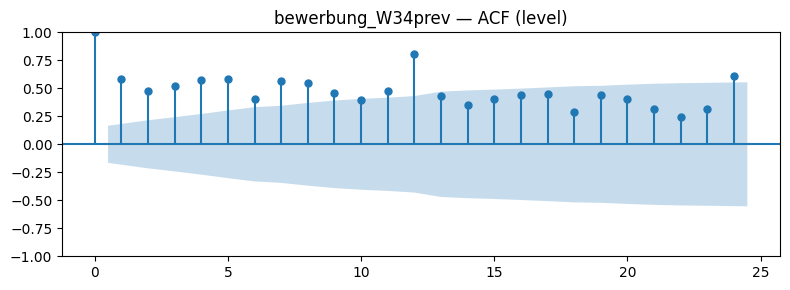

           series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung_W34prev     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
bewerbung_W34prev     diff1  ct       NaN     NaN       NaN       NaN       

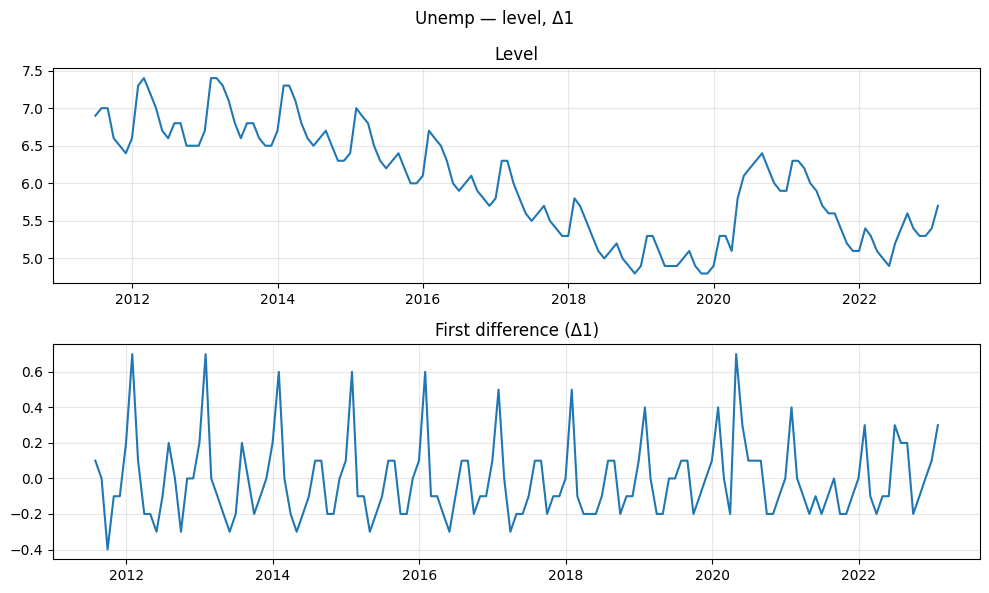

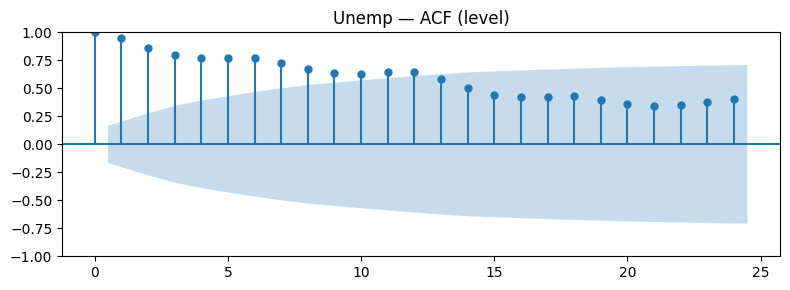

series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
 Unemp     level   n       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
 Unemp     level   c       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
 Unemp     level  ct       NaN     NaN       NaN       NaN       140        NaN        NaN         NaN        False        False         False
 Unemp     diff1   n       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
 Unemp     diff1   c       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False
 Unemp     diff1  ct       NaN     NaN       NaN       NaN       139        NaN        NaN         NaN        False        False         False

In [ ]:
# =========================
# Complete ADF test battery
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Config -----------------
PLOT_SERIES = True      # set False to skip line plots
PLOT_ACF = True         # set False to skip ACF
ACF_MAXLAG = 24
MIN_LEN = 20            # minimum raw length to even attempt an ADF
MAXLAG = 13          # None -> autolag="AIC"; else set an int (e.g., 12)
OUT_CSV = "adf_summary.csv"

# If your working DataFrame is 'panel_ecm', switch this:
# panel = panel_ecm

# ----------------- Helpers -----------------
# Removed: infer_seasonal_period function

def adf_all(y: pd.Series,
            name: str,
            maxlag: int | None = None,
            min_len: int = 20) -> pd.DataFrame:
    """
    Run ADF under regressions: 'n', 'c', 'ct' on
    - level
    - first difference (Δ1)
    Seasonal difference (Δm) logic removed.
    Returns a tidy DataFrame with stats, pvalues, used lag, obs counts, and critical values.
    """
    y = pd.Series(y, copy=False)
    cols = [
        "series","transform","reg",
        "adf_stat","pvalue",
        "used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    out = []

    def run_one(series, transform_label):
        series = pd.Series(series).dropna()
        nraw = int(series.shape[0])
        if nraw < min_len:
            for reg in ("n","c","ct"):
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))
            return

        for reg in ("n","c","ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag
                )
                c1, c5, c10 = crit.get("1%"), crit.get("5%"), crit.get("10%")
                # ADF rejects if stat is MORE NEGATIVE than critical value
                r1 = bool((stat is not None) and (c1 is not None) and (stat < c1))
                r5 = bool((stat is not None) and (c5 is not None) and (stat < c5))
                r10 = bool((stat is not None) and (c10 is not None) and (stat < c10))
                out.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))
            except Exception:
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff(), "diff1")
    # Removed: Seasonal difference (Δm) call

    return pd.DataFrame(out, columns=cols)

# ----------------- Main: per-column analysis -----------------
all_results = []
for col in panel.columns:
    s = pd.to_numeric(panel[col], errors="coerce")
    s_level = s.dropna()
    m = None # Set m to None as seasonal logic is removed

    print("\n" + "="*80)
    print(f"{col} — lengths")
    print(f"level  raw n = {s_level.shape[0]}")
    print(f"Δ1     raw n = {s.diff().dropna().shape[0]}")
    # Removed: Seasonal length print (if m)

    # Optional plots - Restored for Level and Diff1 only
    if PLOT_SERIES:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
        fig.suptitle(f"{col} — level, Δ1", y=0.98)
        # level
        if not s_level.empty:
            axes[0].plot(s_level.index, s_level.values)
        axes[0].set_title("Level")
        axes[0].grid(True, alpha=0.3)
        # Δ1
        d1 = s.diff().dropna()
        if not d1.empty:
            axes[1].plot(d1.index, d1.values)
        axes[1].set_title("First difference (Δ1)")
        axes[1].grid(True, alpha=0.3)
        # Removed: Δm plot

        plt.tight_layout()
        plt.show()

    if PLOT_ACF:
        vals = s_level
        if len(vals) > ACF_MAXLAG:
            fig2, ax2 = plt.subplots(figsize=(8, 3))
            plot_acf(vals, ax=ax2, lags=ACF_MAXLAG)
            ax2.set_title(f"{col} — ACF (level)")
            plt.tight_layout()
            plt.show()

    # Run ADFs
    res = adf_all(
        s,
        name=col,
        maxlag=MAXLAG,
        min_len=MIN_LEN,
        # Removed: seasonal_period=m
    )

    # Nice compact display for this series
    display_cols = [
        "series","transform","reg",
        "adf_stat","pvalue","used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res[display_cols].to_string(index=False))

    all_results.append(res)

# ----------------- Portfolio summary & export -----------------
adf_summary = pd.concat(all_results, ignore_index=True)

# convenience flags at 5%
adf_summary["reject_5pct_flag"] = adf_summary["reject_5pct"].astype(bool)

# What is stationary at level under ANY deterministic spec?
stationary_level_any = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].any()
               .reset_index(name="reject_at_level_any_spec_5pct")
)

# Robust (ALL specs reject at 5%) — stricter
stationary_level_all = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].all()
               .reset_index(name="reject_at_level_all_specs_5pct")
)

print("\n" + "-"*80)
print("Stationary at LEVEL (p<0.05) under ANY spec:")
print(stationary_level_any.to_string(index=False))
print("\nStationary at LEVEL (p<0.05) under ALL specs (strict):")
print(stationary_level_all.to_string(index=False))

# Best spec per transform by smallest p-value (for reporting)
best_by_p = (
    adf_summary
    .dropna(subset=["pvalue"])
    .sort_values(["series","transform","pvalue"], ascending=[True, True, True])
    .groupby(["series","transform"], as_index=False)
    .first()[["series","transform","reg","adf_stat","pvalue","used_lag","nobs_eff"]]
    .rename(columns={"reg":"best_reg_by_min_p"})
)
print("\nBest ADF (min p-value) per series x transform:")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(best_by_p.to_string(index=False))

# Save full tidy table
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results to: {OUT_CSV}")

## The summary table for the biweekly aggregation

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# panel is your DataFrame with Date index and the 11 columns

MIN_LEN = 20
MAXLAG = 13           # upper bound for monthly data (you can tweak)
OUT_CSV = "adf_panel_simple.csv"

def run_adf(series: pd.Series,
            name: str,
            maxlag: int = MAXLAG,
            min_len: int = MIN_LEN) -> pd.DataFrame:
    """
    Run ADF on level and first difference of `series`
    under regressions: 'nc', 'c', 'ct'.

    Returns a tidy DataFrame with:
    - test statistic
    - p-value
    - chosen lag
    - effective nobs
    - MacKinnon critical values
    - rejection flags at 1/5/10%.
    """
    series = pd.to_numeric(series, errors="coerce")
    series = series.dropna()

    results = []
    cols = [
        "series", "transform", "reg",
        "adf_stat", "pvalue",
        "used_lag", "nobs_eff", "nobs_raw",
        "crit_1pct", "crit_5pct", "crit_10pct",
        "reject_1pct", "reject_5pct", "reject_10pct"
    ]

    def run_one(x, transform_label):
        x = pd.Series(x).dropna()
        nraw = x.shape[0]

        if nraw < min_len:
            for reg in ("n", "c", "ct"):
                results.append((name, transform_label, reg,
                                np.nan, np.nan,
                                np.nan, np.nan, nraw,
                                np.nan, np.nan, np.nan,
                                False, False, False))
            return

        for reg in ("n", "c", "ct"):
            stat, p, usedlag, nobs, crit, icbest = adfuller(
                x,
                regression=reg,           # 'nc', 'c', or 'ct'
                maxlag=maxlag,
                autolag="AIC"             # choose lag by AIC up to maxlag
            )
            c1, c5, c10 = crit["1%"], crit["5%"], crit["10%"]

            # reject if statistic is more negative than critical value
            r1 = stat < c1
            r5 = stat < c5
            r10 = stat < c10

            results.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))

    # Level
    run_one(series, "level")
    # First difference
    run_one(series.diff(), "diff1")

    return pd.DataFrame(results, columns=cols)


# ================= Main loop over columns =================

all_res = []

for col in panel.columns:
    res = run_adf(panel[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved ADF summary to {OUT_CSV}")



ADF results for stepstone_W12
       series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone_W12     level   n   -0.9831  0.2949        12       127       140    -2.5836    -1.9433     -1.6149        False        False         False
stepstone_W12     level   c   -1.6889  0.4368        13       126       140    -3.4833    -2.8848     -2.5792        False        False         False
stepstone_W12     level  ct   -2.5111  0.3224        13       126       140    -4.0325    -3.4459     -3.1478        False        False         False
stepstone_W12     diff1   n   -3.2242  0.0013        11       127       139    -2.5836    -1.9433     -1.6149         True         True          True
stepstone_W12     diff1   c   -3.2986  0.0149        11       127       139    -3.4829    -2.8846     -2.5791        False         True          True
stepstone_W12     diff1  ct   -3.2441  0.0760        11       127    

## Testing the time series without the biweekly aggregation

The dataset hence therefore

In [ ]:
df_week

,Date,stepstone,indeed,jobbörse,arbeitsamt,bewerbung
0,2011-05-01,49.000000,14.000000,75.000000,86.000000,63.000000
1,2011-05-08,50.000000,14.000000,80.000000,84.000000,68.000000
2,2011-05-15,52.000000,14.000000,80.000000,87.000000,73.000000
3,2011-05-22,52.000000,15.000000,80.000000,83.000000,73.000000
4,2011-05-29,42.000000,13.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...,...
609,2023-01-01,60.670120,128.215336,16.313392,26.270023,42.207649
610,2023-01-08,58.450482,139.364496,18.712420,30.773455,48.907276
611,2023-01-15,65.109398,133.789916,17.752809,30.773455,49.577239
612,2023-01-22,64.369518,146.797269,16.313392,29.272311,48.237313


In [9]:
df_week.drop(columns="Date", axis = 1, inplace=True)


stepstone — lengths
level  raw n = 614
Δ1     raw n = 613


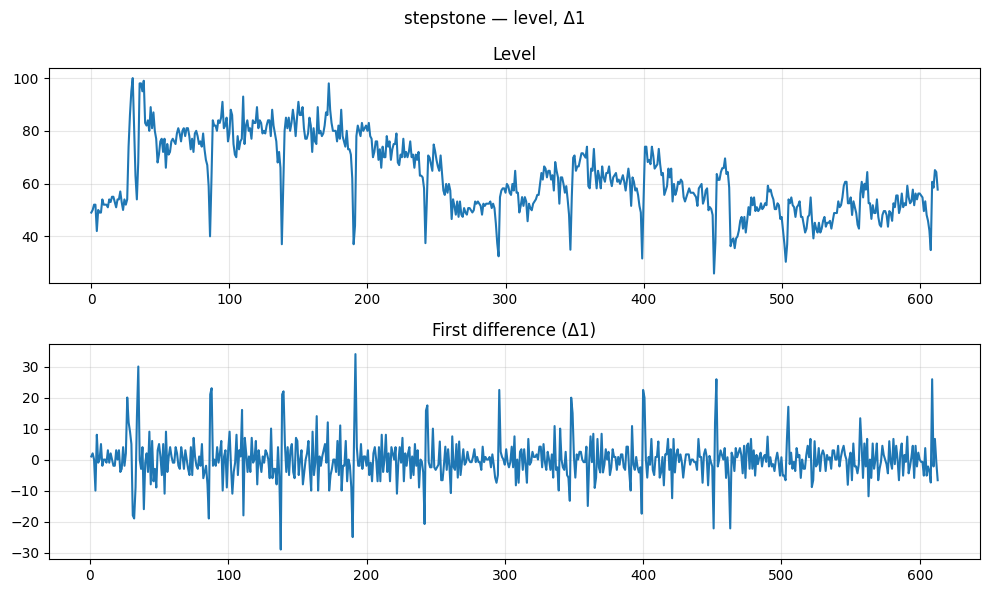

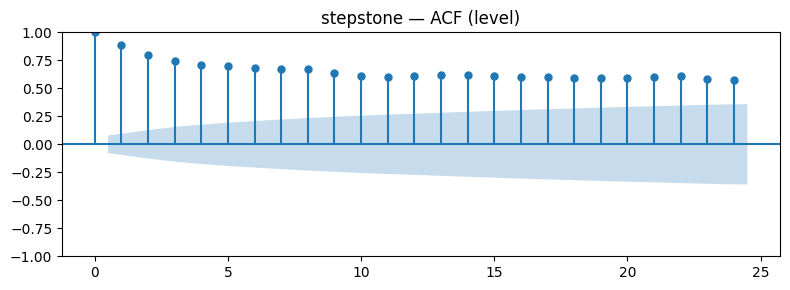

   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone     level   n   -0.3352  0.5624        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
stepstone     level   c   -2.4799  0.1204        11       602       614    -3.4413    -2.8664     -2.5693        False        False         False
stepstone     level  ct   -4.9716  0.0002         8       605       614    -3.9738    -3.4178     -3.1313         True         True          True
stepstone     diff1   n  -10.1611  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
stepstone     diff1   c  -10.1526  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
stepstone     diff1  ct  -10.1639  0.0000        12       600       613    -3.9739    -3.4178     -3.1314         True      

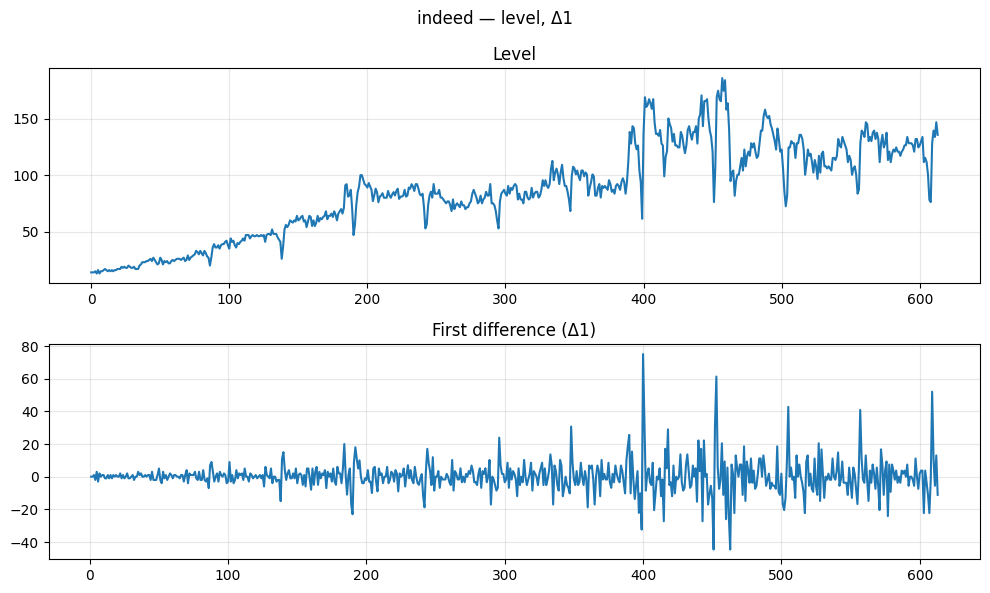

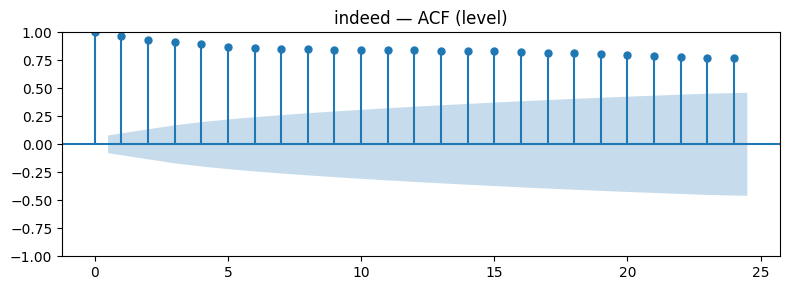

series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
indeed     level   n    0.5039  0.8258        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
indeed     level   c   -1.6991  0.4316        13       600       614    -3.4413    -2.8664     -2.5693        False        False         False
indeed     level  ct   -2.5549  0.3011        13       600       614    -3.9739    -3.4178     -3.1314        False        False         False
indeed     diff1   n  -10.8664  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
indeed     diff1   c  -10.9492  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
indeed     diff1  ct  -10.9738  0.0000        12       600       613    -3.9739    -3.4178     -3.1314         True         True          True

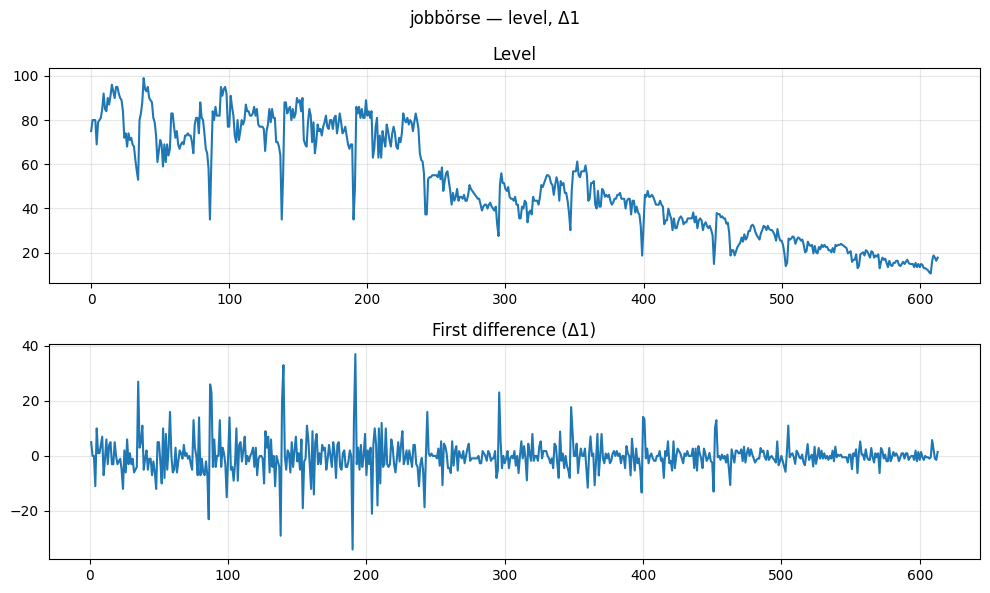

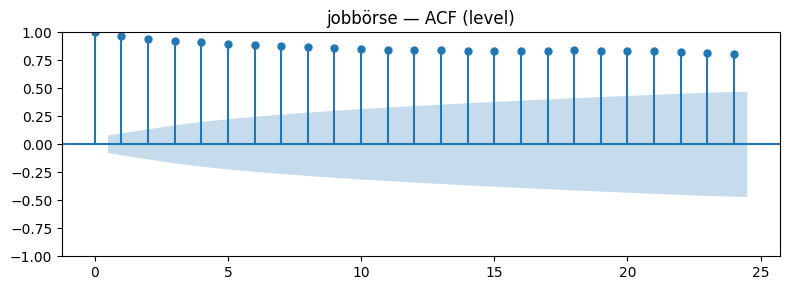

  series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
jobbörse     level   n   -2.1743  0.0285        17       596       614    -2.5695    -1.9415     -1.6164        False         True          True
jobbörse     level   c   -0.7207  0.8413        17       596       614    -3.4414    -2.8664     -2.5694        False        False         False
jobbörse     level  ct   -2.6936  0.2388        17       596       614    -3.9740    -3.4179     -3.1314        False        False         False
jobbörse     diff1   n  -10.7973  0.0000        16       596       613    -2.5695    -1.9415     -1.6164         True         True          True
jobbörse     diff1   c  -11.0213  0.0000        16       596       613    -3.4414    -2.8664     -2.5694         True         True          True
jobbörse     diff1  ct  -11.0095  0.0000        16       596       613    -3.9740    -3.4179     -3.1314         True         True

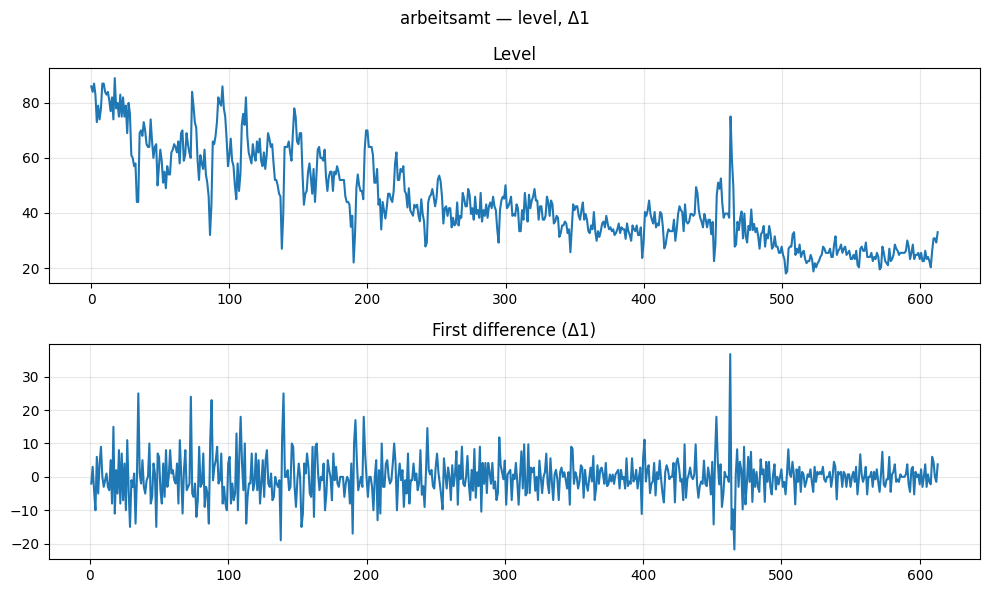

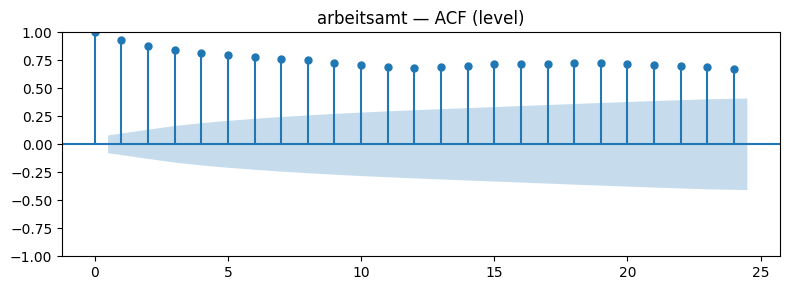

    series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
arbeitsamt     level   n   -2.6074  0.0088        17       596       614    -2.5695    -1.9415     -1.6164         True         True          True
arbeitsamt     level   c   -2.5107  0.1129        17       596       614    -3.4414    -2.8664     -2.5694        False        False         False
arbeitsamt     level  ct   -4.0095  0.0085        17       596       614    -3.9740    -3.4179     -3.1314         True         True          True
arbeitsamt     diff1   n  -11.5996  0.0000        16       596       613    -2.5695    -1.9415     -1.6164         True         True          True
arbeitsamt     diff1   c  -11.7838  0.0000        16       596       613    -3.4414    -2.8664     -2.5694         True         True          True
arbeitsamt     diff1  ct  -11.8675  0.0000        16       596       613    -3.9740    -3.4179     -3.1314         Tru

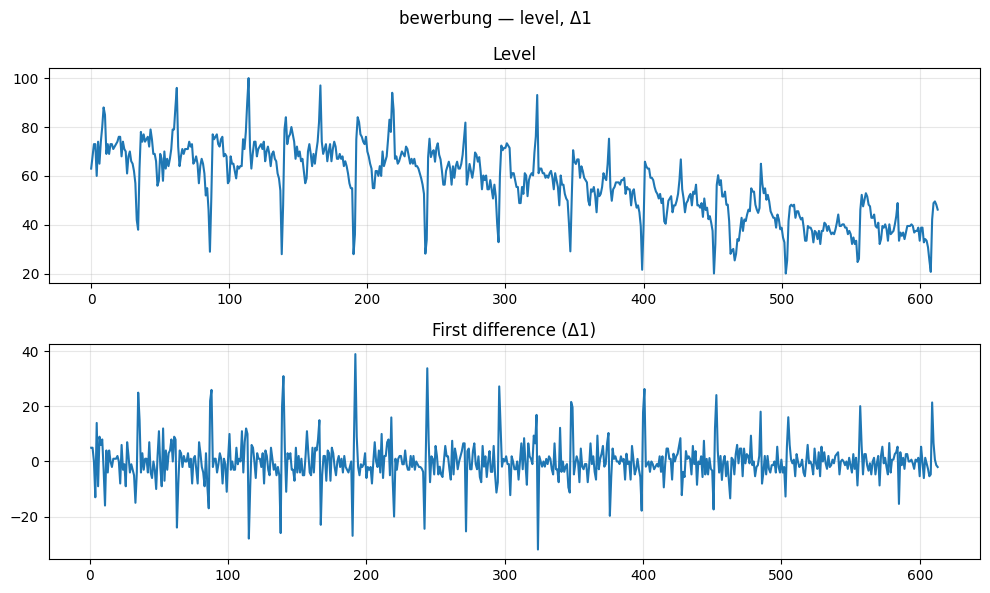

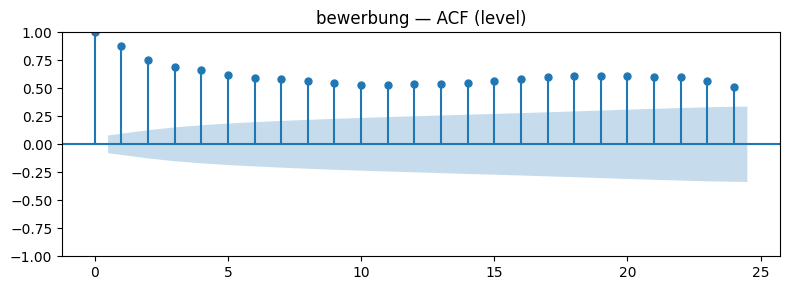

   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
bewerbung     level   n   -1.1954  0.2122        17       596       614    -2.5695    -1.9415     -1.6164        False        False         False
bewerbung     level   c   -1.4342  0.5658        17       596       614    -3.4414    -2.8664     -2.5694        False        False         False
bewerbung     level  ct   -9.1825  0.0000         2       611       614    -3.9737    -3.4177     -3.1313         True         True          True
bewerbung     diff1   n   -9.9999  0.0000        19       593       613    -2.5695    -1.9415     -1.6164         True         True          True
bewerbung     diff1   c  -10.0681  0.0000        19       593       613    -3.4414    -2.8664     -2.5694         True         True          True
bewerbung     diff1  ct  -10.0578  0.0000        19       593       613    -3.9741    -3.4179     -3.1314         True      

In [ ]:
# =========================
# Complete ADF test battery
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# ----------------- Config -----------------
PLOT_SERIES = True      # set False to skip line plots
PLOT_ACF = True         # set False to skip ACF
ACF_MAXLAG = 24
MIN_LEN = 20            # minimum raw length to even attempt an ADF
MAXLAG = None          # None -> autolag="AIC"; else set an int (e.g., 12)
OUT_CSV = "adf_summary.csv"

# If your working DataFrame is 'panel_ecm', switch this:
# panel = panel_ecm

# ----------------- Helpers -----------------
# Removed: infer_seasonal_period function

def adf_all(y: pd.Series,
            name: str,
            maxlag: int | None = None,
            min_len: int = 20) -> pd.DataFrame:
    """
    Run ADF under regressions: 'n', 'c', 'ct' on
    - level
    - first difference (Δ1)
    Seasonal difference (Δm) logic removed.
    Returns a tidy DataFrame with stats, pvalues, used lag, obs counts, and critical values.
    """
    y = pd.Series(y, copy=False)
    cols = [
        "series","transform","reg",
        "adf_stat","pvalue",
        "used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    out = []

    def run_one(series, transform_label):
        series = pd.Series(series).dropna()
        nraw = int(series.shape[0])
        if nraw < min_len:
            for reg in ("n","c","ct"):
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))
            return

        for reg in ("n","c","ct"):
            try:
                stat, p, usedlag, nobs, crit, icbest = adfuller(
                    series,
                    regression=reg,
                    autolag="AIC" if maxlag is None else None,
                    maxlag=maxlag
                )
                c1, c5, c10 = crit.get("1%"), crit.get("5%"), crit.get("10%")
                # ADF rejects if stat is MORE NEGATIVE than critical value
                r1 = bool((stat is not None) and (c1 is not None) and (stat < c1))
                r5 = bool((stat is not None) and (c5 is not None) and (stat < c5))
                r10 = bool((stat is not None) and (c10 is not None) and (stat < c10))
                out.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))
            except Exception:
                out.append((name, transform_label, reg,
                            np.nan, np.nan,
                            np.nan, np.nan, nraw,
                            np.nan, np.nan, np.nan,
                            False, False, False))

    # Level
    run_one(y, "level")
    # Δ1
    run_one(y.diff(), "diff1")
    # Removed: Seasonal difference (Δm) call

    return pd.DataFrame(out, columns=cols)

# ----------------- Main: per-column analysis -----------------
all_results = []
for col in df_week.columns:
    s = pd.to_numeric(df_week[col], errors="coerce")
    s_level = s.dropna()
    m = None # Set m to None as seasonal logic is removed

    print("\n" + "="*80)
    print(f"{col} — lengths")
    print(f"level  raw n = {s_level.shape[0]}")
    print(f"Δ1     raw n = {s.diff().dropna().shape[0]}")
    # Removed: Seasonal length print (if m)

    # Optional plots - Restored for Level and Diff1 only
    if PLOT_SERIES:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
        fig.suptitle(f"{col} — level, Δ1", y=0.98)
        # level
        if not s_level.empty:
            axes[0].plot(s_level.index, s_level.values)
        axes[0].set_title("Level")
        axes[0].grid(True, alpha=0.3)
        # Δ1
        d1 = s.diff().dropna()
        if not d1.empty:
            axes[1].plot(d1.index, d1.values)
        axes[1].set_title("First difference (Δ1)")
        axes[1].grid(True, alpha=0.3)
        # Removed: Δm plot

        plt.tight_layout()
        plt.show()

    if PLOT_ACF:
        vals = s_level
        if len(vals) > ACF_MAXLAG:
            fig2, ax2 = plt.subplots(figsize=(8, 3))
            plot_acf(vals, ax=ax2, lags=ACF_MAXLAG)
            ax2.set_title(f"{col} — ACF (level)")
            plt.tight_layout()
            plt.show()

    # Run ADFs
    res = adf_all(
        s,
        name=col,
        maxlag=MAXLAG,
        min_len=MIN_LEN,
        # Removed: seasonal_period=m
    )

    # Nice compact display for this series
    display_cols = [
        "series","transform","reg",
        "adf_stat","pvalue","used_lag","nobs_eff","nobs_raw",
        "crit_1pct","crit_5pct","crit_10pct",
        "reject_1pct","reject_5pct","reject_10pct"
    ]
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res[display_cols].to_string(index=False))

    all_results.append(res)

# ----------------- Portfolio summary & export -----------------
adf_summary = pd.concat(all_results, ignore_index=True)

# convenience flags at 5%
adf_summary["reject_5pct_flag"] = adf_summary["reject_5pct"].astype(bool)

# What is stationary at level under ANY deterministic spec?
stationary_level_any = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].any()
               .reset_index(name="reject_at_level_any_spec_5pct")
)

# Robust (ALL specs reject at 5%) — stricter
stationary_level_all = (
    adf_summary.query("transform=='level'")
               .groupby("series")["reject_5pct_flag"].all()
               .reset_index(name="reject_at_level_all_specs_5pct")
)

print("\n" + "-"*80)
print("Stationary at LEVEL (p<0.05) under ANY spec:")
print(stationary_level_any.to_string(index=False))
print("\nStationary at LEVEL (p<0.05) under ALL specs (strict):")
print(stationary_level_all.to_string(index=False))

# Best spec per transform by smallest p-value (for reporting)
best_by_p = (
    adf_summary
    .dropna(subset=["pvalue"])
    .sort_values(["series","transform","pvalue"], ascending=[True, True, True])
    .groupby(["series","transform"], as_index=False)
    .first()[["series","transform","reg","adf_stat","pvalue","used_lag","nobs_eff"]]
    .rename(columns={"reg":"best_reg_by_min_p"})
)
print("\nBest ADF (min p-value) per series x transform:")
with pd.option_context("display.float_format", "{:,.4f}".format):
    print(best_by_p.to_string(index=False))

# Save full tidy table
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results to: {OUT_CSV}")

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

# panel is your DataFrame with Date index and the 11 columns

MIN_LEN = 20
MAXLAG = 13           # upper bound for monthly data (you can tweak)
OUT_CSV = "adf_panel_simple.csv"

def run_adf(series: pd.Series,
            name: str,
            maxlag: int = MAXLAG,
            min_len: int = MIN_LEN) -> pd.DataFrame:
    """
    Run ADF on level and first difference of `series`
    under regressions: 'nc', 'c', 'ct'.

    Returns a tidy DataFrame with:
    - test statistic
    - p-value
    - chosen lag
    - effective nobs
    - MacKinnon critical values
    - rejection flags at 1/5/10%.
    """
    series = pd.to_numeric(series, errors="coerce")
    series = series.dropna()

    results = []
    cols = [
        "series", "transform", "reg",
        "adf_stat", "pvalue",
        "used_lag", "nobs_eff", "nobs_raw",
        "crit_1pct", "crit_5pct", "crit_10pct",
        "reject_1pct", "reject_5pct", "reject_10pct"
    ]

    def run_one(x, transform_label):
        x = pd.Series(x).dropna()
        nraw = x.shape[0]

        if nraw < min_len:
            for reg in ("n", "c", "ct"):
                results.append((name, transform_label, reg,
                                np.nan, np.nan,
                                np.nan, np.nan, nraw,
                                np.nan, np.nan, np.nan,
                                False, False, False))
            return

        for reg in ("n", "c", "ct"):
            stat, p, usedlag, nobs, crit, icbest = adfuller(
                x,
                regression=reg,           # 'nc', 'c', or 'ct'
                maxlag=maxlag,
                autolag="AIC"             # choose lag by AIC up to maxlag
            )
            c1, c5, c10 = crit["1%"], crit["5%"], crit["10%"]

            # reject if statistic is more negative than critical value
            r1 = stat < c1
            r5 = stat < c5
            r10 = stat < c10

            results.append((name, transform_label, reg,
                            stat, p,
                            usedlag, nobs, nraw,
                            c1, c5, c10,
                            r1, r5, r10))

    # Level
    run_one(series, "level")
    # First difference
    run_one(series.diff(), "diff1")

    return pd.DataFrame(results, columns=cols)


# ================= Main loop over columns =================

all_res = []

for col in df_week.columns:
    res = run_adf(df_week[col], name=col)
    all_res.append(res)

    print("\n" + "="*70)
    print(f"ADF results for {col}")
    with pd.option_context("display.float_format", "{:,.4f}".format):
        print(res.to_string(index=False))

adf_summary = pd.concat(all_res, ignore_index=True)
adf_summary.to_csv(OUT_CSV, index=False)
print(f"\nSaved ADF summary to {OUT_CSV}")



ADF results for stepstone
   series transform reg  adf_stat  pvalue  used_lag  nobs_eff  nobs_raw  crit_1pct  crit_5pct  crit_10pct  reject_1pct  reject_5pct  reject_10pct
stepstone     level   n   -0.3352  0.5624        13       600       614    -2.5695    -1.9415     -1.6164        False        False         False
stepstone     level   c   -2.3279  0.1631        12       601       614    -3.4413    -2.8664     -2.5693        False        False         False
stepstone     level  ct   -4.9716  0.0002         8       605       614    -3.9738    -3.4178     -3.1313         True         True          True
stepstone     diff1   n  -10.1611  0.0000        12       600       613    -2.5695    -1.9415     -1.6164         True         True          True
stepstone     diff1   c  -10.1526  0.0000        12       600       613    -3.4413    -2.8664     -2.5693         True         True          True
stepstone     diff1  ct  -10.1639  0.0000        12       600       613    -3.9739    -3.4178    

# The notion of cointegration

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# --------------------------------------------------
# CONFIG
# --------------------------------------------------

# Adjust this to your actual DataFrame name
df = panel.copy()  # or panel.copy()

Y_COL = "Unemp"

# List all biweekly GT variables you want to test
GT_COLS = [
    "stepstone_W12",
    "indeed_W12",
    "jobbörse_W12",
    "arbeitsamt_W12",
    "bewerbung_W12",
    "stepstone_W34prev",
    "indeed_W34prev",
    "jobbörse_W34prev",
    "arbeitsamt_W34prev",
    "bewerbung_W34prev",
]

# --------------------------------------------------
# Helper: build monthly dummies
# --------------------------------------------------

def add_month_dummies(df, drop_first=True, prefix="m"):
    """Add 11 monthly dummies (for 12 months) to a DataFrame based on its DatetimeIndex."""
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Index must be a DatetimeIndex to create month dummies.")
    month = df.index.month
    dummies = pd.get_dummies(month, prefix=prefix, dtype=float)
    if drop_first:
        dummies = dummies.iloc[:, 1:]
    return df.join(dummies)

# --------------------------------------------------
# Engle–Granger test for one GT variable
# --------------------------------------------------

def engle_granger_pair(df, y_col, x_col, add_seasonal=False):
    """
    Step 1: Long-run regression in levels: y ~ x + const + month dummies.
    Step 2: ADF test on residuals with regression='n' (EG Case 2).
    Returns: dict with test results + residual series.
    """
    data = df[[y_col, x_col]].dropna().copy()

    if add_seasonal:
        data = add_month_dummies(data, drop_first=True, prefix="m")

    # y and X
    y = data[y_col]
    # all regressors except y_col
    X = data.drop(columns=[y_col])

    # add constant (OLS handles intercept, dummies already in X)
    X = sm.add_constant(X)

    # Long-run OLS
    model = sm.OLS(y, X)
    res = model.fit()

    # Residuals
    u_hat = res.resid

    # ADF on residuals, Engle–Granger: regression='n' (no constant, no trend)
    adf_stat, pvalue, usedlag, nobs, crit, icbest = adfuller(
        u_hat,
        regression="ct",    # important: no det. term here
        autolag="AIC"
        
    )

    crit_1 = crit["1%"]
    crit_5 = crit["5%"]
    crit_10 = crit["10%"]

    # reject if stat < critical value (more negative)
    reject_1 = adf_stat < crit_1
    reject_5 = adf_stat < crit_5
    reject_10 = adf_stat < crit_10

    out = {
        "series": x_col,
        "adf_stat": adf_stat,
        "pvalue": pvalue,
        "used_lag": usedlag,
        "nobs": nobs,
        "crit_1pct": crit_1,
        "crit_5pct": crit_5,
        "crit_10pct": crit_10,
        "reject_1pct": reject_1,
        "reject_5pct": reject_5,
        "reject_10pct": reject_10,
        "long_run_params": res.params,
        "long_run_r2": res.rsquared,
    }

    return out, u_hat


In [ ]:
eg_results = []
eg_residuals = {}  # store residual series by GT name

for col in GT_COLS:
    print(f"Running Engle–Granger for {Y_COL} and {col}...")
    res_dict, resid_series = engle_granger_pair(df, Y_COL, col, add_seasonal=False)
    eg_results.append(res_dict)
    eg_residuals[col] = resid_series

eg_summary = pd.DataFrame(eg_results)

with pd.option_context("display.float_format", "{:,.4f}".format):
    print(eg_summary[[
        "series","adf_stat","crit_5pct","pvalue","used_lag","nobs",
        "reject_1pct","reject_5pct","reject_10pct"
    ]].to_string(index=False))

# Optionally save for LaTeX later
eg_summary.to_csv("eg_summary_biweekly.csv", index=False)


Running Engle–Granger for Unemp and stepstone_W12...
Running Engle–Granger for Unemp and indeed_W12...
Running Engle–Granger for Unemp and jobbörse_W12...
Running Engle–Granger for Unemp and arbeitsamt_W12...
Running Engle–Granger for Unemp and bewerbung_W12...
Running Engle–Granger for Unemp and stepstone_W34prev...
Running Engle–Granger for Unemp and indeed_W34prev...
Running Engle–Granger for Unemp and jobbörse_W34prev...
Running Engle–Granger for Unemp and arbeitsamt_W34prev...
Running Engle–Granger for Unemp and bewerbung_W34prev...
            series  adf_stat  crit_5pct  pvalue  used_lag  nobs  reject_1pct  reject_5pct  reject_10pct
     stepstone_W12   -3.6274    -3.4459  0.0276        13   126        False         True          True
        indeed_W12   -3.0409    -3.4456  0.1210        12   127        False        False         False
      jobbörse_W12   -2.7996    -3.4456  0.1971        12   127        False        False         False
    arbeitsamt_W12   -3.1826    -3.4459 

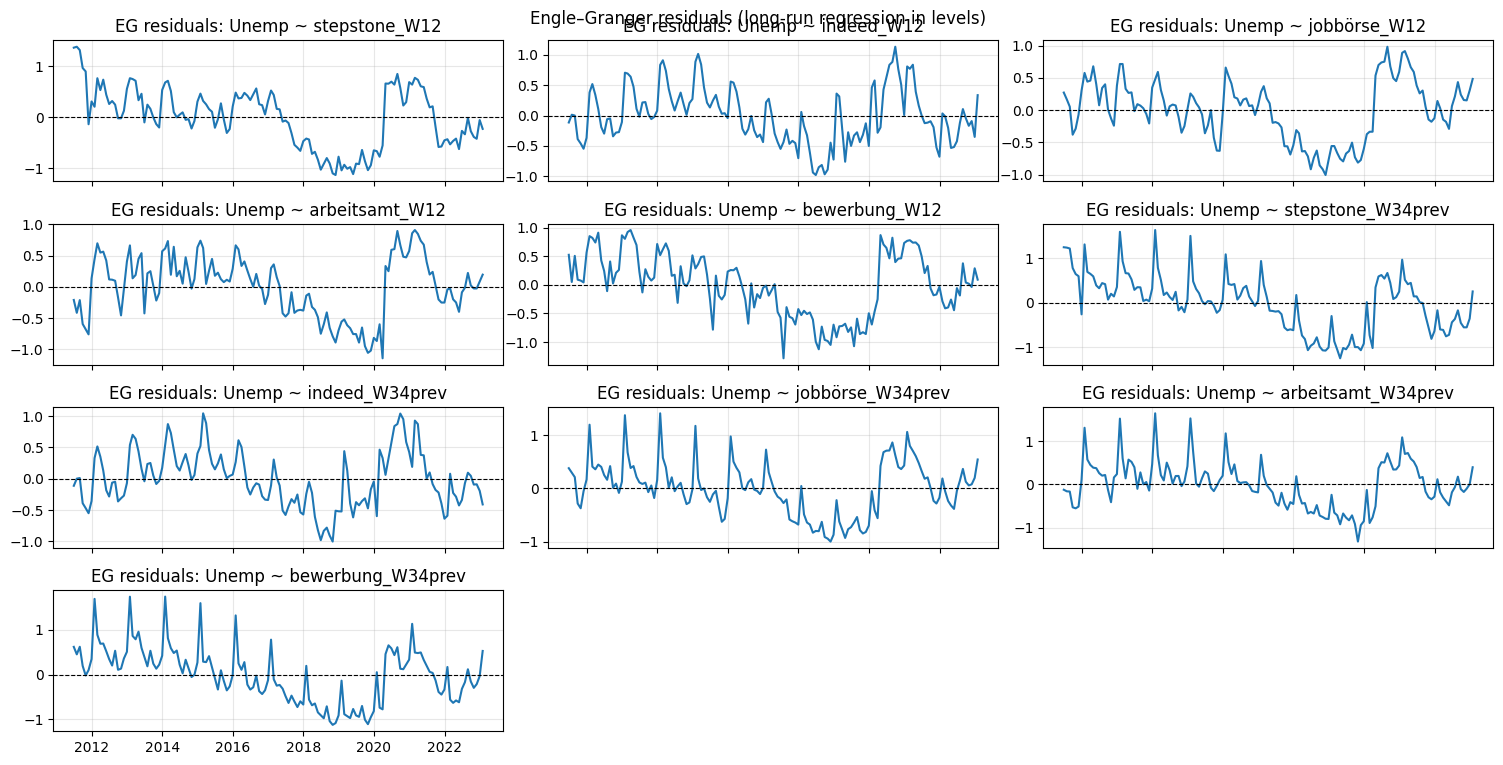

In [ ]:
def plot_eg_residuals(resid_dict, df_index, ncols=3, figsize=(15, 8)):
    """
    Plot Engle–Granger residuals for all series in resid_dict.
    resid_dict: {series_name: residual_series}
    df_index:   original DatetimeIndex (or take from one residual)
    """
    series_names = list(resid_dict.keys())
    n = len(series_names)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, series_names):
        r = resid_dict[name]
        # align index
        r = r.reindex(df_index).dropna()
        ax.plot(r.index, r.values)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"EG residuals: Unemp ~ {name}")
        ax.grid(True, alpha=0.3)

    # hide unused axes
    for ax in axes[len(series_names):]:
        ax.axis("off")

    fig.suptitle("Engle–Granger residuals (long-run regression in levels)", y=0.95)
    plt.tight_layout()
    plt.show()

# Call it
plot_eg_residuals(eg_residuals, df.index, ncols=3, figsize=(15, 8))


# Nowcasting using a ARX 
This is to include the newest information

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def arx_diff_nowcast(panel, gt_col,
                     start_eval="2019-01-01",
                     p_ar=2,        # AR lags of ΔUnemp
                     q_gt=0,        # number of lags of ΔGT (0 = only contemporaneous)
                     min_train=60,  # minimal obs in estimation window
                     plot=True,
                     show_summary=True):
    """
    Rolling pseudo-real-time nowcast with ARX in first differences:
    ΔUnemp_t ~ AR(p) in ΔUnemp + ΔGT_t (and lags) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead (nowcast current month t)
    - start_eval: first month (by date) for which you start evaluating nowcasts.
    """

    # 1) Keep only GT series and unemployment, convert to numeric
    df = panel[[gt_col, "Unemp"]].copy()
    df[gt_col] = pd.to_numeric(df[gt_col], errors="coerce")
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # 2) First differences
    df["dUnemp"] = df["Unemp"].diff()
    df["dGT"] = df[gt_col].diff()

    # 3) Precompute AR lags of ΔUnemp
    for i in range(1, p_ar + 1):
        df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # 4) Precompute ΔGT current and lags
    df["dGT_0"] = df["dGT"]  # contemporaneous ΔGT_t
    for j in range(1, q_gt + 1):
        df[f"dGT_lag{j}"] = df["dGT"].shift(j)

    # 5) Monthly dummies (Feb–Dec; Jan baseline)
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    # Regressor columns (AR lags + GT terms)
    reg_cols = [f"dUnemp_lag{i}" for i in range(1, p_ar + 1)] + ["dGT_0"] \
               + [f"dGT_lag{j}" for j in range(1, q_gt + 1)]

    forecasts = []
    actuals = []
    dates = []
    last_arx_res = None

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: everything BEFORE t
        df_est = df.loc[df.index < t].copy()
        # drop first row (diff NaN) and potential early NaNs from lags
        df_est = df_est.iloc[1:]

        # y = ΔUnemp
        y_est = df_est["dUnemp"]

        # X = AR lags of ΔUnemp + ΔGT terms + month dummies
        X_est = df_est[reg_cols]
        dummies_est = month_dummies.loc[df_est.index]

        X_est = pd.concat([X_est, dummies_est], axis=1)

        # Combine and drop rows with any NaN (from early lags)
        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if reg_data.empty:
            continue

        # Split again
        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        if len(y_reg) < max(min_train, p_ar + q_gt + 2):
            # Not enough data yet, skip this t
            continue

        # Add constant
        X_reg = sm.add_constant(X_reg)

        # 2) Fit ARX (OLS on first differences)
        arx_res = sm.OLS(y_reg, X_reg).fit()
        last_arx_res = arx_res

        # 3) Build regressor row for forecast month t
        #    We already have all lagged columns in df for date t
        x_t = df.loc[[t], reg_cols]
        dummies_t = month_dummies.loc[[t]]

        x_t = pd.concat([x_t, dummies_t], axis=1).astype(float)
        x_t = sm.add_constant(x_t, has_constant="add")

        # 4) Predict ΔUnemp_t
        pred_t = arx_res.predict(x_t)
        dU_pred = float(pred_t.iloc[0])

        # 5) Back to level forecast: U_t = U_{t-1} + ΔU_t
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_ARX")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nARX(Δ) nowcast for {gt_col}: RMSE={rmse:.4f}, MAE={mae:.4f}")

    if show_summary and last_arx_res is not None:
        print("\n=== Last ARX(Δ) estimation summary (with monthly dummies) ===")
        print(last_arx_res.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (ARX)", linestyle="--")
        plt.title(f"ARX(Δ) nowcast using {gt_col} with monthly dummies\n(start_eval={start_eval})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_arx_res



ARX(Δ) nowcast for stepstone_W12: RMSE=0.1846, MAE=0.1050

=== Last ARX(Δ) estimation summary (with monthly dummies) ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     29.32
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.73e-32
Time:                        11:40:32   Log-Likelihood:                 112.36
No. Observations:                 136   AIC:                            -194.7
Df Residuals:                     121   BIC:                            -151.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------

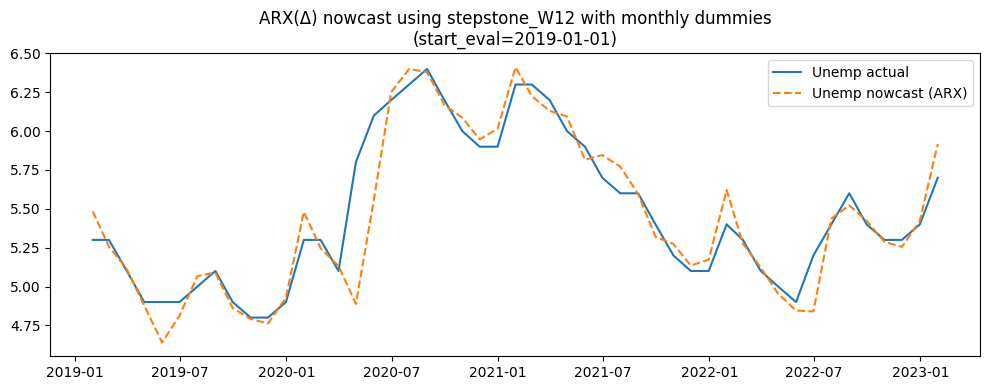

In [30]:
var_job_W12_forec, var_job_W12_act, rmse_job_W12, mae_job_W12, var_job_W12_model = \
    arx_diff_nowcast(panel,
                          gt_col="stepstone_W12",
                          start_eval="2019-01-01",
                          show_summary=True)

Lets look at some diagnostic


=== First 12 rows of evaluation ===
            Unemp_nowcast_ARX  Unemp_actual     error  abs_error  month
2019-01-31           5.483721           5.3  0.183721   0.183721      1
2019-02-28           5.257479           5.3 -0.042521   0.042521      2
2019-03-31           5.111306           5.1  0.011306   0.011306      3
2019-04-30           4.878401           4.9 -0.021599   0.021599      4
2019-05-31           4.639655           4.9 -0.260345   0.260345      5
2019-06-30           4.812168           4.9 -0.087832   0.087832      6
2019-07-31           5.067256           5.0  0.067256   0.067256      7
2019-08-31           5.089489           5.1 -0.010511   0.010511      8
2019-09-30           4.861946           4.9 -0.038054   0.038054      9
2019-10-31           4.790970           4.8 -0.009030   0.009030     10
2019-11-30           4.762125           4.8 -0.037875   0.037875     11
2019-12-31           4.926888           4.9  0.026888   0.026888     12

=== Worst 10 errors ===
  

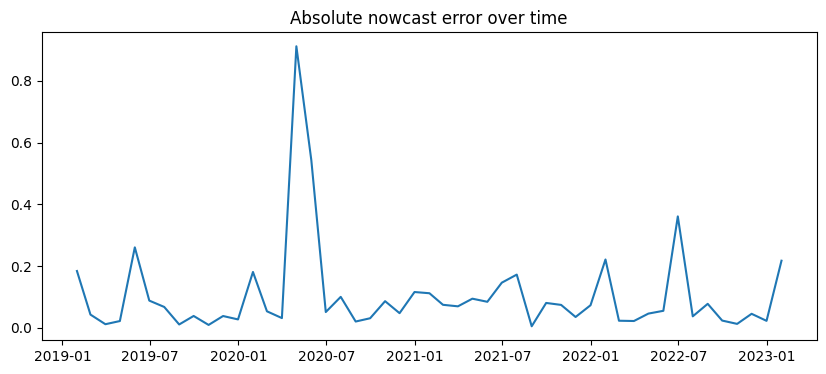


=== RMSE by month ===
month
1     0.186999
2     0.051610
3     0.039914
4     0.459073
5     0.305184
6     0.201027
7     0.106640
8     0.040369
9     0.048379
10    0.057204
11    0.041508
12    0.070514
Name: error, dtype: float64


In [31]:
# Combine actuals and forecasts
df_eval = pd.concat([var_job_W12_forec, var_job_W12_act], axis=1)
df_eval["error"] = df_eval["Unemp_nowcast_ARX"] - df_eval["Unemp_actual"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["month"] = df_eval.index.month

print("\n=== First 12 rows of evaluation ===")
print(df_eval.head(12))

print("\n=== Worst 10 errors ===")
print(df_eval.sort_values("abs_error", ascending=False).head(10))

# Plot absolute error
plt.figure(figsize=(10,4))
plt.plot(df_eval["abs_error"])
plt.title("Absolute nowcast error over time")
plt.show()

# RMSE by month (to see seasonal failure patterns)
rmse_by_month = df_eval.groupby("month")["error"].apply(lambda x: np.sqrt(np.mean(x**2)))
print("\n=== RMSE by month ===")
print(rmse_by_month)


## subsequent analysis 

In [32]:
import numpy as np
import pandas as pd



def evaluate_arx_for_keywords(panel, gt_cols,
                              start_eval="2019-01-01",
                              p_ar=1, q_gt=0,
                              min_train=60):
    """
    Runs arx_diff_nowcast for each gt_col in gt_cols and
    returns a summary DataFrame plus a dict of forecasts/actuals.
    """
    results = []
    forecasts_dict = {}

    for col in gt_cols:
        print(f"\n=== Running ARX for {col} ===")
        f, a, rmse, mae, _ = arx_diff_nowcast(
            panel,
            gt_col=col,
            start_eval=start_eval,
            p_ar=p_ar,
            q_gt=q_gt,
            min_train=min_train,
            plot=False,
            show_summary=False
        )

        # store results
        results.append({
            "gt_col": col,
            "rmse": rmse,
            "mae": mae,
            "rmse_improvement_%": 100 * (ar_rmse - rmse) / ar_rmse
        })

        # store forecasts & actuals for potential later use
        df_fa = pd.concat([f, a], axis=1)
        forecasts_dict[col] = df_fa

    results_df = pd.DataFrame(results).sort_values("rmse")
    return results_df, forecasts_dict


In [ ]:
gt_W12 = ["stepstone_W12", "indeed_W12", "arbeitsamt_W12", "jobbörse_W12", "bewerbung_W12"]
gt_W34 = ["stepstone_W34prev", "indeed_W34prev", "arbeitsamt_W34prev", "jobbörse_W34prev", "bewerbung_W34prev"]

results_W12, forecasts_W12 = evaluate_arx_for_keywords(panel, gt_W12)
results_W34, forecasts_W34 = evaluate_arx_for_keywords(panel, gt_W34)

print("\n=== ARX results for W12 ===")
print(results_W12)

print("\n=== ARX results for W34prev ===")
print(results_W34)



=== Running ARX for stepstone_W12 ===

ARX(Δ) nowcast for stepstone_W12: RMSE=0.1837, MAE=0.1044

=== Running ARX for indeed_W12 ===

ARX(Δ) nowcast for indeed_W12: RMSE=0.1861, MAE=0.1112

=== Running ARX for arbeitsamt_W12 ===

ARX(Δ) nowcast for arbeitsamt_W12: RMSE=0.1844, MAE=0.1047

=== Running ARX for jobbörse_W12 ===

ARX(Δ) nowcast for jobbörse_W12: RMSE=0.1802, MAE=0.1021

=== Running ARX for bewerbung_W12 ===

ARX(Δ) nowcast for bewerbung_W12: RMSE=0.1840, MAE=0.1039

=== Running ARX for stepstone_W34prev ===

ARX(Δ) nowcast for stepstone_W34prev: RMSE=0.1879, MAE=0.1066

=== Running ARX for indeed_W34prev ===

ARX(Δ) nowcast for indeed_W34prev: RMSE=0.1922, MAE=0.1117

=== Running ARX for arbeitsamt_W34prev ===

ARX(Δ) nowcast for arbeitsamt_W34prev: RMSE=0.1817, MAE=0.1062

=== Running ARX for jobbörse_W34prev ===

ARX(Δ) nowcast for jobbörse_W34prev: RMSE=0.1818, MAE=0.1035

=== Running ARX for bewerbung_W34prev ===

ARX(Δ) nowcast for bewerbung_W34prev: RMSE=0.1847, MAE

In [36]:
best_W12 = results_W12.iloc[0]["gt_col"]
best_W34 = results_W34.iloc[0]["gt_col"]
print("Best W12 keyword:", best_W12)
print("Best W34 keyword:", best_W34)

df_W12 = forecasts_W12[best_W12].copy()
df_W34 = forecasts_W34[best_W34].copy()


Best W12 keyword: jobbörse_W12
Best W34 keyword: arbeitsamt_W34prev



ARX(Δ) nowcast for jobbörse_W12: RMSE=0.1802, MAE=0.1021


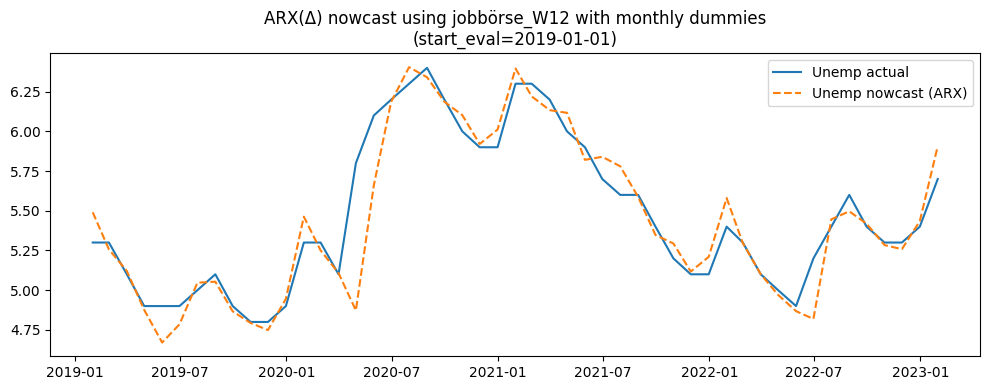


ARX(Δ) nowcast for arbeitsamt_W34prev: RMSE=0.1817, MAE=0.1062


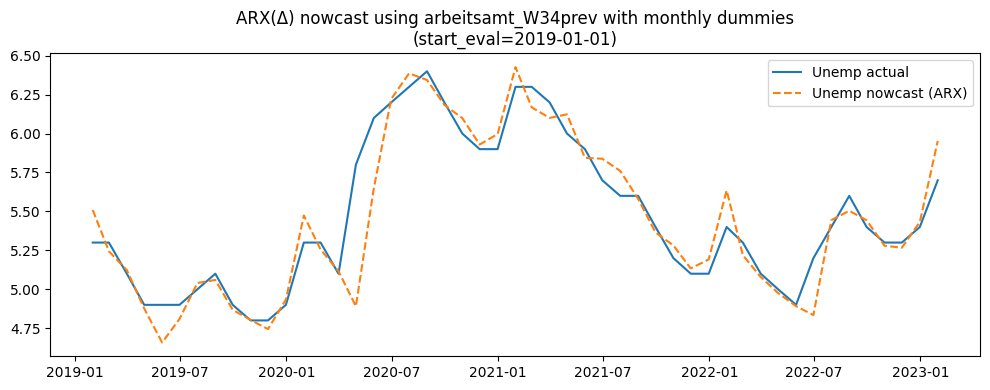

In [34]:
bestW12_forec, bestW12_act, bestW12_rmse, bestW12_mae, bestW12_model = arx_diff_nowcast(
    panel,
    gt_col=best_W12,
    start_eval="2019-01-01",
    p_ar=1, q_gt=0,
    min_train=60,
    plot=True,
    show_summary=False
)

bestW34_forec, bestW34_act, bestW34_rmse, bestW34_mae, bestW34_model = arx_diff_nowcast(
    panel,
    gt_col=best_W34,
    start_eval="2019-01-01",
    p_ar=1, q_gt=0,
    min_train=60,
    plot=True,
    show_summary=False
)


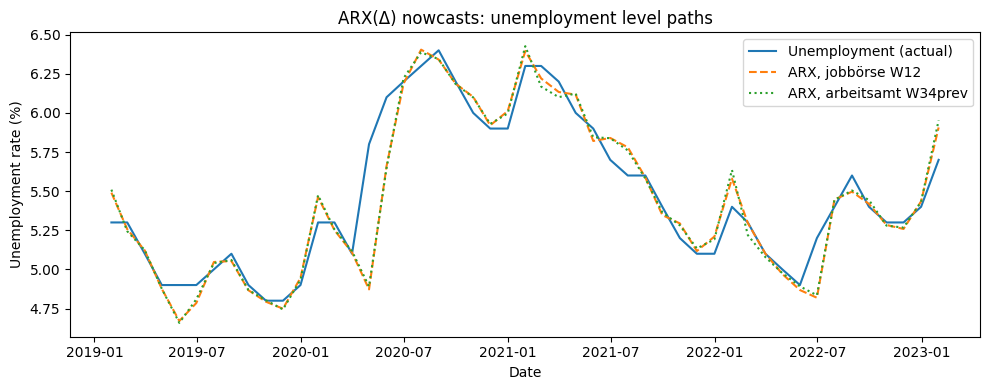

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine series into one DataFrame
df_levels = pd.concat(
    [
        bestW12_act.rename("Unemp_actual"),
        bestW12_forec.rename("Unemp_ARX_W12"),
        bestW34_forec.rename("Unemp_ARX_W34prev"),
    ],
    axis=1
)

plt.figure(figsize=(10, 4))
plt.plot(df_levels.index, df_levels["Unemp_actual"], label="Unemployment (actual)")
plt.plot(df_levels.index, df_levels["Unemp_ARX_W12"], label="ARX, jobbörse W12", linestyle="--")
plt.plot(df_levels.index, df_levels["Unemp_ARX_W34prev"], label="ARX, arbeitsamt W34prev", linestyle=":")
plt.title("ARX(Δ) nowcasts: unemployment level paths")
plt.xlabel("Date")
plt.ylabel("Unemployment rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


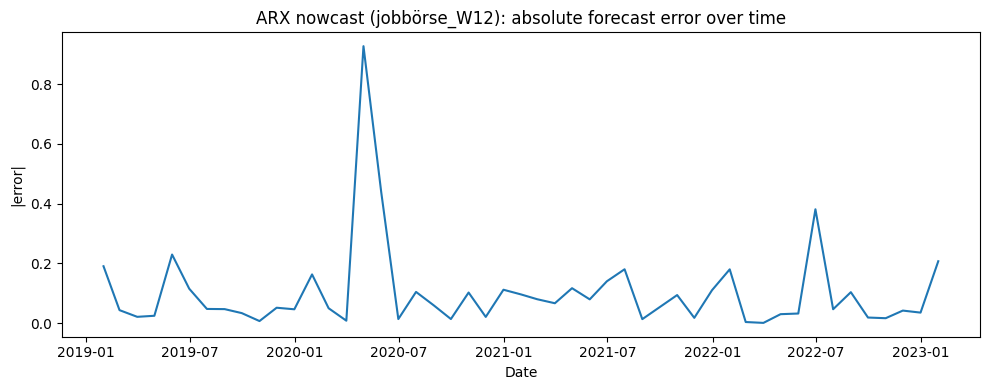

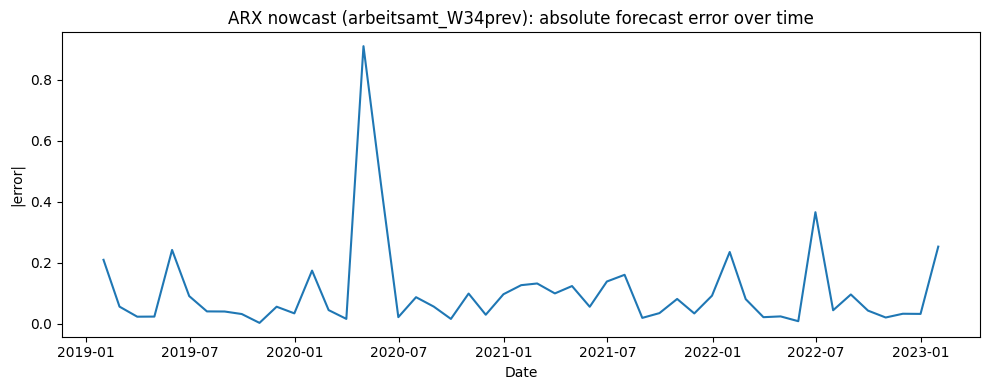

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# ---- W12 ----
df_W12["error"] = df_W12["Unemp_nowcast_ARX"] - df_W12["Unemp_actual"]
df_W12["abs_error"] = df_W12["error"].abs()

plt.figure(figsize=(10,4))
plt.plot(df_W12.index, df_W12["abs_error"])
plt.title(f"ARX nowcast ({best_W12}): absolute forecast error over time")
plt.ylabel("|error|")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# ---- W34 ----
df_W34["error"] = df_W34["Unemp_nowcast_ARX"] - df_W34["Unemp_actual"]
df_W34["abs_error"] = df_W34["error"].abs()

plt.figure(figsize=(10,4))
plt.plot(df_W34.index, df_W34["abs_error"])
plt.title(f"ARX nowcast ({best_W34}): absolute forecast error over time")
plt.ylabel("|error|")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


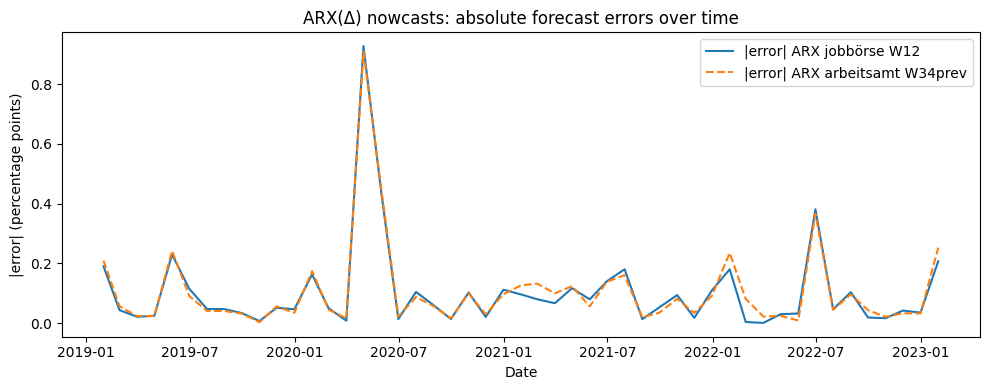

In [41]:
# Compute errors
err_W12 = (bestW12_forec - bestW12_act).rename("abs_error_W12")
err_W34 = (bestW34_forec - bestW34_act).rename("abs_error_W34")

plt.figure(figsize=(10, 4))
plt.plot(err_W12.index, err_W12.abs(), label="|error| ARX jobbörse W12")
plt.plot(err_W34.index, err_W34.abs(), label="|error| ARX arbeitsamt W34prev", linestyle="--")
plt.title("ARX(Δ) nowcasts: absolute forecast errors over time")
plt.xlabel("Date")
plt.ylabel("|error| (percentage points)")
plt.legend()
plt.tight_layout()
plt.show()



RMSE by month for jobbörse_W12
month
1     0.171548
2     0.051698
3     0.034954
4     0.467914
5     0.251506
6     0.211082
7     0.109180
8     0.064300
9     0.033162
10    0.069866
11    0.035663
12    0.083480
Name: error, dtype: float64


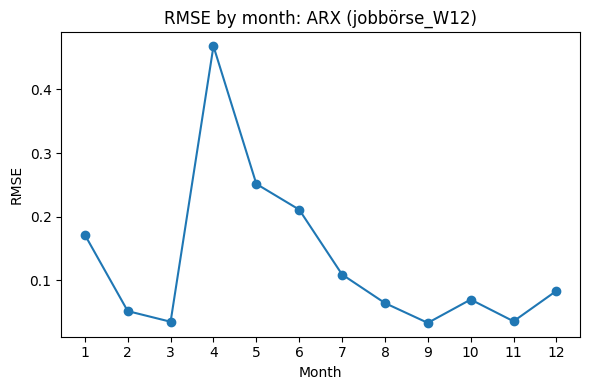


RMSE by month for arbeitsamt_W34prev
month
1     0.204594
2     0.085244
3     0.052751
4     0.459204
5     0.257546
6     0.200848
7     0.096026
8     0.059865
9     0.032910
10    0.064860
11    0.039398
12    0.070749
Name: error, dtype: float64


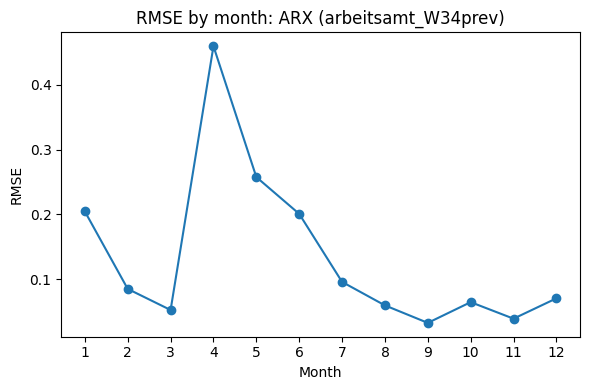

In [38]:
# ---- W12 ----
df_W12["month"] = df_W12.index.month
rmse_by_month_W12 = df_W12.groupby("month")["error"].apply(
    lambda e: np.sqrt(np.mean(e**2))
)
print("\nRMSE by month for", best_W12)
print(rmse_by_month_W12)

plt.figure(figsize=(6,4))
plt.plot(rmse_by_month_W12.index, rmse_by_month_W12.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title(f"RMSE by month: ARX ({best_W12})")
plt.tight_setup = plt.tight_layout()
plt.show()

# ---- W34 ----
df_W34["month"] = df_W34.index.month
rmse_by_month_W34 = df_W34.groupby("month")["error"].apply(
    lambda e: np.sqrt(np.mean(e**2))
)
print("\nRMSE by month for", best_W34)
print(rmse_by_month_W34)

plt.figure(figsize=(6,4))
plt.plot(rmse_by_month_W34.index, rmse_by_month_W34.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title(f"RMSE by month: ARX ({best_W34})")
plt.tight_layout()
plt.show()


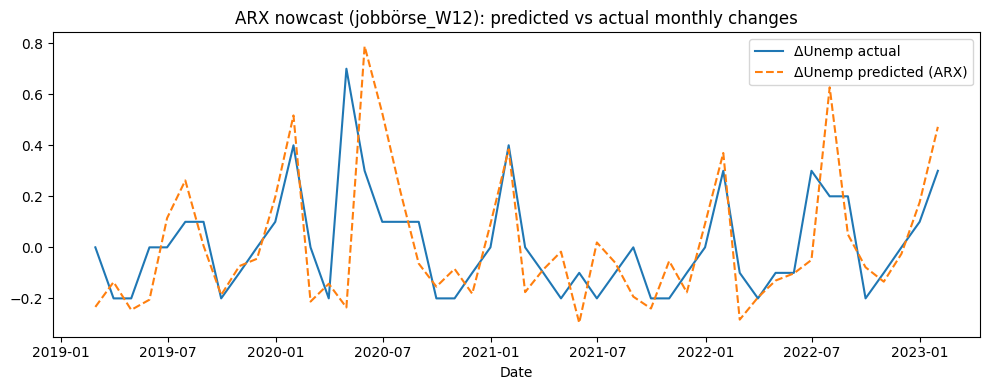

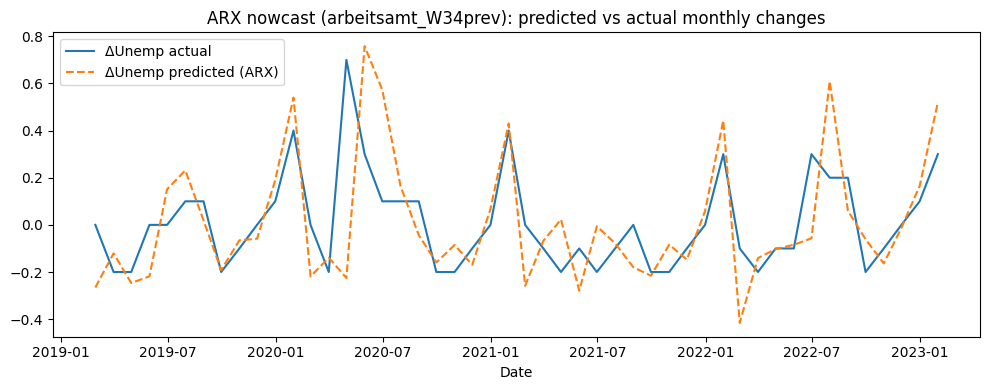

In [39]:
# ---- W12 ----
dU_act_W12  = df_W12["Unemp_actual"].diff().rename("dUnemp_actual")
dU_pred_W12 = df_W12["Unemp_nowcast_ARX"].diff().rename("dUnemp_pred")

df_dU_W12 = pd.concat([dU_act_W12, dU_pred_W12], axis=1).dropna()

plt.figure(figsize=(10,4))
plt.plot(df_dU_W12.index, df_dU_W12["dUnemp_actual"], label="ΔUnemp actual")
plt.plot(df_dU_W12.index, df_dU_W12["dUnemp_pred"],  label="ΔUnemp predicted (ARX)", linestyle="--")
plt.title(f"ARX nowcast ({best_W12}): predicted vs actual monthly changes")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

# ---- W34 ----
dU_act_W34  = df_W34["Unemp_actual"].diff().rename("dUnemp_actual")
dU_pred_W34 = df_W34["Unemp_nowcast_ARX"].diff().rename("dUnemp_pred")

df_dU_W34 = pd.concat([dU_act_W34, dU_pred_W34], axis=1).dropna()

plt.figure(figsize=(10,4))
plt.plot(df_dU_W34.index, df_dU_W34["dUnemp_actual"], label="ΔUnemp actual")
plt.plot(df_dU_W34.index, df_dU_W34["dUnemp_pred"],  label="ΔUnemp predicted (ARX)", linestyle="--")
plt.title(f"ARX nowcast ({best_W34}): predicted vs actual monthly changes")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


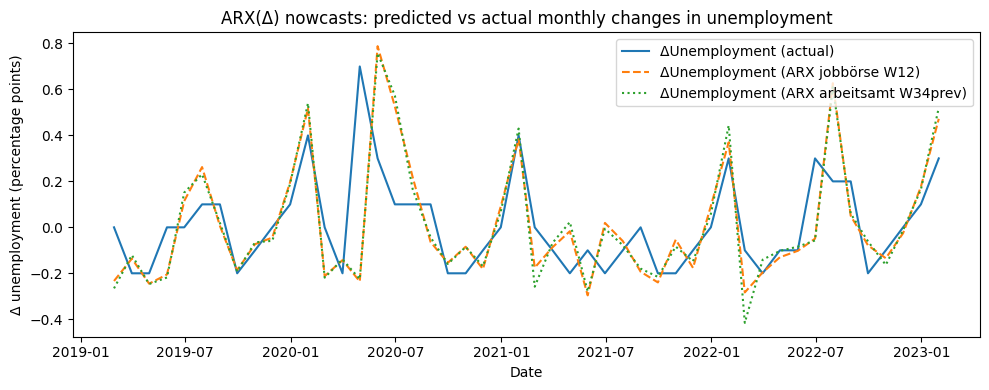

In [42]:
# ΔU_t for actual and the two ARX models
dU_act  = bestW12_act.diff().rename("dUnemp_actual")     # same as bestW34_act.diff()
dU_W12  = bestW12_forec.diff().rename("dUnemp_ARX_W12")
dU_W34  = bestW34_forec.diff().rename("dUnemp_ARX_W34prev")

df_du = pd.concat([dU_act, dU_W12, dU_W34], axis=1).dropna()

plt.figure(figsize=(10, 4))
plt.plot(df_du.index, df_du["dUnemp_actual"], label="ΔUnemployment (actual)")
plt.plot(df_du.index, df_du["dUnemp_ARX_W12"], label="ΔUnemployment (ARX jobbörse W12)", linestyle="--")
plt.plot(df_du.index, df_du["dUnemp_ARX_W34prev"],
         label="ΔUnemployment (ARX arbeitsamt W34prev)", linestyle=":")
plt.title("ARX(Δ) nowcasts: predicted vs actual monthly changes in unemployment")
plt.xlabel("Date")
plt.ylabel("Δ unemployment (percentage points)")
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
def compare_early_late(results_W12, results_W34):
    rows = []
    # extract base names by stripping suffixes
    def base(name, suffix):
        return name.replace(suffix, "")
    
    for idx, row in results_W12.iterrows():
        col12 = row["gt_col"]
        base_name = base(col12, "_W12")
        # find corresponding W34 row
        mask = results_W34["gt_col"].str.startswith(base_name)
        if mask.any():
            row34 = results_W34[mask].iloc[0]
            rows.append({
                "keyword": base_name,
                "rmse_W12": row["rmse"],
                "rmse_W34": row34["rmse"],
                "better_window": "W12" if row["rmse"] < row34["rmse"] else "W34prev"
            })
    return pd.DataFrame(rows)

early_late_comp = compare_early_late(results_W12, results_W34)
print("\n=== Early vs late biweekly comparison ===")
print(early_late_comp)



=== Early vs late biweekly comparison ===
      keyword  rmse_W12  rmse_W34 better_window
0    jobbörse  0.180184  0.181839           W12
1   stepstone  0.183697  0.187925           W12
2   bewerbung  0.183999  0.184673           W12
3  arbeitsamt  0.184427  0.181729       W34prev
4      indeed  0.186145  0.192173           W12


In [28]:
# Example: average the three best W12 nowcasts
top3 = results_W12.head(3)["gt_col"].tolist()
df_comb = pd.concat([forecasts_W12[c]["Unemp_nowcast_ARX"] for c in top3], axis=1)
comb_forec = df_comb.mean(axis=1).rename("Unemp_nowcast_ARX_combined")

comb_act = forecasts_W12[top3[0]]["Unemp_actual"]  # same actuals

comb_errors = comb_forec - comb_act
comb_rmse = np.sqrt(np.mean(comb_errors**2))
comb_mae = np.mean(np.abs(comb_errors))

print("\nCombined W12 forecast: RMSE=", comb_rmse, "MAE=", comb_mae)



Combined W12 forecast: RMSE= 0.18236764925151347 MAE= 0.10333975304882148


# AR(1) Nowcast

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def ar_diff_nowcast(panel,
                    start_eval="2019-01-01",
                    p_ar=2,        # AR lags of ΔUnemp
                    min_train=60,
                    plot=True,
                    show_summary=True):
    """
    Rolling pseudo-real-time nowcast with AR model in first differences:
    ΔUnemp_t ~ AR(p) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead
    """

    df = panel[["Unemp"]].copy()
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # first differences
    df["dUnemp"] = df["Unemp"].diff()

    order = arma_order_select_ic(df["dUnemp"].dropna(), max_ar=4, ic='bic')
    print(order.bic_min_order)

    # AR lags
    for i in range(1, p_ar + 1):
        df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # monthly dummies
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    reg_cols = [f"dUnemp_lag{i}" for i in range(1, p_ar + 1)]

    forecasts, actuals, dates = [], [], []
    last_model = None

    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        df_est = df.loc[df.index < t].copy().iloc[1:]  # drop first diff NaN

        y_est = df_est["dUnemp"]
        X_est = df_est[reg_cols]

        dummies_est = month_dummies.loc[df_est.index]
        X_est = pd.concat([X_est, dummies_est], axis=1)

        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if len(reg_data) < max(min_train, p_ar + 2):
            continue

        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        X_reg = sm.add_constant(X_reg)

        model = sm.OLS(y_reg, X_reg).fit()
        last_model = model

        # Build forecast row
        x_t = df.loc[[t], reg_cols]
        dummies_t = month_dummies.loc[[t]]

        x_t = pd.concat([x_t, dummies_t], axis=1).astype(float)
        x_t = sm.add_constant(x_t, has_constant="add")

        # predict ΔUnemp_t
        dU_pred = float(model.predict(x_t))

        # level forecast
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_AR")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nAR(Δ) nowcast results: RMSE={rmse:.4f}, MAE={mae:.4f}")

    if show_summary and last_model is not None:
        print("\n=== Last AR(Δ) model summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Actual")
        plt.plot(forecasts, label="Forecast (AR)", linestyle="--")
        plt.title(f"AR(Δ) Nowcast (start_eval={start_eval})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model


(2, 2)

AR(Δ) nowcast results: RMSE=0.1817, MAE=0.1032


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/1855617994.py:74: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/1855617994.py:74: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/1855617994.py:74: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  dU_pred = float(model.predict(x_t))
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_10324/1855617994.py:74: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser

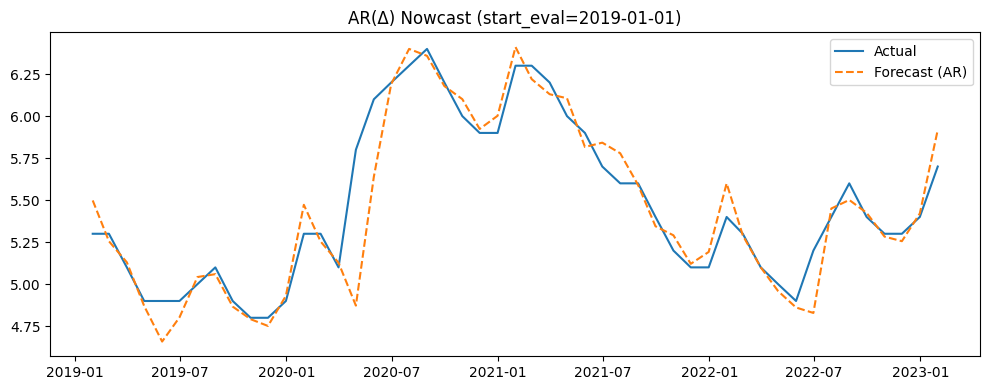

In [15]:
ar_forec, ar_act, ar_rmse, ar_mae, ar_model = ar_diff_nowcast(
    panel, p_ar=1, plot=True, show_summary=False
)


# Absolute error over time

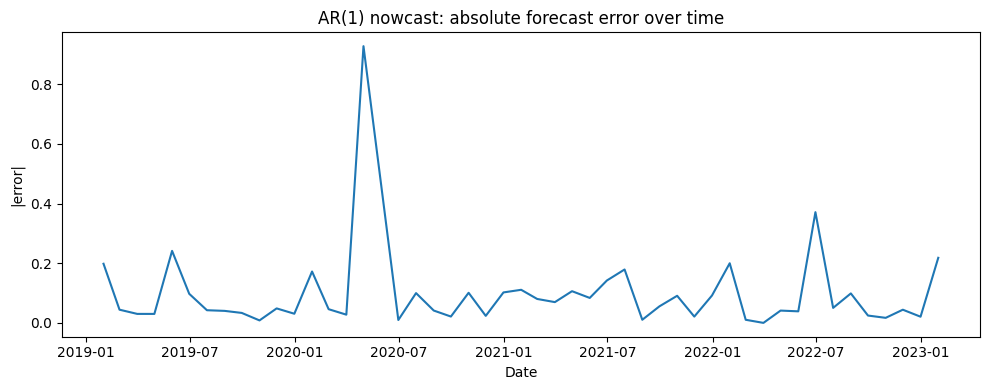

In [16]:
# Combine actuals and forecasts
df_ar = pd.concat([ar_forec, ar_act], axis=1)

# Error and absolute error
df_ar["error"] = df_ar["Unemp_nowcast_AR"] - df_ar["Unemp_actual"]
df_ar["abs_error"] = df_ar["error"].abs()

# Plot absolute error
plt.figure(figsize=(10, 4))
plt.plot(df_ar.index, df_ar["abs_error"])
plt.title("AR(1) nowcast: absolute forecast error over time")
plt.ylabel("|error|")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


# RMSE by month

RMSE by calendar month:
month
1     0.183761
2     0.051524
3     0.040380
4     0.467507
5     0.264511
6     0.204703
7     0.107674
8     0.057461
9     0.036258
10    0.068569
11    0.036457
12    0.071153
Name: error, dtype: float64


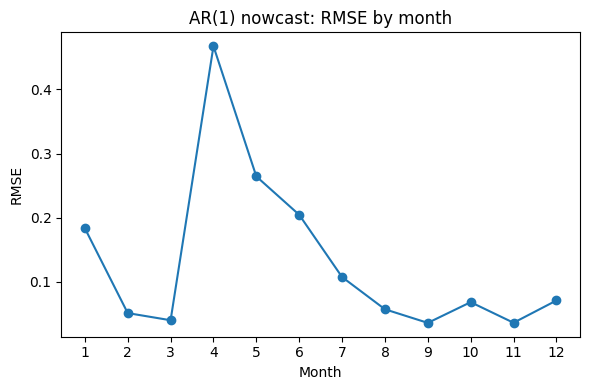

In [17]:
# Month number (1=Jan, ..., 12=Dec)
df_ar["month"] = df_ar.index.month

rmse_by_month = df_ar.groupby("month")["error"].apply(
    lambda e: np.sqrt(np.mean(e**2))
)

print("RMSE by calendar month:")
print(rmse_by_month)

# Optional: plot
plt.figure(figsize=(6,4))
plt.plot(rmse_by_month.index, rmse_by_month.values, marker="o")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.title("AR(1) nowcast: RMSE by month")
plt.tight_layout()
plt.show()


# Predicted vs actual change 

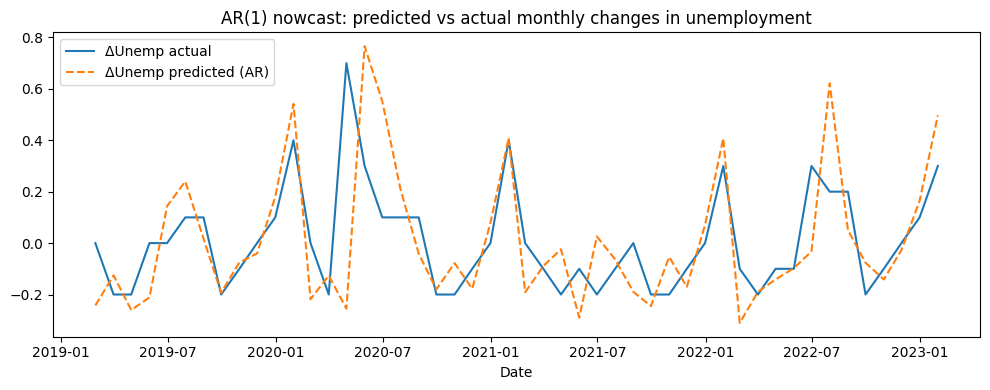

In [18]:
# Changes in actual and forecast unemployment
dU_act = ar_act.diff().rename("dUnemp_actual")
dU_pred = ar_forec.diff().rename("dUnemp_pred")

df_dU = pd.concat([dU_act, dU_pred], axis=1).dropna()

# Time-series plot
plt.figure(figsize=(10,4))
plt.plot(df_dU.index, df_dU["dUnemp_actual"], label="ΔUnemp actual")
plt.plot(df_dU.index, df_dU["dUnemp_pred"],  label="ΔUnemp predicted (AR)", linestyle="--")
plt.title("AR(1) nowcast: predicted vs actual monthly changes in unemployment")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


# Forecast vs actual levels

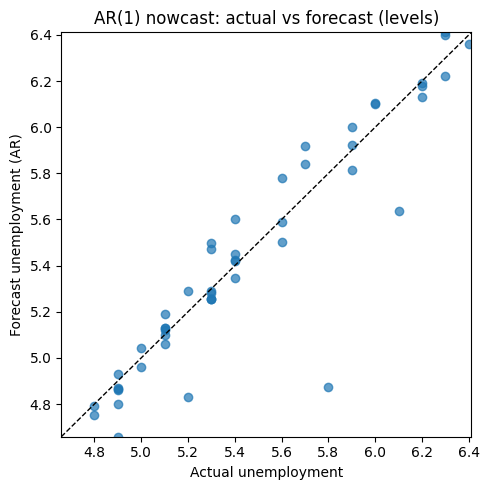

In [19]:
# Align and drop missing values
df_scatter = pd.concat([ar_act, ar_forec], axis=1).dropna()

plt.figure(figsize=(5,5))
plt.scatter(df_scatter["Unemp_actual"], df_scatter["Unemp_nowcast_AR"], alpha=0.7)
# 45-degree line
lims = [
    min(df_scatter["Unemp_actual"].min(), df_scatter["Unemp_nowcast_AR"].min()),
    max(df_scatter["Unemp_actual"].max(), df_scatter["Unemp_nowcast_AR"].max()),
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual unemployment")
plt.ylabel("Forecast unemployment (AR)")
plt.title("AR(1) nowcast: actual vs forecast (levels)")
plt.tight_layout()
plt.show()


## ARMA model

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def armax_diff_nowcast(panel,
                       gt_col,
                       start_eval="2019-01-01",
                       p_max=2,      # max AR order to try
                       q_max=2,      # max MA order to try
                       K_gt=0,       # number of lags of ΔGT (0 = only contemporaneous)
                       min_train=60, # minimal obs in estimation window
                       ic="aic",     # "aic" or "bic"
                       plot=True,
                       show_summary=True):
    """
    Rolling pseudo-real-time nowcast with ARMAX in first differences:

    ΔUnemp_t ~ ARMA(p,q) + ΔGT_t (and lags up to K_gt) + monthly dummies.

    - Training sample for each forecast date t: all data with Date < t
    - Forecast horizon: 1 month ahead (nowcast current month t)
    - (p,q) chosen in small grid by AIC/BIC each time.

    Parameters
    ----------
    panel : DataFrame
        Must contain columns [gt_col, "Unemp"] and a DateTimeIndex.
    gt_col : str
        Column name of the Google Trends series to use.
    start_eval : str or Timestamp
        First date (inclusive) for which to start nowcasting.
    p_max, q_max : int
        Max AR and MA orders to consider in the (p,q) grid.
    K_gt : int
        Number of lags of ΔGT to include (0 = only ΔGT_t; 1 = ΔGT_t, ΔGT_{t-1}, ...).
    min_train : int
        Minimum number of usable observations required to estimate ARMAX.
    ic : {"aic","bic"}
        Information criterion used to select (p,q).
    """

    # 1) Keep only GT series and unemployment, convert to numeric
    df = panel[[gt_col, "Unemp"]].copy()
    df[gt_col] = pd.to_numeric(df[gt_col], errors="coerce")
    df["Unemp"] = pd.to_numeric(df["Unemp"], errors="coerce")

    # 2) First differences
    df["dUnemp"] = df["Unemp"].diff()
    df["dGT"] = df[gt_col].diff()

    # 3) Build ΔGT lags (including contemporaneous as lag 0)
    df["dGT_0"] = df["dGT"]  # contemporaneous ΔGT_t
    for k in range(1, K_gt + 1):
        df[f"dGT_lag{k}"] = df["dGT"].shift(k)

    # 4) Monthly dummies (Feb–Dec; Jan baseline)
    month_dummies = pd.get_dummies(df.index.month, prefix="m", drop_first=True)
    month_dummies.index = df.index

    # list of GT regressor columns
    gt_cols = ["dGT_0"] + [f"dGT_lag{k}" for k in range(1, K_gt + 1)]

    forecasts = []
    actuals = []
    dates = []
    last_model = None
    last_order = None
    order_history = {}  # store (p,q) per forecast date

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: everything BEFORE t
        df_est = df.loc[df.index < t].copy()

        # drop first row (diff NaN) and potential early NaNs from lags
        df_est = df_est.iloc[1:]

        # y = ΔUnemp
        y_est = df_est["dUnemp"]

        # X = ΔGT terms + month dummies
        X_gt = df_est[gt_cols]
        dummies_est = month_dummies.loc[df_est.index]
        X_est = pd.concat([X_gt, dummies_est], axis=1)

        # Combine and drop rows with any NaN (from early lags)
        reg_data = pd.concat([y_est, X_est], axis=1).dropna()

        if len(reg_data) < min_train:
            # Not enough data yet, skip this t
            continue

        y_reg = reg_data["dUnemp"].astype(float)
        X_reg = reg_data.drop(columns=["dUnemp"]).astype(float)

        # 2) Select (p,q) by IC on a small grid
        best_ic = np.inf
        best_order = None
        best_res = None

        for p in range(0, p_max + 1):
            for q in range(0, q_max + 1):
                if p == 0 and q == 0:
                    # ARMA(0,0) is just white noise + exog; you can allow it if you want
                    continue
                try:
                    # d=0 because we already difference y_reg
                    model = sm.tsa.ARIMA(
                        y_reg,
                        order=(p, 0, q),
                        exog=X_reg
                    )
                    res = model.fit(method="statespace", disp=0)

                    value_ic = res.aic if ic.lower() == "aic" else res.bic
                    if value_ic < best_ic:
                        best_ic = value_ic
                        best_order = (p, q)
                        best_res = res
                except Exception:
                    # occasionally ARIMA fails to converge; just skip that order
                    continue

        if best_res is None:
            print(f"WARNING: No ARMAX model converged for forecast date {t}. Skipping.")
            continue

        armax_res = best_res
        last_model = armax_res
        last_order = best_order
        order_history[t] = best_order

        # 3) Build exogenous regressor row for forecast month t
        X_gt_t = df.loc[[t], gt_cols]
        dummies_t = month_dummies.loc[[t]]
        X_t = pd.concat([X_gt_t, dummies_t], axis=1).astype(float)

        # 4) One-step-ahead forecast of ΔUnemp_t
        dU_pred = float(armax_res.forecast(steps=1, exog=X_t))

        # 5) Back to level forecast: U_t = U_{t-1} + ΔU_t
        U_last = df.loc[df.index < t, "Unemp"].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(df.loc[t, "Unemp"])
        dates.append(t)

    # Build series of forecasts and actuals
    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_ARMAX")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nARMAX(Δ) nowcast for {gt_col}: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if last_order is not None:
        print(f"Last selected ARMA order (p,q) = {last_order}")

    if show_summary and last_model is not None:
        print("\n=== Last ARMAX(Δ) estimation summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (ARMAX)", linestyle="--")
        plt.title(
            f"ARMAX(Δ) nowcast using {gt_col} with monthly dummies\n"
            f"(start_eval={start_eval}, p_max={p_max}, q_max={q_max}, K_gt={K_gt})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model, order_history



ARMAX(Δ) nowcast for stepstone_W12: RMSE=nan, MAE=nan


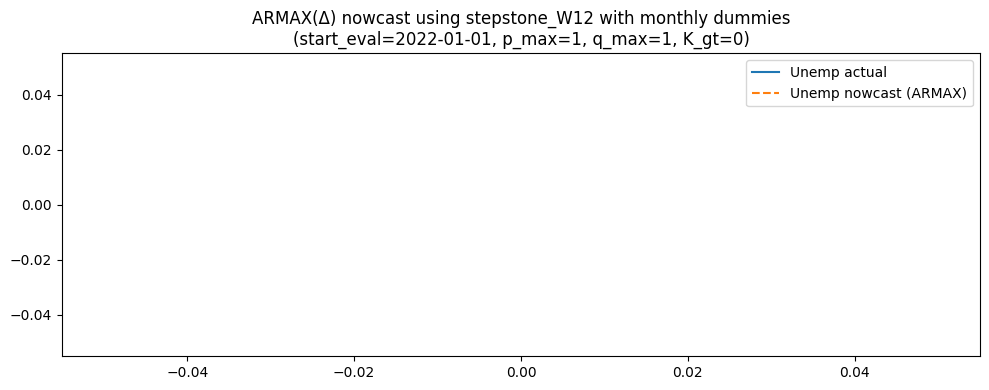

In [ ]:
armax_forec, armax_act, rmse_armax, mae_armax, armax_model, armax_orders = \
    armax_diff_nowcast(
        panel,
        gt_col="stepstone_W12",
        start_eval="2022-01-01",
        p_max=1,
        q_max=1,
        K_gt=0,        # only contemporaneous ΔGT_t
        ic="aic",
        show_summary=True
    )


It does not necessarily mean GT is “wrong” or “has no signal” — but:

It means ΔGT_t has no statistical power in explaining ΔUnemp_t

in the likelihood-based ARMAX estimation framework.

In other words:

GT does not move with unemployment month-to-month in changes

The correlation is extremely low

GT does not help estimate an ARMA structure

That’s why ARMA+X fails but ARX (OLS) still works (and you already saw that with ARX).

OLS finds a coefficient even if β is nearly zero.

ARMA (maximum likelihood) needs a proper error structure — you don’t have one.

# Transformation we need for Midas

In [48]:
# Weekly GT → convert to period number within each month
df_week["month"] = df_week["Date"].dt.to_period("M")
df_week["week_in_month"] = df_week.groupby("month").cumcount()

# Typically there are 4–5 weeks per month
print(df_week["week_in_month"].max())

4


In [49]:
weekly_panel = (df_week
                .set_index("Date")
                [["indeed", "stepstone", "jobbörse", "arbeitsamt", "bewerbung"]]
               )


In [50]:
weekly_panel

,indeed,stepstone,jobbörse,arbeitsamt,bewerbung
Date,,,,,
2011-05-01,14.000000,49.000000,75.000000,86.000000,63.000000
2011-05-08,14.000000,50.000000,80.000000,84.000000,68.000000
2011-05-15,14.000000,52.000000,80.000000,87.000000,73.000000
2011-05-22,15.000000,52.000000,80.000000,83.000000,73.000000
2011-05-29,13.000000,42.000000,69.000000,73.000000,60.000000
...,...,...,...,...,...
2023-01-01,128.215336,60.670120,16.313392,26.270023,42.207649
2023-01-08,139.364496,58.450482,18.712420,30.773455,48.907276
2023-01-15,133.789916,65.109398,17.752809,30.773455,49.577239


In [51]:
import pandas as pd
import numpy as np

# --- 0. Ensure indices are proper DatetimeIndex ---
weekly = weekly_panel.copy()
monthly = unemp.copy()

weekly.index = pd.to_datetime(weekly.index)
monthly.index = pd.to_datetime(monthly.index)

# Optional: sort indices
weekly = weekly.sort_index()
monthly = monthly.sort_index()

# --- 1. First differences (stationarity) ---

# Monthly unemployment differences
monthly['dUnemp'] = monthly['Unemp'].diff()

# Weekly GT differences for one variable, say 'indeed'
weekly['indeed_diff'] = weekly['indeed'].diff()

# Drop first NA differences
monthly = monthly.dropna(subset=['dUnemp'])
weekly = weekly.dropna(subset=['indeed_diff'])

# --- 2. Choose number of weekly lags for MIDAS ---
K = 8  # e.g. 8 weekly lags

# --- 3. Build MIDAS-style dataset: one row per month, with K weekly lags ---

rows = []

for month_date, row in monthly.iterrows():
    # y_t: monthly change in unemployment at this month
    y = row['dUnemp']
    
    # all weekly observations up to this month_date
    weekly_up_to_month = weekly.loc[weekly.index <= month_date]
    
    # take the last K weekly differences (the "lags")
    if len(weekly_up_to_month) < K:
        # not enough history yet, skip this month
        continue
    
    last_K = weekly_up_to_month['indeed_diff'].iloc[-K:]
    
    # last_K is ordered from oldest to newest within that K-window
    # we want lag1 = most recent, so reverse
    lags = last_K.iloc[::-1].values  # now lags[0] = most recent week
    
    # store row: Date, dUnemp, lags...
    rows.append([month_date, y] + list(lags))

# Create DataFrame
colnames = ['Date', 'dUnemp'] + [f'lag{i+1}' for i in range(K)]
midas_df = pd.DataFrame(rows, columns=colnames).set_index('Date')

# --- 4. Add monthly seasonal dummies (since Unemp is NOT seasonally adjusted) ---

midas_df['month'] = midas_df.index.month
midas_df = pd.get_dummies(midas_df, columns=['month'], drop_first=True)


In [ ]:
midas_df

,dUnemp,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
Date,,,,,,,,,,,,,,,,,,,,
2011-06-30,-0.1,0.000000,2.000000,-3.000000,3.000000,-2.000000,1.000000,0.000000,0.000000,False,False,False,False,True,False,False,False,False,False,False
2011-07-31,0.1,1.000000,-1.000000,-1.000000,1.000000,1.000000,0.000000,2.000000,-3.000000,False,False,False,False,False,True,False,False,False,False,False
2011-08-31,0.0,1.000000,-1.000000,1.000000,-1.000000,1.000000,-1.000000,-1.000000,1.000000,False,False,False,False,False,False,True,False,False,False,False
2011-09-30,-0.4,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,1.000000,-1.000000,False,False,False,False,False,False,False,True,False,False,False
2011-10-31,-0.1,0.000000,-1.000000,1.000000,-1.000000,2.000000,0.000000,0.000000,1.000000,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-09-30,-0.2,-1.858193,0.000000,0.000000,-5.574580,7.432773,0.000000,3.716387,1.858193,False,False,False,False,False,False,False,True,False,False,False
2022-10-31,-0.1,1.858193,-7.432773,0.000000,11.149160,-5.574580,-1.858193,0.000000,0.000000,False,False,False,False,False,False,False,False,True,False,False
2022-11-30,0.0,3.716387,-22.298319,3.716387,3.716387,1.858193,-7.432773,0.000000,11.149160,False,False,False,False,False,False,False,False,False,True,False


# Unrestricted MIDAS function

In [62]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

def midas_unrestricted_nowcast(
    midas_df,
    unemp,
    start_eval="2019-01-01",
    p_ar=0,         # AR lags of dUnemp to include in MIDAS (0 = no AR term)
    min_train=60,   # minimal number of usable obs in estimation window
    plot=True,
    show_summary=True
):
    """
    Rolling pseudo-real-time nowcast with unrestricted MIDAS:

    ΔUnemp_t = α + Σ φ_i ΔUnemp_{t-i} + Σ β_w ΔGT_{t,w} + seasonal dummies + ε_t

    where ΔGT_{t,w} are the weekly differences stacked as lag1..lagK.

    Parameters
    ----------
    midas_df : DataFrame
        Monthly MIDAS design matrix with:
          - column 'dUnemp' (monthly change in unemployment),
          - columns 'lag1'...'lagK' (weekly GT differences),
          - monthly dummy columns (e.g. 'month_2', ..., 'month_12').
        Index must be a DateTimeIndex of month-end dates.

    unemp : DataFrame or Series
        Monthly unemployment levels ('Unemp') with DateTimeIndex.
        Used to reconstruct level forecasts: U_t = U_{t-1} + ΔU_t_hat.

    start_eval : str or Timestamp
        First month (by date) to start evaluating nowcasts.

    p_ar : int
        Number of AR lags of ΔUnemp to include (0 = none, 1 = ΔUnemp_{t-1}, etc).

    min_train : int
        Minimum number of usable obs required in the estimation window.

    plot : bool
        Plot actual vs nowcasted unemployment levels.

    show_summary : bool
        Print OLS summary of the last estimated MIDAS regression.

    Returns
    -------
    forecasts : Series
        Nowcasted unemployment levels (U_hat_t).

    actuals : Series
        Actual unemployment levels (U_t).

    rmse : float
        Root mean squared error of level nowcasts.

    mae : float
        Mean absolute error of level nowcasts.

    last_model : RegressionResults
        statsmodels OLS results from the last estimation window.
    """

    # Make defensive copies
    df = midas_df.copy()
    unemp = unemp.copy()

    # Ensure numeric
    df["dUnemp"] = pd.to_numeric(df["dUnemp"], errors="coerce")
    if isinstance(unemp, pd.DataFrame):
        U_series = pd.to_numeric(unemp["Unemp"], errors="coerce")
    else:  # Series
        U_series = pd.to_numeric(unemp, errors="coerce")

    # 1) Optionally add AR lags of ΔUnemp to the MIDAS dataframe
    if p_ar > 0:
        for i in range(1, p_ar + 1):
            df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)

    # 2) Identify columns
    lag_cols = [c for c in df.columns if c.startswith("lag")]
    ar_cols  = [c for c in df.columns if c.startswith("dUnemp_lag")]
    dummy_cols = [c for c in df.columns if c.startswith("month_")]

    # Regressor set: weekly MIDAS lags + optional AR lags + dummies
    reg_cols = lag_cols + ar_cols + dummy_cols

    # Storage
    forecasts = []
    actuals = []
    dates = []
    last_model = None

    # Evaluation dates
    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # 1) Estimation sample: all data strictly BEFORE t
        df_est = df.loc[df.index < t].copy()

        # Drop rows with NaN from diffs or lags
        df_est = df_est.dropna(subset=["dUnemp"] + reg_cols)

        if len(df_est) < min_train:
            # Not enough usable data yet
            continue

        # Dependent variable
        y_est = df_est["dUnemp"].astype(float)

        # Regressors
        X_est = df_est[reg_cols].astype(float)

        # Add constant
        X_est = sm.add_constant(X_est)

        # 2) Fit OLS MIDAS regression
        midas_res = sm.OLS(y_est, X_est).fit()
        last_model = midas_res

        # 3) Build regressor vector for forecast date t
        row_t = df.loc[[t]].copy()
        # Need all regressor columns present and numeric
        X_t = row_t[reg_cols].astype(float)
        X_t = sm.add_constant(X_t, has_constant="add")

        # 4) Predict ΔUnemp_t
        pred_t = midas_res.predict(X_t)
        dU_pred = float(pred_t.iloc[0])

        # 5) Convert to level: U_hat_t = U_{t-1} + ΔU_pred
        U_last = U_series.loc[U_series.index < t].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(U_series.loc[t])
        dates.append(t)

    # Construct result Series
    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_MIDAS")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    # Error metrics
    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nUnrestricted MIDAS(Δ) nowcast: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if show_summary and last_model is not None:
        print("\n=== Last MIDAS(Δ) OLS summary ===")
        print(last_model.summary())

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (MIDAS)", linestyle="--")
        plt.title(
            f"Unrestricted MIDAS(Δ) nowcast with weekly GT\n"
            f"(start_eval={start_eval}, p_ar={p_ar})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_model



Unrestricted MIDAS(Δ) nowcast: RMSE=0.1996, MAE=0.1361

=== Last MIDAS(Δ) OLS summary ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     21.30
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           1.15e-29
Time:                        13:17:30   Log-Likelihood:                 116.28
No. Observations:                 139   AIC:                            -192.6
Df Residuals:                     119   BIC:                            -133.9
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

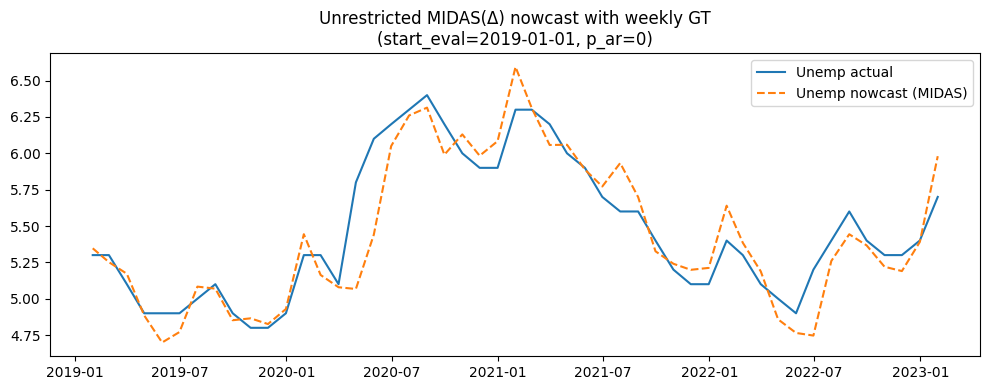

In [68]:
midas_forec, midas_act, rmse_midas, mae_midas, midas_model = \
    midas_unrestricted_nowcast(
        midas_df=midas_df,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=0,          # include ΔUnemp_{t-1} as additional regressor
        min_train=60,
        show_summary=True
    )


In [70]:
def midas_error_diagnostics(forecasts, actuals, print_worst=10, plot=True):
    """
    Diagnostic tool for MIDAS (or any) nowcast errors.
    Computes errors, highlights worst predictions, and plots diagnostics.
    """

    df = pd.DataFrame({
        "Actual": actuals,
        "Forecast": forecasts
    }).dropna()

    df["Error"] = df["Forecast"] - df["Actual"]
    df["AbsError"] = df["Error"].abs()

    # Worst months
    worst = df.sort_values("AbsError", ascending=False).head(print_worst)

    print("\n=== WORST MONTHS (by absolute error) ===")
    print(worst[["Actual", "Forecast", "Error", "AbsError"]])

    # RMSE by year
    df["Year"] = df.index.year
    rmse_by_year = df.groupby("Year")["Error"].apply(lambda e: np.sqrt(np.mean(e**2)))

    print("\n=== RMSE BY YEAR ===")
    print(rmse_by_year)

    if plot:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12,4))
        plt.plot(df["AbsError"], label="Absolute Error")
        plt.title("MIDAS Absolute Forecast Error")
        plt.legend()
        plt.show()

        plt.figure(figsize=(6,6))
        plt.scatter(df["Actual"], df["Forecast"])
        plt.plot([df["Actual"].min(), df["Actual"].max()],
                 [df["Actual"].min(), df["Actual"].max()],
                 'r--')
        plt.title("Actual vs Nowcast (MIDAS)")
        plt.xlabel("Actual Unemployment")
        plt.ylabel("MIDAS Nowcast")
        plt.show()

    return df, worst, rmse_by_year



=== WORST MONTHS (by absolute error) ===
            Actual  Forecast     Error  AbsError
2020-04-30     5.8  5.067035 -0.732965  0.732965
2020-05-31     6.1  5.524918 -0.575082  0.575082
2022-06-30     5.2  4.776645 -0.423355  0.423355
2021-07-31     5.6  5.900665  0.300665  0.300665
2023-01-31     5.7  5.996043  0.296043  0.296043
2021-01-31     6.3  6.527782  0.227782  0.227782
2020-09-30     6.2  5.991080 -0.208920  0.208920
2019-05-31     4.9  4.695624 -0.204376  0.204376
2022-01-31     5.4  5.588606  0.188606  0.188606
2022-04-30     5.0  4.815284 -0.184716  0.184716
2020-12-31     5.9  6.080924  0.180924  0.180924
2020-10-31     6.0  6.176974  0.176974  0.176974

=== RMSE BY YEAR ===
Year
2019    0.083846
2020    0.295521
2021    0.132228
2022    0.158328
2023    0.296043
Name: Error, dtype: float64


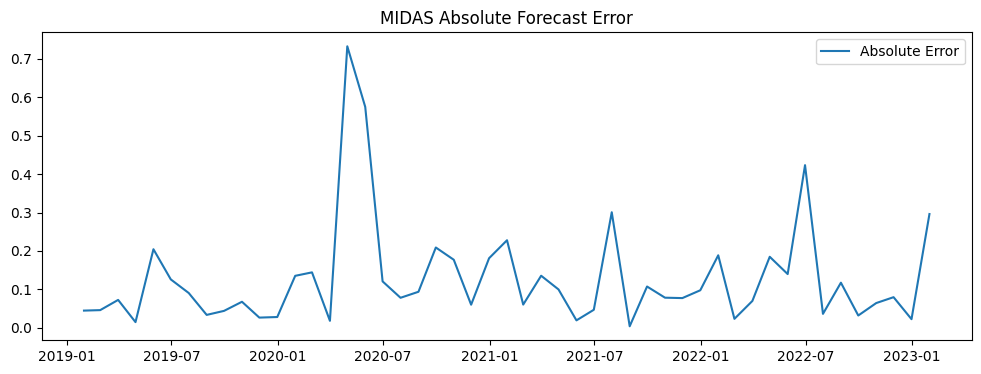

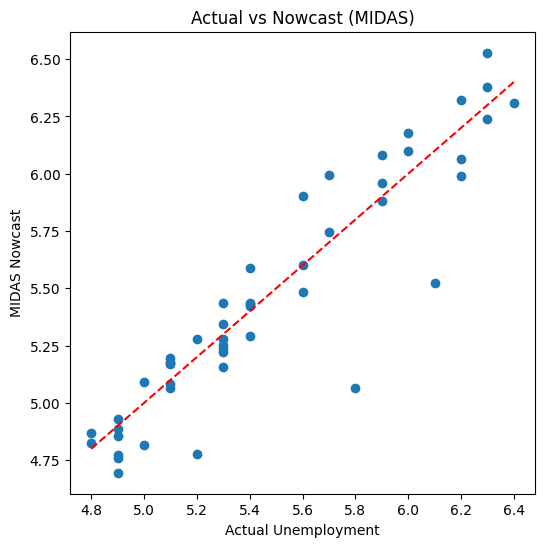

In [ ]:
errors_df, worst_months, rmse_years = midas_error_diagnostics(
    forecasts=midas_forec,
    actuals=midas_act,
    print_worst=12
)


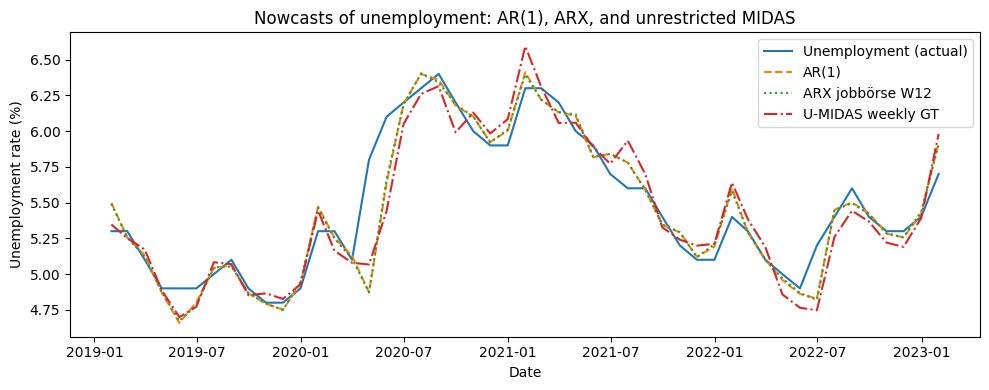

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

df_levels_midas = pd.concat(
    [
        ar_act.rename("Unemp_actual"),
        ar_forec.rename("Unemp_AR1"),
        bestW12_forec.rename("Unemp_ARX_jobbörse_W12"),
        midas_forec.rename("Unemp_MIDAS"),
    ],
    axis=1
).dropna()

plt.figure(figsize=(10, 4))
plt.plot(df_levels_midas.index, df_levels_midas["Unemp_actual"], label="Unemployment (actual)")
plt.plot(df_levels_midas.index, df_levels_midas["Unemp_AR1"], label="AR(1)", linestyle="--")
plt.plot(df_levels_midas.index, df_levels_midas["Unemp_ARX_jobbörse_W12"],
         label="ARX jobbörse W12", linestyle=":")
plt.plot(df_levels_midas.index, df_levels_midas["Unemp_MIDAS"],
         label="U-MIDAS weekly GT", linestyle="-.")

plt.title("Nowcasts of unemployment: AR(1), ARX, and unrestricted MIDAS")
plt.xlabel("Date")
plt.ylabel("Unemployment rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


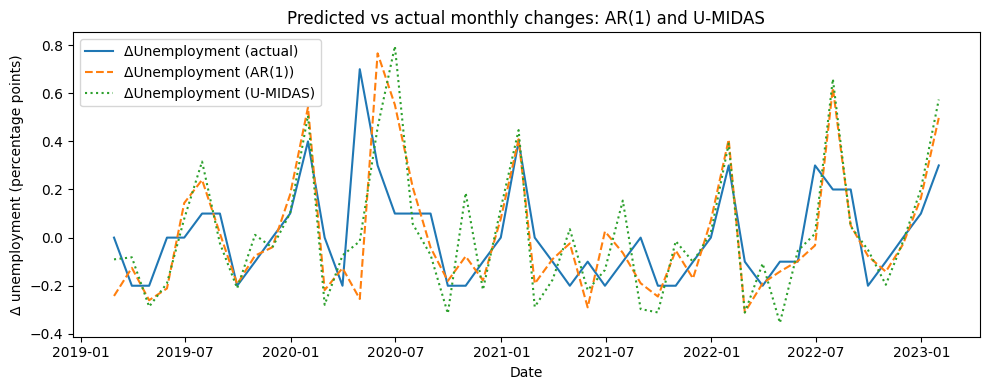

In [57]:
dU_act   = ar_act.diff().rename("dUnemp_actual")
dU_ar    = ar_forec.diff().rename("dUnemp_AR1")
dU_midas = midas_forec.diff().rename("dUnemp_MIDAS")

df_du_midas = pd.concat([dU_act, dU_ar, dU_midas], axis=1).dropna()

plt.figure(figsize=(10, 4))
plt.plot(df_du_midas.index, df_du_midas["dUnemp_actual"], label="ΔUnemployment (actual)")
plt.plot(df_du_midas.index, df_du_midas["dUnemp_AR1"], label="ΔUnemployment (AR(1))", linestyle="--")
plt.plot(df_du_midas.index, df_du_midas["dUnemp_MIDAS"],
         label="ΔUnemployment (U-MIDAS)", linestyle=":")
plt.title("Predicted vs actual monthly changes: AR(1) and U-MIDAS")
plt.xlabel("Date")
plt.ylabel("Δ unemployment (percentage points)")
plt.legend()
plt.tight_layout()
plt.show()


## All keywords

In [65]:
import pandas as pd
import numpy as np

def build_midas_df(weekly_panel, unemp, gt_col, K=8):
    """
    Build unrestricted MIDAS design matrix for one weekly GT series.

    weekly_panel : DataFrame with weekly GT series (columns = keywords)
    unemp        : DataFrame or Series with column 'Unemp' at monthly freq
    gt_col       : name of the GT column to use (e.g. 'indeed')
    K            : number of weekly lags to include (lag1 = most recent week)

    Returns
    -------
    midas_df : monthly DataFrame with
               - 'dUnemp' (monthly ∆ unemployment)
               - 'lag1'...'lagK' (weekly ∆GT lags, most recent = lag1)
               - monthly dummies 'month_2'...'month_12'
    """

    # --- copy & align indices ---
    weekly = weekly_panel[[gt_col]].copy()
    monthly = unemp[["Unemp"]].copy() if isinstance(unemp, pd.DataFrame) else unemp.to_frame("Unemp")

    weekly.index = pd.to_datetime(weekly.index)
    monthly.index = pd.to_datetime(monthly.index)

    weekly = weekly.sort_index()
    monthly = monthly.sort_index()

    # --- first differences ---
    monthly["dUnemp"] = monthly["Unemp"].diff()
    weekly["dGT"] = weekly[gt_col].diff()

    monthly = monthly.dropna(subset=["dUnemp"])
    weekly = weekly.dropna(subset=["dGT"])

    # --- build MIDAS rows: one per month, K weekly lags ---
    rows = []
    for month_date, row in monthly.iterrows():
        y = row["dUnemp"]

        weekly_up_to = weekly.loc[weekly.index <= month_date]
        if len(weekly_up_to) < K:
            continue

        last_K = weekly_up_to["dGT"].iloc[-K:]          # oldest → newest
        lags = last_K.iloc[::-1].values                 # reverse: lag1 = most recent

        rows.append([month_date, y] + list(lags))

    colnames = ["Date", "dUnemp"] + [f"lag{i+1}" for i in range(K)]
    midas_df = pd.DataFrame(rows, columns=colnames).set_index("Date")

    # --- monthly dummies (Feb–Dec; Jan baseline) ---
    midas_df["month"] = midas_df.index.month
    midas_df = pd.get_dummies(midas_df, columns=["month"], drop_first=True)

    return midas_df


In [66]:
import numpy as np

keywords_weekly = ["indeed", "stepstone", "jobbörse", "arbeitsamt", "bewerbung"]

midas_results = []
midas_outputs = {}   # to keep forecasts/actuals/models for later plots

for gt in keywords_weekly:
    print(f"\n=== Running U-MIDAS for {gt} ===")

    midas_df_gt = build_midas_df(weekly_panel, unemp, gt_col=gt, K=8)

    forec, act, rmse, mae, model = midas_unrestricted_nowcast(
        midas_df=midas_df_gt,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=1,          # same as before
        min_train=60,
        show_summary=False,   # keep output clean in the loop
        plot=False            # plots only later for best model
    )

    midas_results.append({
        "gt_col": gt,
        "rmse": rmse,
        "mae": mae
    })

    midas_outputs[gt] = {
        "forecasts": forec,
        "actuals": act,
        "model": model,
        "midas_df": midas_df_gt
    }

midas_results = pd.DataFrame(midas_results).sort_values("rmse")
print("\n=== U-MIDAS results across weekly keywords ===")
print(midas_results)

best_row = midas_results.iloc[0]
best_midas_keyword = best_row["gt_col"]
print("\nBest U-MIDAS keyword:", best_midas_keyword)



=== Running U-MIDAS for indeed ===

Unrestricted MIDAS(Δ) nowcast: RMSE=0.1879, MAE=0.1276

=== Running U-MIDAS for stepstone ===

Unrestricted MIDAS(Δ) nowcast: RMSE=0.1743, MAE=0.1019

=== Running U-MIDAS for jobbörse ===

Unrestricted MIDAS(Δ) nowcast: RMSE=0.1722, MAE=0.0960

=== Running U-MIDAS for arbeitsamt ===

Unrestricted MIDAS(Δ) nowcast: RMSE=0.1904, MAE=0.1068

=== Running U-MIDAS for bewerbung ===

Unrestricted MIDAS(Δ) nowcast: RMSE=0.1854, MAE=0.1123

=== U-MIDAS results across weekly keywords ===
       gt_col      rmse       mae
2    jobbörse  0.172196  0.095952
1   stepstone  0.174346  0.101937
4   bewerbung  0.185430  0.112296
0      indeed  0.187933  0.127560
3  arbeitsamt  0.190440  0.106824

Best U-MIDAS keyword: jobbörse



Unrestricted MIDAS(Δ) nowcast: RMSE=0.1722, MAE=0.0960

=== Last MIDAS(Δ) OLS summary ===
                            OLS Regression Results                            
Dep. Variable:                 dUnemp   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     22.93
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.05e-31
Time:                        13:18:25   Log-Likelihood:                 122.71
No. Observations:                 138   AIC:                            -203.4
Df Residuals:                     117   BIC:                            -142.0
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

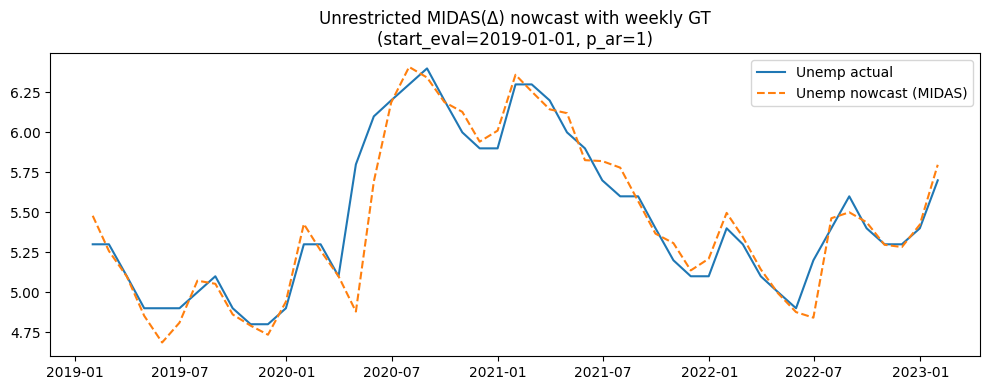


=== WORST MONTHS (by absolute error) ===
            Actual  Forecast     Error  AbsError
2020-04-30     5.8  4.879274 -0.920726  0.920726
2020-05-31     6.1  5.692388 -0.407612  0.407612
2022-06-30     5.2  4.841161 -0.358839  0.358839
2019-05-31     4.9  4.685763 -0.214237  0.214237
2021-07-31     5.6  5.779391  0.179391  0.179391
2019-01-31     5.3  5.478375  0.178375  0.178375
2020-10-31     6.0  6.128216  0.128216  0.128216
2020-01-31     5.3  5.427016  0.127016  0.127016
2021-06-30     5.7  5.820313  0.120313  0.120313
2021-04-30     6.0  6.120092  0.120092  0.120092

=== RMSE BY YEAR ===
Year
2019    0.093473
2020    0.299662
2021    0.092282
2022    0.115056
2023    0.097258
Name: Error, dtype: float64


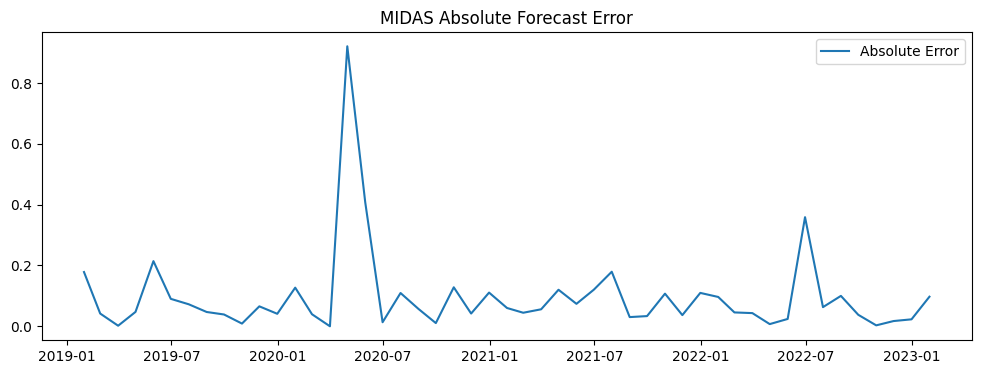

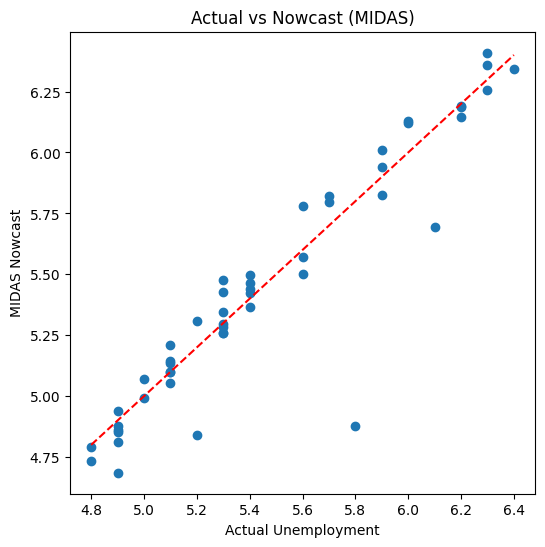

In [71]:
best_midas_df = build_midas_df(weekly_panel, unemp, gt_col=best_midas_keyword, K=8)

best_mid_forec, best_mid_act, best_mid_rmse, best_mid_mae, best_mid_model = \
    midas_unrestricted_nowcast(
        midas_df=best_midas_df,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=1,
        min_train=60,
        show_summary=True,
        plot=True        # level path plot
    )

# extra diagnostics (worst months, RMSE by year, scatter)
midas_diag_df, midas_worst, midas_rmse_year = midas_error_diagnostics(
    best_mid_forec, best_mid_act, print_worst=10, plot=True
)


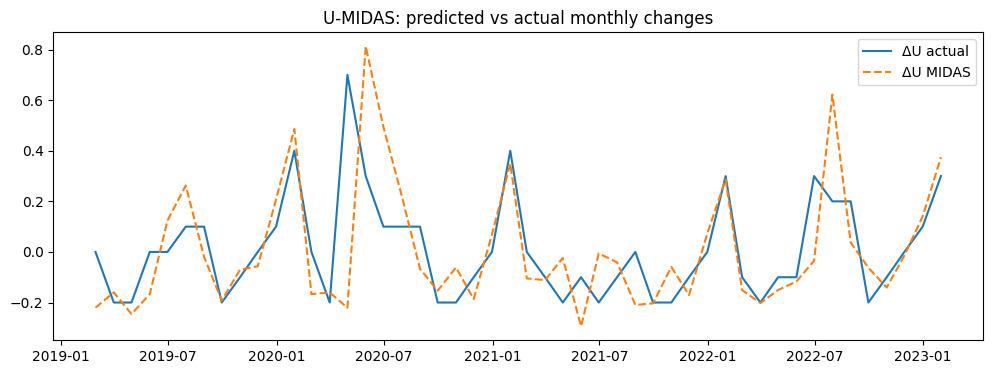

In [72]:
plt.figure(figsize=(12,4))
plt.plot(best_mid_act.diff(), label="ΔU actual")
plt.plot(best_mid_forec.diff(), label="ΔU MIDAS", linestyle="--")
plt.title("U-MIDAS: predicted vs actual monthly changes")
plt.legend()
plt.show()


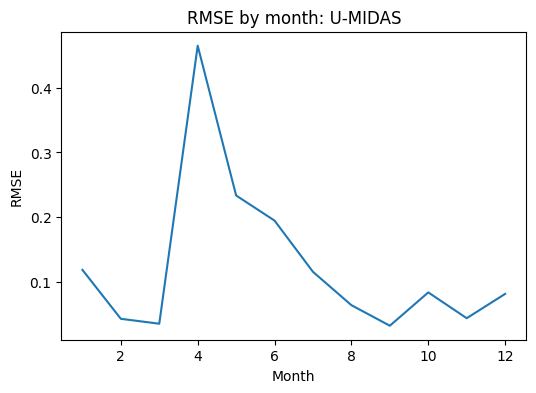

In [73]:
mid_err = (best_mid_forec - best_mid_act).abs()
rmse_month = mid_err.groupby(mid_err.index.month).apply(lambda x: np.sqrt(np.mean(x**2)))

rmse_month.plot(kind='line', figsize=(6,4))
plt.title("RMSE by month: U-MIDAS")
plt.xlabel("Month")
plt.ylabel("RMSE")
plt.show()


## Diebold Marino test

In [ ]:
import numpy as np
from scipy.stats import t

def dm_test(e1, e2, h=1, crit="MSE"):
    """
    Diebold–Mariano test for equal predictive accuracy.

    Parameters
    ----------
    e1, e2 : array-like
        Forecast errors from model 1 and model 2 (aligned in time).
    h : int
        Forecast horizon. For your nowcasts: h = 1.
    crit : {"MSE", "MAE"}
        Loss function: squared error or absolute error.

    Returns
    -------
    DM_stat_corr : float
        Small-sample corrected DM statistic.
    p_value : float
        Two-sided p-value.
    """

    e1 = np.asarray(e1)
    e2 = np.asarray(e2)
    assert e1.shape == e2.shape, "Error series must be same length"

    if crit.upper() == "MSE":
        d = e1**2 - e2**2
    elif crit.upper() == "MAE":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("crit must be 'MSE' or 'MAE'")

    T = len(d)
    mean_d = np.mean(d)

    # Newey–West variance estimate with lag h-1
    gamma = [np.sum((d[i:] - mean_d) * (d[:T-i] - mean_d)) / T for i in range(h)]
    var_d = gamma[0] + 2 * sum((1 - k/h) * gamma[k] for k in range(1, h))

    DM_stat = mean_d / np.sqrt(var_d / T)

    # Harvey–Leybourne–Newbold small-sample correction
    df = T - 1
    DM_stat_corr = DM_stat * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    p_value = 2 * (1 - t.cdf(np.abs(DM_stat_corr), df))

    return DM_stat_corr, p_value


In [ ]:
# errors for overlapping period
errors_arx   = var_job_W12_forec - var_job_W12_act
errors_midas = midas_forec - midas_act

# align by common index
common_idx = errors_arx.index.intersection(errors_midas.index)
e1 = errors_arx.loc[common_idx].values
e2 = errors_midas.loc[common_idx].values

dm_stat, pval = dm_test(e1, e2, h=1, crit="MSE")
print("DM stat:", dm_stat, "p-value:", pval)


DM stat: -0.1844629207362978 p-value: 0.8544274578931161


In [ ]:
# errors
errors_ar     = (ar_forec - ar_act).loc[midas_forec.index]
errors_arx    = (bestW12_forec - bestW12_act).loc[midas_forec.index]
errors_midas  = (midas_forec - midas_act)

# align indices
common_idx = errors_midas.index.intersection(errors_ar.index)
e_ar    = errors_ar.loc[common_idx].values
e_midas = errors_midas.loc[common_idx].values

dm_stat_ar_midas, pval_ar_midas = dm_test(e_midas, e_ar, h=1, crit="MSE")
print("DM (MIDAS vs AR(1)):", dm_stat_ar_midas, "p-value:", pval_ar_midas)

common_idx2 = errors_midas.index.intersection(errors_arx.index)
e_arx   = errors_arx.loc[common_idx2].values
e_midas2 = errors_midas.loc[common_idx2].values

dm_stat_arx_midas, pval_arx_midas = dm_test(e_midas2, e_arx, h=1, crit="MSE")
print("DM (MIDAS vs ARX):", dm_stat_arx_midas, "p-value:", pval_arx_midas)


# MIDAS

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def exp_almon_weights(theta, K):
    """
    Exponential Almon lag weights for k=1,...,K.
    theta: array-like [theta1, theta2]
    """
    theta1, theta2 = theta
    k = np.linspace(0, 1, K)
    a = np.exp(theta1 * k + theta2 * k**2)
    return a / a.sum()


def restricted_midas_nowcast(
    midas_df,
    unemp,
    start_eval="2019-01-01",
    p_ar=1,        # AR lags of dUnemp
    min_train=60,  # minimal obs in estimation window
    plot=True,
    show_theta=True
):
    """
    Rolling-window restricted MIDAS nowcast with Exponential Almon weights.

    Model:
      dUnemp_t = alpha + sum_i phi_i dUnemp_{t-i}
                 + beta * sum_k w_k(theta) * lag_k_t
                 + seasonal dummies + error_t

    where lag_k_t are weekly dGT lags and w_k(theta) are Almon weights.

    Parameters
    ----------
    midas_df : DataFrame
        Must contain:
          - 'dUnemp'
          - 'lag1'...'lagK'
          - monthly dummies 'month_2',..., 'month_12'
    unemp : DataFrame or Series
        Original unemployment levels ('Unemp') with DateTimeIndex.
    start_eval : str or Timestamp
        First month to start evaluating nowcasts.
    p_ar : int
        Number of AR lags of dUnemp.
    min_train : int
        Minimum number of usable observations for estimation.
    """

    df = midas_df.copy()
    if isinstance(unemp, pd.DataFrame):
        U_series = pd.to_numeric(unemp["Unemp"], errors="coerce")
    else:
        U_series = pd.to_numeric(unemp, errors="coerce")

    df["dUnemp"] = pd.to_numeric(df["dUnemp"], errors="coerce")

    # Identify columns
    lag_cols = [c for c in df.columns if c.startswith("lag")]
    K = len(lag_cols)
    dummy_cols = [c for c in df.columns if c.startswith("month_")]

    # Add AR lags of dUnemp if needed
    if p_ar > 0:
        for i in range(1, p_ar+1):
            df[f"dUnemp_lag{i}"] = df["dUnemp"].shift(i)
    ar_cols = [c for c in df.columns if c.startswith("dUnemp_lag")]

    forecasts = []
    actuals = []
    dates = []
    last_theta = None
    last_beta = None

    eval_dates = df.loc[start_eval:].index

    for t in eval_dates:
        # Estimation sample: all months before t
        df_est = df.loc[df.index < t].copy()

        # drop rows with missing dUnemp or lags
        df_est = df_est.dropna(subset=["dUnemp"] + lag_cols + ar_cols + dummy_cols)

        if len(df_est) < min_train:
            continue

        y = df_est["dUnemp"].values
        Z = df_est[lag_cols].values  # weekly lags matrix (T x K)
        D = df_est[dummy_cols].values if dummy_cols else np.empty((len(df_est), 0))

        if p_ar > 0:
            A = df_est[ar_cols].values  # AR lags of dUnemp
        else:
            A = np.empty((len(df_est), 0))

        T = len(df_est)

        # objective function for NLS over theta
        def obj(theta):
            w = exp_almon_weights(theta, K)
            x_midas = Z @ w  # T-vector

            X_parts = [np.ones(T)]  # constant
            if p_ar > 0:
                X_parts.append(A)
            X_parts.append(x_midas.reshape(-1, 1))
            if D.shape[1] > 0:
                X_parts.append(D)

            X = np.column_stack(X_parts)

            # OLS for linear parameters given theta
            beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta_hat
            return np.sum(resid**2)

        # initial guess for theta
        theta0 = np.array([-0.1, 0.01])
        res_optim = minimize(obj, theta0, method="L-BFGS-B",
                             bounds=[(-1.5, 1.5), (-0.1, 0.1)])

        theta_hat = res_optim.x
        w_hat = exp_almon_weights(theta_hat, K)

        # once theta_hat is known, re-estimate linear params
        x_midas_est = Z @ w_hat
        X_parts = [np.ones(T)]
        if p_ar > 0:
            X_parts.append(A)
        X_parts.append(x_midas_est.reshape(-1, 1))
        if D.shape[1] > 0:
            X_parts.append(D)
        X_est = np.column_stack(X_parts)
        beta_hat, _, _, _ = np.linalg.lstsq(X_est, y, rcond=None)

        last_theta = theta_hat
        last_beta = beta_hat

        # Build regressor row for forecast date t
        row_t = df.loc[[t]]
        z_t = row_t[lag_cols].values.reshape(1, -1)
        x_midas_t = (z_t @ w_hat).flatten()[0]

        X_parts_t = [np.array([1.0])]
        if p_ar > 0:
            A_t = row_t[ar_cols].values.flatten()
            X_parts_t.append(A_t)
        X_parts_t.append(np.array([x_midas_t]))
        if dummy_cols:
            D_t = row_t[dummy_cols].values.flatten()
            X_parts_t.append(D_t)

        X_t = np.concatenate(X_parts_t).reshape(1, -1)

        # predict dUnemp_t
        dU_pred = float(X_t @ beta_hat)

        # level nowcast: U_t = U_{t-1} + dU_pred
        U_last = U_series.loc[U_series.index < t].iloc[-1]
        U_pred = U_last + dU_pred

        forecasts.append(U_pred)
        actuals.append(U_series.loc[t])
        dates.append(t)

    forecasts = pd.Series(forecasts, index=dates, name="Unemp_nowcast_MIDAS_res")
    actuals = pd.Series(actuals, index=dates, name="Unemp_actual")

    errors = forecasts - actuals
    rmse = np.sqrt(np.mean(errors**2))
    mae = np.mean(np.abs(errors))

    print(f"\nRestricted MIDAS (Exp-Almon) nowcast: RMSE={rmse:.4f}, MAE={mae:.4f}")
    if show_theta and last_theta is not None:
        print("Last theta_hat (theta1, theta2):", last_theta)
        print("Last beta_hat (linear params, order: const, AR-lags, MIDAS, dummies...):")
        print(last_beta)

    if plot:
        plt.figure(figsize=(10,4))
        plt.plot(actuals, label="Unemp actual")
        plt.plot(forecasts, label="Unemp nowcast (res. MIDAS)", linestyle="--")
        plt.title(
            f"Restricted MIDAS (Exp-Almon) nowcast\n"
            f"(start_eval={start_eval}, p_ar={p_ar})"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()

    return forecasts, actuals, rmse, mae, last_theta, last_beta



Restricted MIDAS (Exp-Almon) nowcast: RMSE=0.1936, MAE=0.1129
Last theta_hat (theta1, theta2): [1.5 0.1]
Last beta_hat (linear params, order: const, AR-lags, MIDAS, dummies...):
[ 0.47142812  0.41221779 -0.01320267 -0.65649312 -0.66179716 -0.55517761
 -0.5582627  -0.46012911 -0.32881019 -0.43452916 -0.70951552 -0.49208587
 -0.45135495 -0.38111744]


/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float(X_t @ beta_hat)
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float(X_t @ beta_hat)
/var/folders/gw/jst10qpx499c9tkkw977rqj00000gn/T/ipykernel_75809/1298762975.py:160: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dU_pred = float

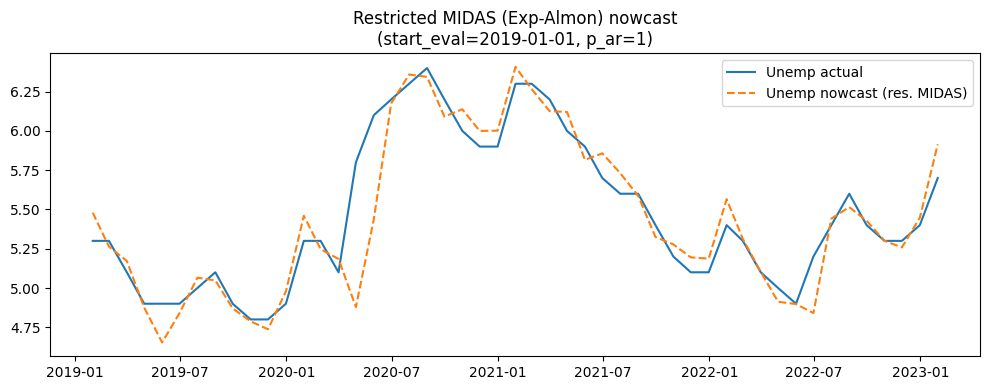

In [ ]:
res_forec, res_act, rmse_res, mae_res, theta_hat, beta_hat = \
    restricted_midas_nowcast(
        midas_df=midas_df,
        unemp=unemp,
        start_eval="2019-01-01",
        p_ar=1,
        min_train=60,
        plot=True
    )


"After stabilizing the Exponential Almon lag function by rescaling and bounding parameters, the restricted MIDAS converges. However, the weekly GT signal remains weak and the lag-shape parameters are only weakly identified. Therefore, restricted MIDAS does not meaningfully outperform ARX or unrestricted MIDAS."